# 🛒 온라인 채널 제품 판매량 예측
https://dacon.io/competitions/official/236129/data

> **제출용 최종 노트북 (Method 4 + LSTM + LightGBM 앙상블)**  
> **입력:** 과거 28일 시퀀스 → **출력:** 미래 21일 판매량  
> **DACON 최종 점수:** Public 0.4114 / **Private 0.4336 (1위)**

───────────────────────────────────────────────

> **예측 대상:** 약 15,890개 제품의 미래 21일 일별 판매 수량  
> **학습 데이터:** 2022-01-01 ~ 2023-04-04 (459일)  
> **예측 기간:** 2023-04-05 ~ 2023-04-25 (21일)

| STEP | 내용 |
|------|------|
| STEP 1 | 환경 설정 및 데이터 로드 |
| STEP 2 | EDA + 시각화 |
| STEP 3 | 전처리 (급락 구간 Method 4 적용) |
| STEP 4 | 특성공학 + Train/Val 분리 + 정규화 |
| STEP 5 | 모델링 및 성능 비교 (LSTM / LightGBM, GRU 후보 실험 후 제외) |
| STEP 6 | Method 4 기반 딥러닝 전체 재학습 |
| STEP 7 | 앙상블 + 후처리 + 제출 파일 생성 |

---
## STEP 1 — 환경 설정 및 데이터 로드

In [1]:
import os
import sys
import gc
import warnings
import subprocess
import platform
from pathlib import Path

# ── 파이토치 메모리 최적화 ───────────────────────────────────────────
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128,garbage_collection_threshold:0.6'

# ── 라이브러리 자동 설치 및 임포트 ───────────────────────────────────
print("⏳ 필수 라이브러리 확인 중...")
REQUIRED_PKGS = ["holidays", "statsmodels"]
for pkg in REQUIRED_PKGS:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

print('✅ 라이브러리 준비 완료')

# ── 한글 폰트 및 시각화 설정 ────────────────────────────────────────
from korean_font import set_korean_font
set_korean_font()

warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'jpeg'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 시드 고정 — 누가 돌려도 같은 결과 ────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f'🎲 시드 고정: {SEED}')

# ── 경로 설정 ────────────────────────────────────────────────────────
HOME       = os.getcwd()
DATA_DIR   = os.path.join(HOME, 'data')
OUTPUT_DIR    = os.path.join(HOME, 'output')                # ← STEP 5: Method 5 실험 결과
OUTPUT_DIR_M4 = os.path.join(HOME, 'output', 'v6_method4')  # ← STEP 6~7: Method 4 결과
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR_M4, exist_ok=True)

print(f'📁 HOME: {HOME}')
print(f'📁 DATA: {DATA_DIR}')
print(f'📁 OUT : {OUTPUT_DIR}')
print(f'📁 OUT : {OUTPUT_DIR_M4}')

# ── GPU 설정 (초기화는 데이터 로드 후로 지연) ────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🎯 DEVICE = {DEVICE}  (GPU 초기화는 데이터 로드 후에 함)')

⏳ 필수 라이브러리 확인 중...
✅ 라이브러리 준비 완료
한글 폰트 설정: Malgun Gothic (c:/Windows/Fonts/malgun.ttf)
🎲 시드 고정: 42
📁 HOME: c:\Users\min2m\github\Sales\Team
📁 DATA: c:\Users\min2m\github\Sales\Team\data
📁 OUT : c:\Users\min2m\github\Sales\Team\output
📁 OUT : c:\Users\min2m\github\Sales\Team\output\v6_method4
🎯 DEVICE = cpu  (GPU 초기화는 데이터 로드 후에 함)


In [2]:
# ── 데이터 로드 및 칼럼(변수) 분리 ───────────────────────────────────
# 데이터를 불러오고, '정보(Meta)'와 '시계열 수치(Date)'를 미리 분리해 둡니다.
train      = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
sales      = pd.read_csv(os.path.join(DATA_DIR, 'sales.csv'))
product    = pd.read_csv(os.path.join(DATA_DIR, 'product_info.csv'))
keyword    = pd.read_csv(os.path.join(DATA_DIR, 'brand_keyword_cnt.csv'))
submission = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))

# 나중에 데이터 다루기 편하도록 이름표(리스트) 미리 묶어두기
META_COLS  = ['ID', '제품', '대분류', '중분류', '소분류', '브랜드']
DATE_COLS  = [c for c in train.columns if c not in META_COLS]
KW_COLS    = [c for c in keyword.columns if c != '브랜드']
PRED_DATES = [c for c in submission.columns if c != 'ID']

print('=' * 55)
print(f'📊 train.csv   : {train.shape[0]:,}행 × {train.shape[1]}열')
print(f'📊 sales.csv   : {sales.shape[0]:,}행 × {sales.shape[1]}열')
print(f'📊 product.csv : {product.shape[0]:,}행 × {product.shape[1]}열')
print(f'📊 keyword.csv : {keyword.shape[0]:,}행 × {keyword.shape[1]}열')
print('=' * 55)
print(f'📅 학습 기간   : {DATE_COLS[0]}  ~  {DATE_COLS[-1]}  ({len(DATE_COLS)}일)')
print(f'🎯 예측 기간   : {PRED_DATES[0]}  ~  {PRED_DATES[-1]}  ({len(PRED_DATES)}일)')
print('=' * 55)

# ── 데이터 메모리 다이어트 (Downcasting) ─────────────────────────────
# 64비트(큰 방)에 들어있는 데이터를 32비트(작은 방)로 옮겨서 RAM 용량을 확보합니다.
before_mb = sum(d.memory_usage(deep=True).sum() for d in [train, sales, keyword]) / 1024**2

for data in [train, sales, keyword, submission]:
    for col in data.columns:
        # 정수형 다이어트
        if data[col].dtype == 'int64':
            data[col] = data[col].astype('int32')
        # 실수형 다이어트
        elif data[col].dtype == 'float64':
            data[col] = data[col].astype('float32')

after_mb = sum(d.memory_usage(deep=True).sum() for d in [train, sales, keyword]) / 1024**2
print(f'💾 메모리 최적화: {before_mb:.1f}MB → {after_mb:.1f}MB ({(1-after_mb/before_mb)*100:.0f}% 절감)')

# ── 메모리 다이어트 과정에서 생긴 가비지 청소 ─────────────────────────────
gc.collect()

# ── 데이터 메타 정보와 첫 3일치 데이터만 살짝 확인 ────────────────────────
train[META_COLS + DATE_COLS[:3]].head(3)

📊 train.csv   : 15,890행 × 465열
📊 sales.csv   : 15,890행 × 465열
📊 product.csv : 12,778행 × 2열
📊 keyword.csv : 3,170행 × 460열
📅 학습 기간   : 2022-01-01  ~  2023-04-04  (459일)
🎯 예측 기간   : 2023-04-05  ~  2023-04-25  (21일)
💾 메모리 최적화: 133.5MB → 72.2MB (46% 절감)


,ID,제품,대분류,중분류,소분류,브랜드,2022-01-01,2022-01-02,2022-01-03
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,0,0,0
1,1,B002-00002-00001,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0
2,2,B002-00002-00002,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0


In [3]:
# ── 8. GPU 최종 점검 및 초기화 ──────────────────────────────────────────
# 데이터를 다 불러오고 메모리 다이어트까지 끝낸 지금! 드디어 GPU 상태를 확인합니다.
# 본격적인 모델링에 들어가기 전에, GPU 캐시(임시 저장소)를 싹 비워 쾌적하게 만듭니다.
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()
    props    = torch.cuda.get_device_properties(0)
    total_gb = props.total_memory / 1024**3
    print(f'✅ {props.name}  |  총 {total_gb:.1f}GB')
else:
    print('⚠️ CPU 모드')

⚠️ CPU 모드


---
## STEP 2 — 탐색적 데이터 분석 (EDA) + 시각화

> 🔧 함수 선언 : `short_label()`  
> 마지막 숫자만 추출해 `대2`, `중11`, `소38`처럼 짧게 만드는 함수

In [4]:
# ── short_label() : 카테고리 코드를 짧은 레이블로 변환 ────────────────────
# 예) 'B002-C001-0002' → '대2' / 'B002-C003-0038' → '소38'
def short_label(code_str, prefix):
    """카테고리 코드 마지막 숫자만 추출해 짧은 레이블 반환"""
    number = code_str.split('-')[-1].lstrip('0') or '0'
    return f'{prefix}{number}'

# ── 전역 레이블 딕셔너리 — 이후 모든 그래프에서 공용 사용  ────────────────────
cat_labels = {}
for col, prefix in [('대분류', '대'), ('중분류', '중'), ('소분류', '소')]:
    cat_labels[col] = {
        code_str: short_label(code_str, prefix)
        for code_str in train[col].unique()
    }

# ── 변환 결과 확인 ────────────────────
for col in ['대분류', '중분류', '소분류']:
    items  = list(cat_labels[col].items())[:3]
    sample = '  /  '.join(f'{k} → {v}' for k, v in items)
    print(f'[{col}] 예시: {sample}  ... (총 {len(cat_labels[col])}개)')

[대분류] 예시: B002-C001-0002 → 대2  /  B002-C001-0003 → 대3  /  B002-C001-0001 → 대1  ... (총 5개)
[중분류] 예시: B002-C002-0007 → 중7  /  B002-C002-0008 → 중8  /  B002-C002-0001 → 중1  ... (총 11개)
[소분류] 예시: B002-C003-0038 → 소38  /  B002-C003-0044 → 소44  /  B002-C003-0003 → 소3  ... (총 53개)


### 2-1. 기본 통계 + 카테고리 구조 시각화

In [5]:
# ── 기본 통계 수치 출력 ────────────────────────────────────────────────────
print('=' * 55)
print('📌 제품 카테고리 구조')
print('=' * 55)
print(f"  전체 제품(행) 수  : {train['제품'].nunique():>6,}개")
print(f"  브랜드 수         : {train['브랜드'].nunique():>6,}개")
print(f"  대분류 수         : {train['대분류'].nunique():>6}개")
print(f"  중분류 수         : {train['중분류'].nunique():>6}개")
print(f"  소분류 수         : {train['소분류'].nunique():>6}개")

qty_all = train[DATE_COLS].values.flatten()

print()
print('=' * 55)
print('📊 판매량(qty) 전체 통계')
print('=' * 55)
print(f'  전체 데이터 셀 수        : {len(qty_all):>12,}개')
print(f'  판매량 = 0인 셀 (비율)   : {(qty_all==0).sum():>12,}개 ({(qty_all==0).mean():.1%})')
print(f'  판매량 > 0인 셀 (비율)   : {(qty_all>0).sum():>12,}개 ({(qty_all>0).mean():.1%})')
print(f'  전체 중앙값              : {np.median(qty_all):>12.1f}')
print(f'  판매>0인 날 평균         : {qty_all[qty_all>0].mean():>12.1f}')
print(f'  판매>0인 날 중앙값       : {np.median(qty_all[qty_all>0]):>12.1f}')
print(f'  최대값                   : {qty_all.max():>12,}')

📌 제품 카테고리 구조
  전체 제품(행) 수  : 15,840개
  브랜드 수         :  3,170개
  대분류 수         :      5개
  중분류 수         :     11개
  소분류 수         :     53개

📊 판매량(qty) 전체 통계
  전체 데이터 셀 수        :    7,293,510개
  판매량 = 0인 셀 (비율)   :    4,652,860개 (63.8%)
  판매량 > 0인 셀 (비율)   :    2,640,650개 (36.2%)
  전체 중앙값              :          0.0
  판매>0인 날 평균         :         48.8
  판매>0인 날 중앙값       :          7.0
  최대값                   :      200,420


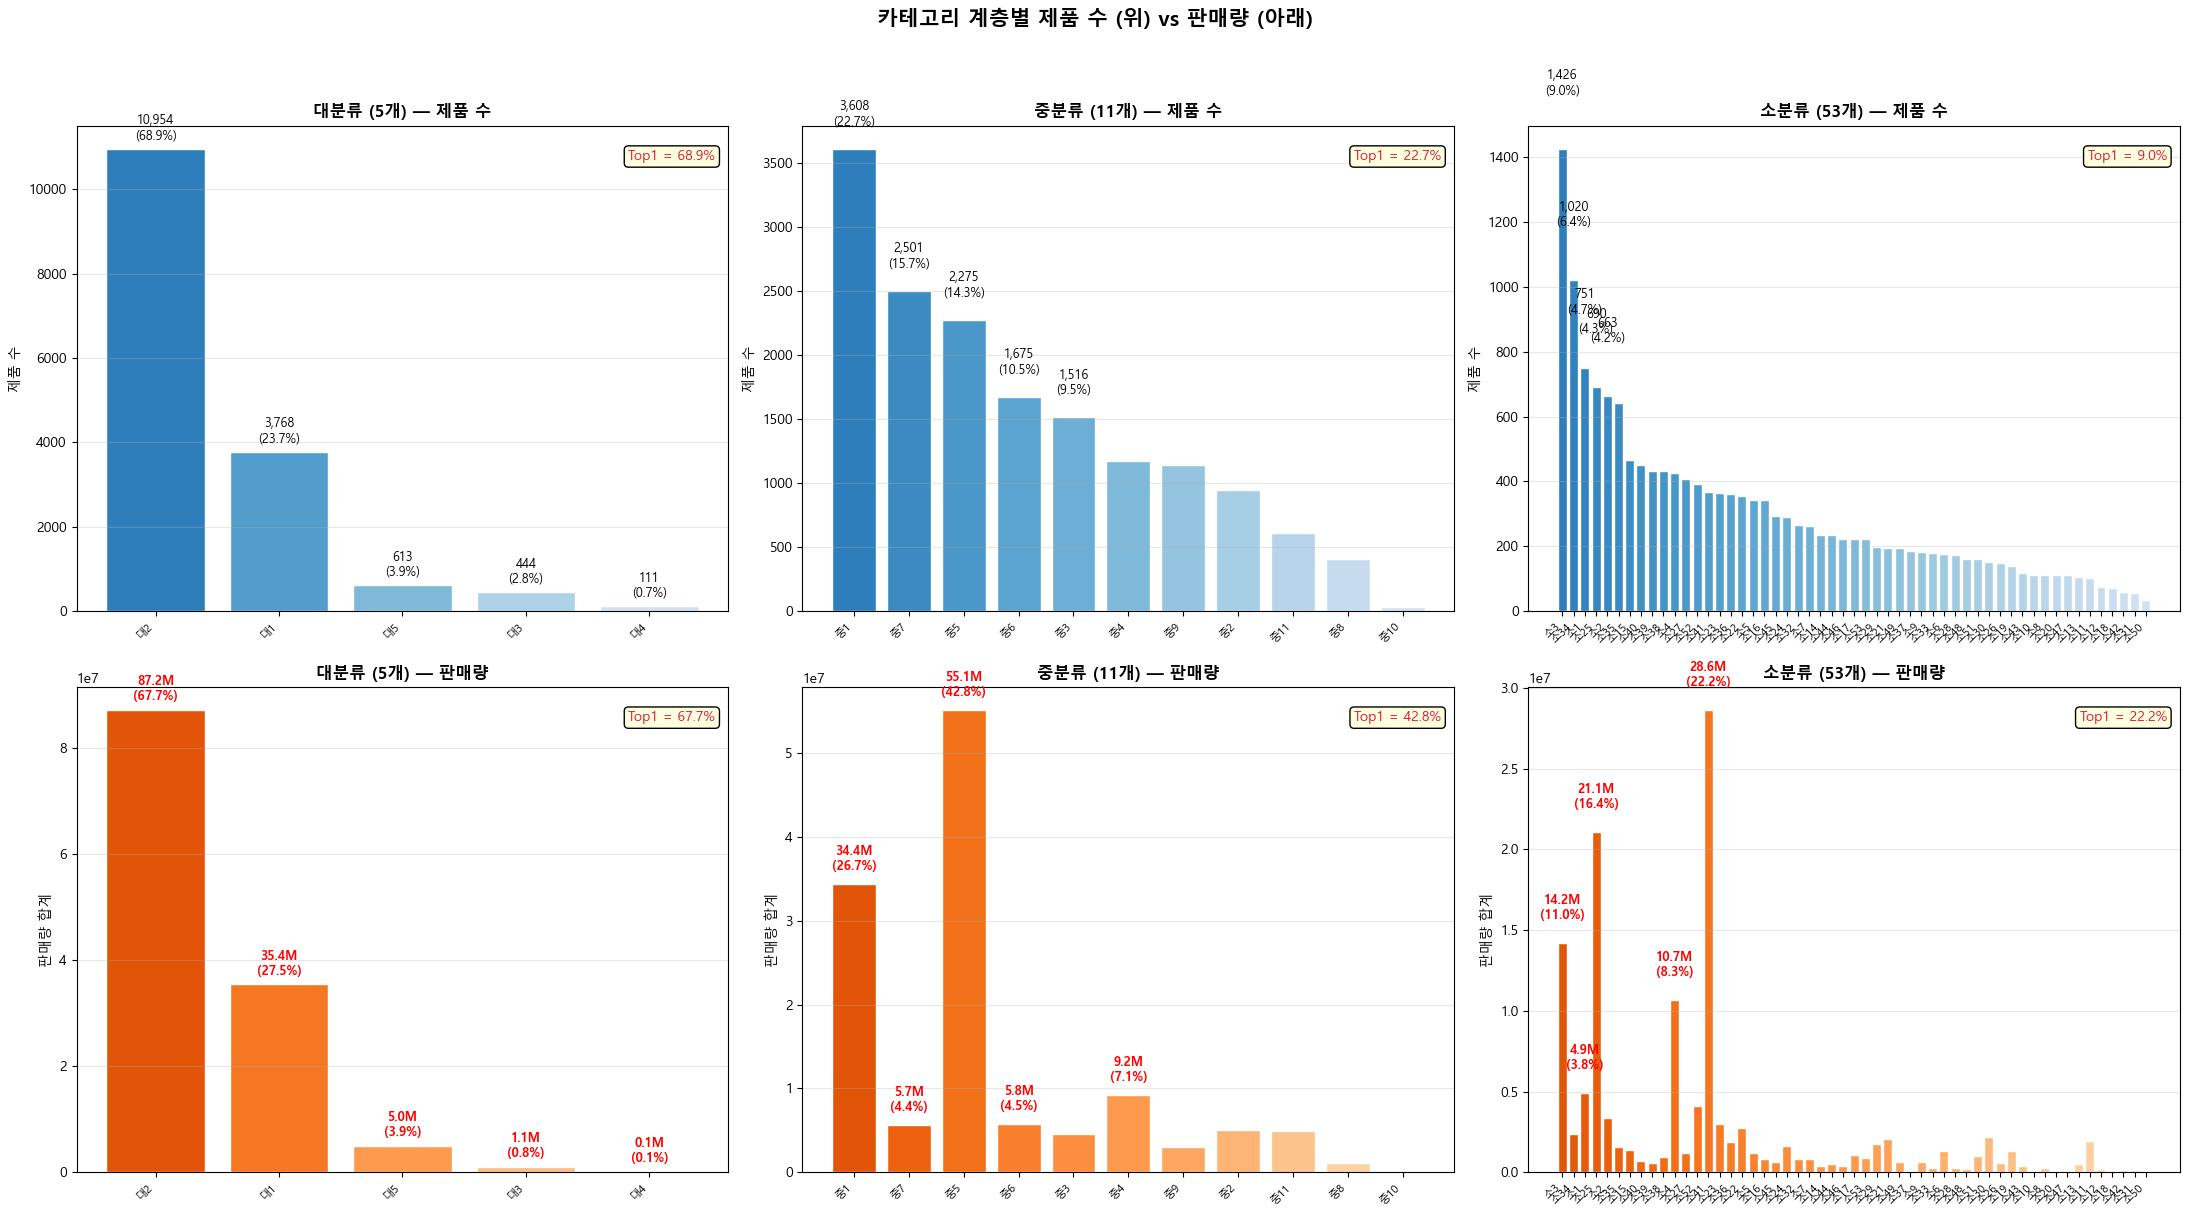

📌 카테고리별 제품 수 vs 판매량 비율 비교 — 상위 5개

[대분류]
      제품수  제품수비율(%)       판매량  판매비율(%)
대2  10954      68.9  87218401     67.7
대1   3768      23.7  35441662     27.5
대5    613       3.9   4961560      3.9
대3    444       2.8   1078827      0.8
대4    111       0.7     85411      0.1

[중분류]
     제품수  제품수비율(%)       판매량  판매비율(%)
중5  2275      14.3  55131807     42.8
중1  3608      22.7  34420592     26.7
중4  1168       7.4   9203982      7.1
중6  1675      10.5   5798762      4.5
중7  2501      15.7   5671077      4.4

[소분류]
      제품수  제품수비율(%)       판매량  판매비율(%)
소41   366       2.3  28636033     22.2
소25   690       4.3  21097753     16.4
소3   1426       9.0  14227803     11.0
소4    426       2.7  10673098      8.3
소1    751       4.7   4923380      3.8


In [6]:
# ── 카테고리별 제품 수(위) vs 판매량(아래) 2×3 시각화 ─────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('카테고리 계층별 제품 수 (위) vs 판매량 (아래)',
             fontsize=15, fontweight='bold', y=1.01)

cats = ['대분류', '중분류', '소분류']

for col_idx, col in enumerate(cats):
    ax_top    = axes[0][col_idx]
    ax_bottom = axes[1][col_idx]

    product_cnt   = train[col].value_counts().sort_values(ascending=False)
    sales_by_cat  = train.groupby(col)[DATE_COLS].sum().sum(axis=1).reindex(product_cnt.index)
    n             = len(product_cnt)
    total_product = product_cnt.sum()
    total_sales   = sales_by_cat.sum()
    xlabels       = [cat_labels[col].get(name, name) for name in product_cnt.index]

    # ── 위: 제품 수 ────────────────────────────────────────────────────────
    colors_top = plt.cm.Blues_r([0.3 + 0.5 * i / max(n - 1, 1) for i in range(n)])
    bars_top   = ax_top.bar(range(n), product_cnt.values, color=colors_top, edgecolor='white')
    
    for j, (bar, val) in enumerate(zip(bars_top, product_cnt.values)):
        if j < 5:  # 상위 5개까지만 텍스트 표시
            # 💡 [핵심 변경 포인트] 비율 계산 후 줄바꿈(\n)으로 추가
            pct = (val / total_product) * 100
            ax_top.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + total_product * 0.01,
                        f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
            
    top1_pct = product_cnt.values[0] / total_product * 100
    ax_top.text(0.98, 0.95, f'Top1 = {top1_pct:.1f}%',
                transform=ax_top.transAxes, ha='right', va='top', fontsize=10,
                color='crimson', bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))
    ax_top.set_title(f'{col} ({n}개) — 제품 수', fontsize=12, fontweight='bold')
    ax_top.set_ylabel('제품 수')
    ax_top.set_xticks(range(n))
    ax_top.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
    ax_top.grid(alpha=0.3, axis='y')
    
    # ── 아래: 판매량 ────────────────────────────────────────────────────────
    colors_bot = plt.cm.Oranges_r([0.3 + 0.5 * i / max(n - 1, 1) for i in range(n)])
    bars_bot   = ax_bottom.bar(range(n), sales_by_cat.values, color=colors_bot, edgecolor='white')
    
    # 💡 [핵심 변경 포인트 1] 판매량 기준으로 진짜 Top 5인 카테고리를 미리 뽑아둠!
    top5_sales_cats = sales_by_cat.sort_values(ascending=False).head(5).index

    for j, (bar, val) in enumerate(zip(bars_bot, sales_by_cat.values)):
        current_cat = sales_by_cat.index[j] # 지금 순서를 돌고 있는 막대의 카테고리 이름
        
        # 무조건 왼쪽 5개가 아니라, 현재 카테고리가 '판매량 Top 5' 안에 속할 때만 %를 달아라!
        if current_cat in top5_sales_cats: 
            pct = (val / total_sales) * 100
            ax_bottom.text(bar.get_x() + bar.get_width()/2,
                           bar.get_height() + total_sales * 0.01,
                           f'{val/1e6:.1f}M\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9,
                           color='red', fontweight='bold') # 👈 눈에 확 띄게 빨간색 굵은 글씨로 포인트!
                           
    # 💡 [핵심 변경 포인트 2] 무조건 0번 자리가 아니라, .max()를 써서 진짜 판매량 1등을 찾는다!
    real_top1_sales = sales_by_cat.max()
    top1_sales_pct = (real_top1_sales / total_sales) * 100
    
    ax_bottom.text(0.98, 0.95, f'Top1 = {top1_sales_pct:.1f}%',
                   transform=ax_bottom.transAxes, ha='right', va='top', fontsize=10,
                   color='crimson', bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))
    ax_bottom.set_title(f'{col} ({n}개) — 판매량', fontsize=12, fontweight='bold')
    ax_bottom.set_ylabel('판매량 합계')
    ax_bottom.set_xticks(range(n))
    ax_bottom.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
    ax_bottom.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ── 수치 요약 ──────────────────────────────────────────────────────────────
print('=' * 60)
print('📌 카테고리별 제품 수 vs 판매량 비율 비교 — 상위 5개')
print('=' * 60)
for col in cats:
    print(f'\n[{col}]')
    product_cnt  = train[col].value_counts()
    sales_by_cat = train.groupby(col)[DATE_COLS].sum().sum(axis=1)
    summary = pd.DataFrame({
        '제품수'        : product_cnt,
        '제품수비율(%)' : (product_cnt / product_cnt.sum() * 100).round(1),
        '판매량'        : sales_by_cat,
        '판매비율(%)'   : (sales_by_cat / sales_by_cat.sum() * 100).round(1),
    }).sort_values('판매량', ascending=False).head(5)
    summary.index = [cat_labels[col].get(i, i) for i in summary.index]
    print(summary.to_string())

### 2-2. 판매량 분포 
> Long Tail + 로렌츠 곡선

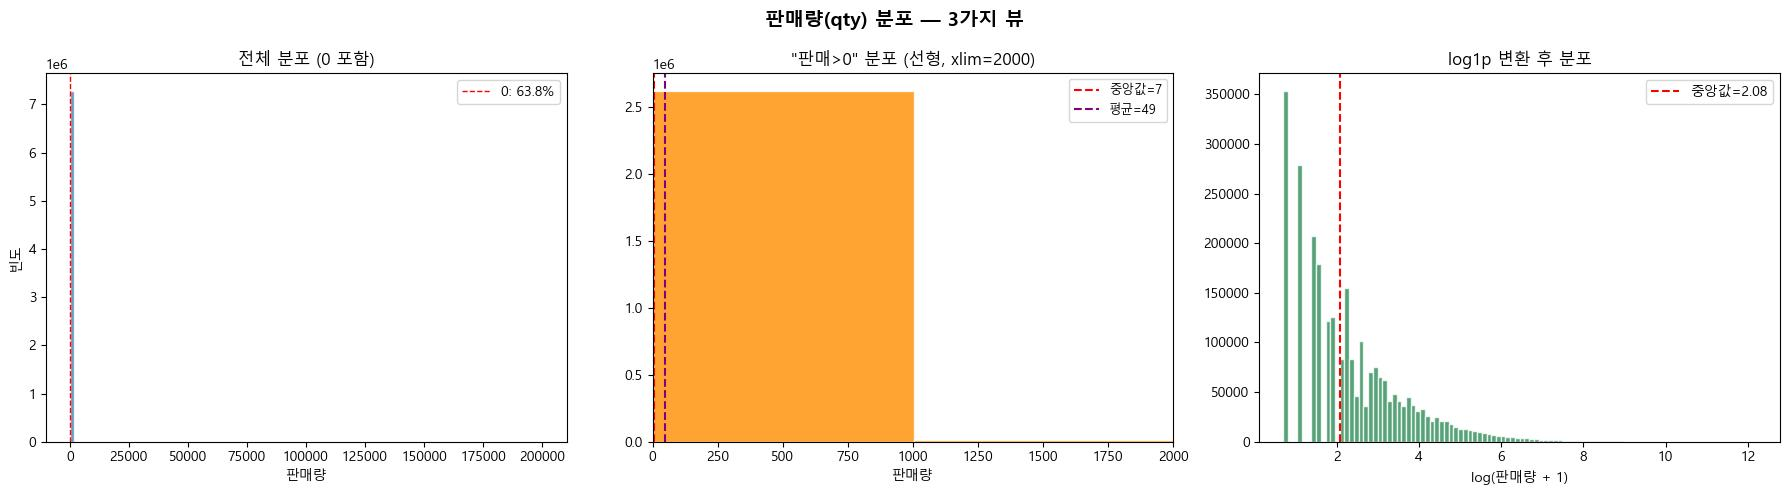


💡 스케일 압축: 원본 0~200,420 → log 변환 후 0~12.2
   압축 비율: 16417배 축소


In [7]:
# ── 판매량 분포 3가지 뷰 ──────────────────────────────────────────────────
# 뷰1: 전체 분포(0 포함) / 뷰2: 판매>0만 (선형) / 뷰3: log1p 변환 후
# → 세 뷰를 나란히 보면 "왜 log 변환이 필요한지" 눈으로 이해됨
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('판매량(qty) 분포 — 3가지 뷰', fontsize=14, fontweight='bold')

qty_nonzero = qty_all[qty_all > 0]

ax = axes[0]
ax.hist(qty_all, bins=100, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('전체 분포 (0 포함)')
ax.set_xlabel('판매량'); ax.set_ylabel('빈도')
ax.axvline(0, color='red', ls='--', lw=1, label=f'0: {(qty_all==0).mean():.1%}')
ax.legend()

ax = axes[1]
ax.hist(qty_nonzero, bins=200, color='darkorange', alpha=0.8, edgecolor='white')
ax.set_xlim(0, 2000)
ax.set_title('"판매>0" 분포 (선형, xlim=2000)')
ax.set_xlabel('판매량')
ax.axvline(np.median(qty_nonzero), color='red',    ls='--', lw=1.5,
           label=f'중앙값={np.median(qty_nonzero):.0f}')
ax.axvline(qty_nonzero.mean(),    color='purple', ls='--', lw=1.5,
           label=f'평균={qty_nonzero.mean():.0f}')
ax.legend(fontsize=9)

ax = axes[2]
qty_log = np.log1p(qty_nonzero)
ax.hist(qty_log, bins=100, color='seagreen', alpha=0.8, edgecolor='white')
ax.set_title('log1p 변환 후 분포')
ax.set_xlabel('log(판매량 + 1)')
ax.axvline(np.median(qty_log), color='red', ls='--', lw=1.5,
           label=f'중앙값={np.median(qty_log):.2f}')
ax.legend()

plt.tight_layout()
plt.show()
print(f'\n💡 스케일 압축: 원본 0~{qty_all.max():,} → log 변환 후 0~{np.log1p(qty_all.max()):.1f}')
print(f'   압축 비율: {qty_all.max() / np.log1p(qty_all.max()):.0f}배 축소')

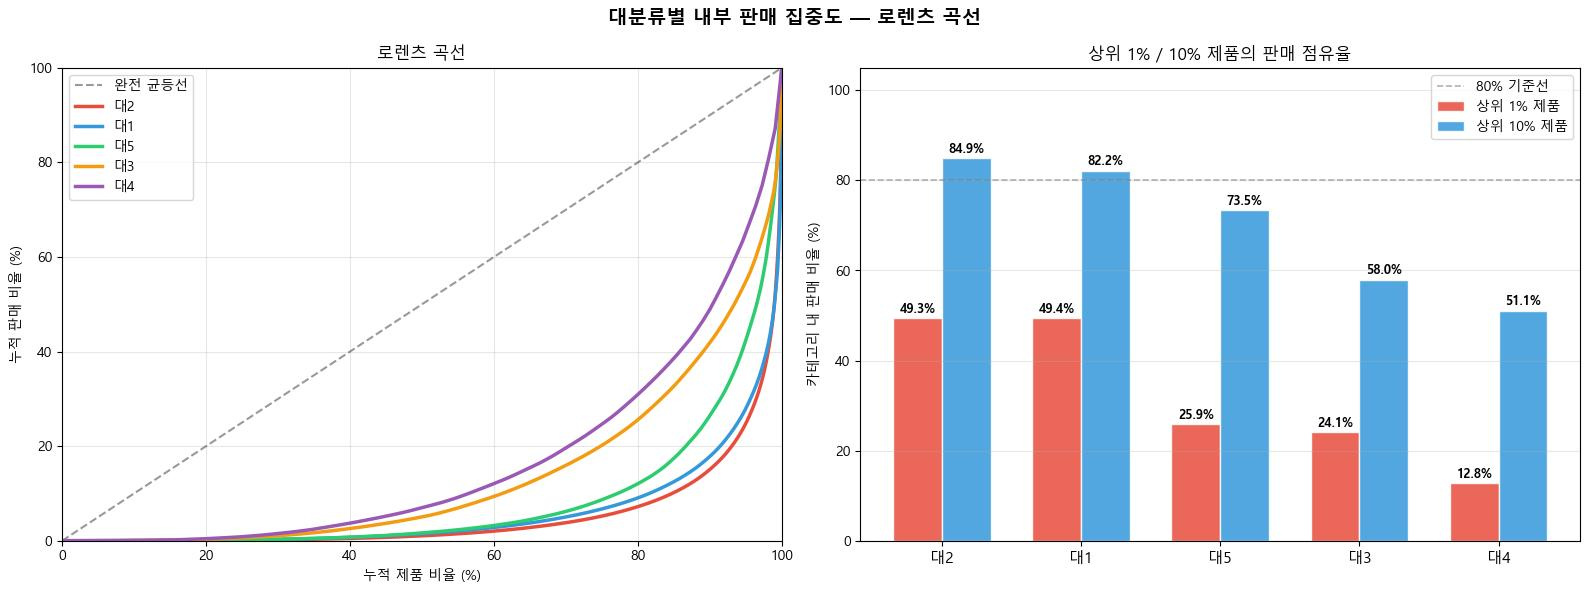

In [8]:
# ── 로렌츠 곡선 — 카테고리 내부도 Long Tail인지 확인 ─────────────────────
# X축=누적 제품 비율, Y축=누적 판매 비율
# 대각선에 가까울수록 균등, 아래로 처질수록 소수 제품이 판매를 독식함
train['total_sales'] = train[DATE_COLS].sum(axis=1)
cats_ordered = train.groupby('대분류')['total_sales'].sum().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('대분류별 내부 판매 집중도 — 로렌츠 곡선', fontsize=14, fontweight='bold')
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

ax = axes[0]
ax.plot([0, 100], [0, 100], 'k--', lw=1.5, alpha=0.4, label='완전 균등선')
for i, cat in enumerate(cats_ordered):
    subset = train[train['대분류'] == cat]['total_sales'].sort_values(ascending=True).values
    cumsum = np.cumsum(subset) / subset.sum() * 100
    x      = np.linspace(0, 100, len(cumsum))
    label  = cat_labels['대분류'].get(cat, cat)
    ax.plot(x, cumsum, color=colors[i], linewidth=2.5, label=label)
ax.set_xlabel('누적 제품 비율 (%)')
ax.set_ylabel('누적 판매 비율 (%)')
ax.set_title('로렌츠 곡선')
ax.legend(); ax.grid(alpha=0.3)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)

ax = axes[1]
labels_list = [cat_labels['대분류'].get(c, c) for c in cats_ordered]
top1_pcts, top10_pcts = [], []
for cat in cats_ordered:
    subset = train[train['대분류'] == cat]['total_sales'].sort_values(ascending=False)
    total  = subset.sum()
    top1_pcts.append(subset.iloc[:max(1, int(len(subset)*0.01))].sum() / total * 100)
    top10_pcts.append(subset.iloc[:max(1, int(len(subset)*0.1))].sum() / total * 100)
x = np.arange(len(labels_list)); width = 0.35
bars1 = ax.bar(x - width/2, top1_pcts,  width, label='상위 1% 제품',
               color='#e74c3c', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, top10_pcts, width, label='상위 10% 제품',
               color='#3498db', alpha=0.85, edgecolor='white')
for bar, val in zip(bars1, top1_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, top10_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.axhline(80, color='gray', linestyle='--', lw=1.2, alpha=0.6, label='80% 기준선')
ax.set_xticks(x); ax.set_xticklabels(labels_list, fontsize=11)
ax.set_ylabel('카테고리 내 판매 비율 (%)')
ax.set_title('상위 1% / 10% 제품의 판매 점유율')
ax.legend(); ax.grid(alpha=0.3, axis='y'); ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()
train.drop(columns=['total_sales'], inplace=True)

### 2-3. 일별 판매 트렌드 
> 급락 구간 포함

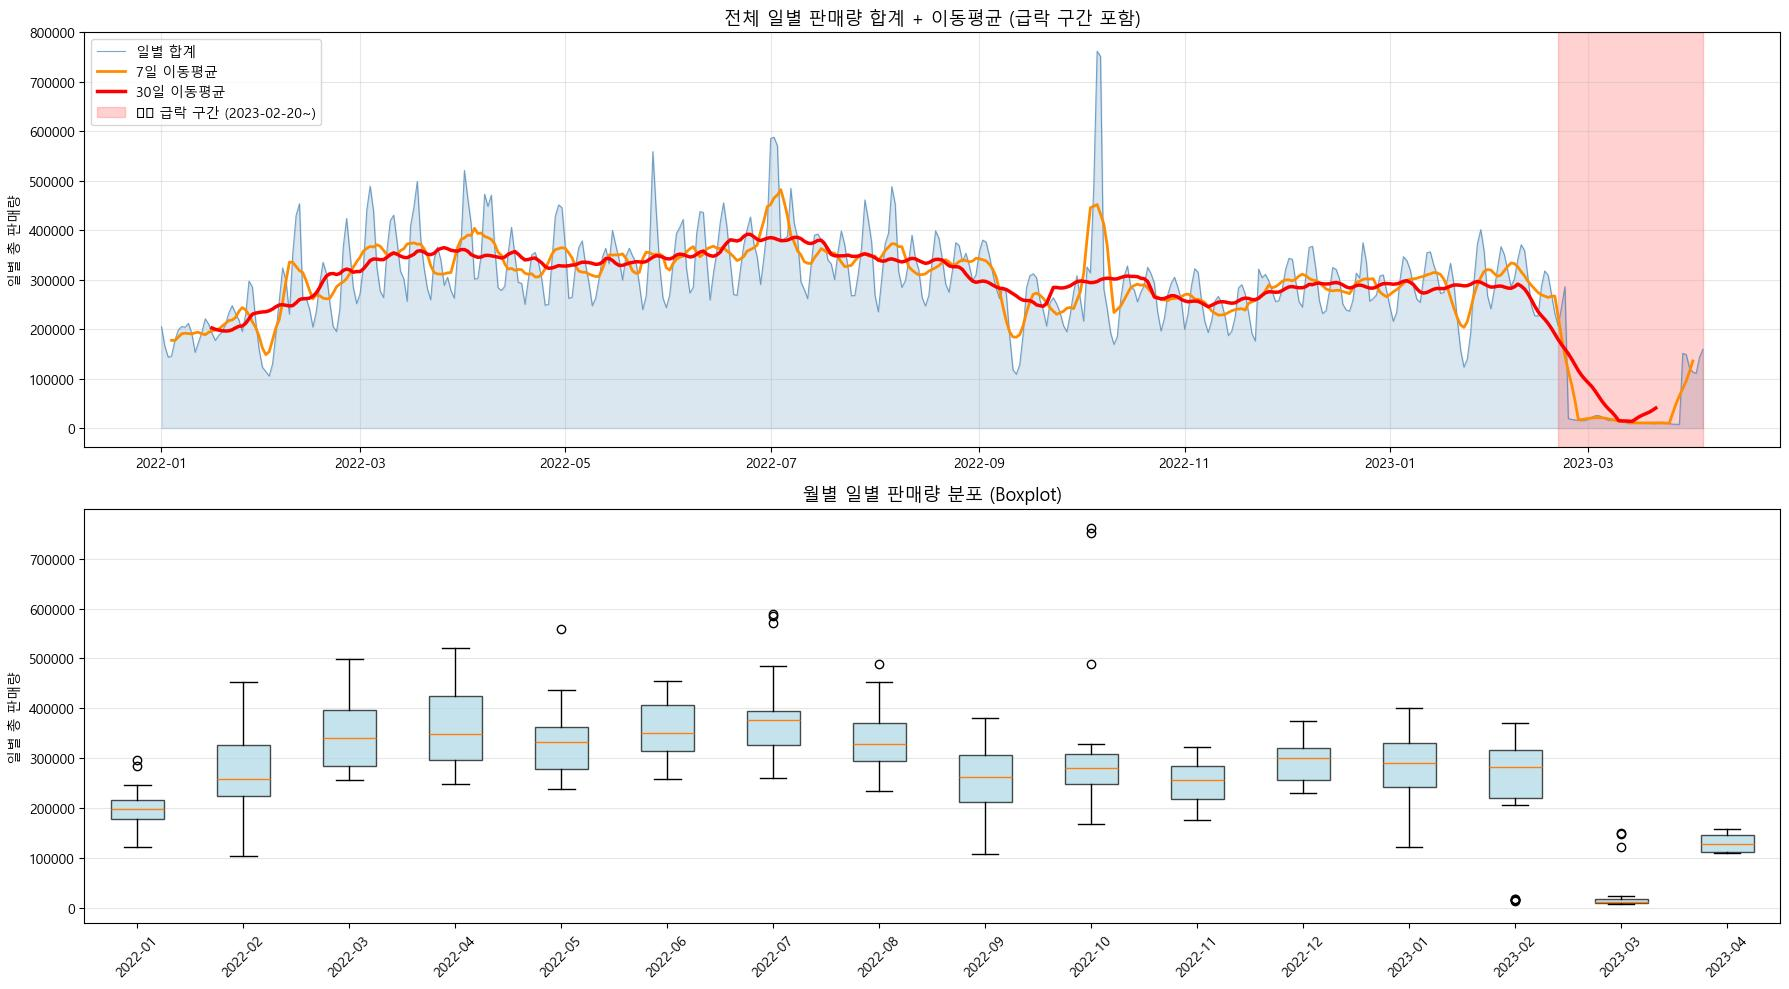


📊 급락 구간 분석
  정상 구간 일평균 : 305,103
  급락 구간 일평균 : 49,274  (16.2%)
  → STEP 3-0에서 3가지 처리 방법 중 선택


In [9]:
# ── 2-3. 일별 판매 트렌드 계산 ─────────────────────────────────────────────────
# ⚠️ daily_total, ma30, upper, lower 변수는
#    2-5 Spike 탐지와 STEP 3-0 급락 처리에서 재사용됩니다.

daily_total = train[DATE_COLS].sum(axis=0)
daily_total.index = pd.to_datetime(daily_total.index)

ma7   = daily_total.rolling(7,  center=True).mean()
ma30  = daily_total.rolling(30, center=True).mean()
std30 = daily_total.rolling(30, center=True).std()
upper = ma30 + 2 * std30
lower = ma30 - 2 * std30

# 급락 구간 정의 (2-3 시각화 + STEP 3-0에서 처리)
CRASH_START = pd.Timestamp('2023-02-20')
CRASH_END   = pd.Timestamp('2023-04-04')

# ── 트렌드 + 월별 박스플롯 시각화 ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

ax = axes[0]
ax.fill_between(daily_total.index, daily_total.values, alpha=0.2, color='steelblue')
ax.plot(daily_total.index, daily_total.values, color='steelblue', lw=0.8, alpha=0.7, label='일별 합계')
ax.plot(ma7.index,  ma7.values,  color='darkorange', lw=2,   label='7일 이동평균')
ax.plot(ma30.index, ma30.values, color='red',        lw=2.5, label='30일 이동평균')
ax.axvspan(CRASH_START, CRASH_END, alpha=0.18, color='red',
           label=f'⚠️ 급락 구간 ({CRASH_START.date()}~)')
ax.set_title('전체 일별 판매량 합계 + 이동평균 (급락 구간 포함)', fontsize=13)
ax.set_ylabel('일별 총 판매량')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

ax = axes[1]
temp = pd.DataFrame({'date': daily_total.index, 'total': daily_total.values})
temp['yearmonth'] = temp['date'].dt.strftime('%Y-%m')
month_data   = [group['total'].values for _, group in temp.groupby('yearmonth')]
month_labels = list(temp['yearmonth'].unique())
ax.boxplot(month_data, labels=month_labels, patch_artist=True,
           boxprops=dict(facecolor='lightblue', alpha=0.7))
ax.set_title('월별 일별 판매량 분포 (Boxplot)', fontsize=13)
ax.set_ylabel('일별 총 판매량')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 급락 구간 수치 확인
normal_avg = daily_total[daily_total.index < CRASH_START].mean()
crash_avg  = daily_total[daily_total.index >= CRASH_START].mean()
print(f'\n📊 급락 구간 분석')
print(f'  정상 구간 일평균 : {normal_avg:,.0f}')
print(f'  급락 구간 일평균 : {crash_avg:,.0f}  ({crash_avg/normal_avg:.1%})')
print(f'  → STEP 3-0에서 3가지 처리 방법 중 선택')

### 2-4. 요일·월별 판매 패턴

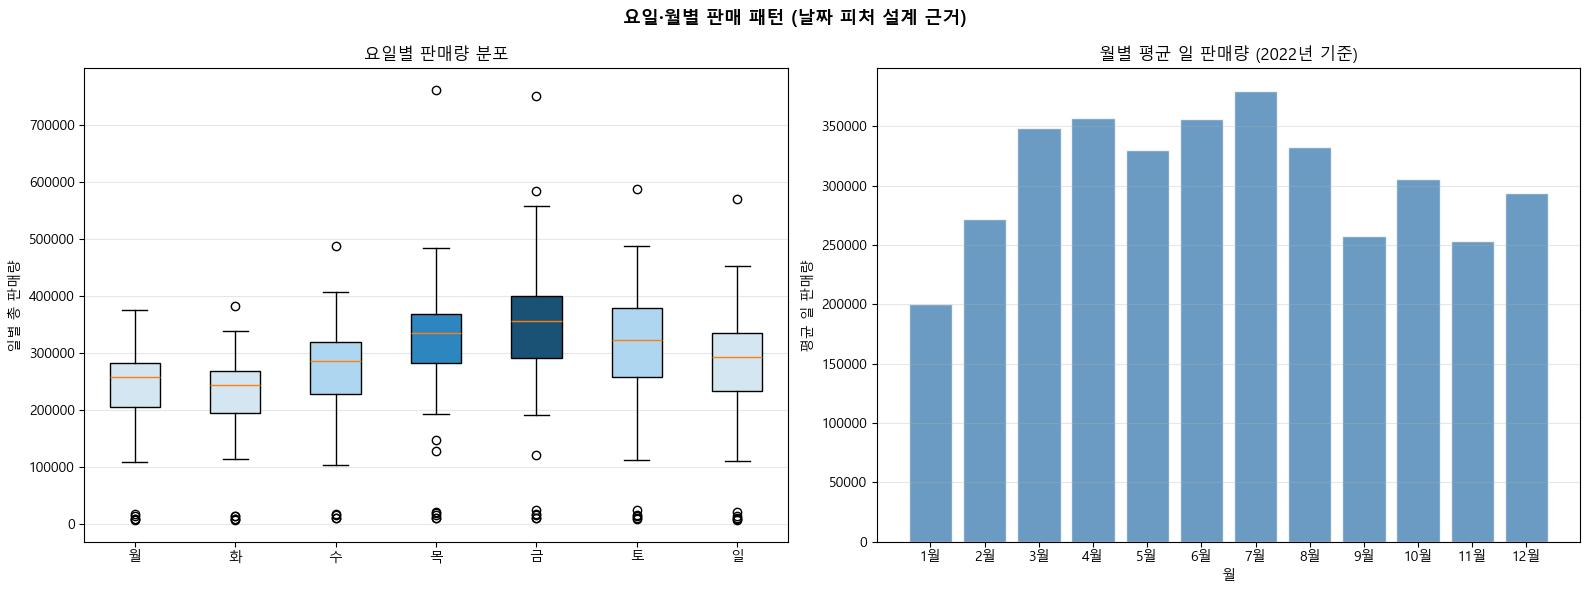

In [10]:
# ── 요일·월별 판매 패턴 시각화 ────────────────────────────────────────────
# 목적: 날짜 피처(day_of_week, month, is_weekend)를 추가할 근거 확보
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('요일·월별 판매 패턴 (날짜 피처 설계 근거)', fontsize=13, fontweight='bold')

temp = pd.DataFrame({'date': pd.to_datetime(daily_total.index), 'total': daily_total.values})
temp['day_of_week'] = temp['date'].dt.dayofweek
temp['month']       = temp['date'].dt.month
dow_labels = ['월', '화', '수', '목', '금', '토', '일']

ax = axes[0]
dow_data = [temp[temp['day_of_week'] == d]['total'].values for d in range(7)]
bp = ax.boxplot(dow_data, labels=dow_labels, patch_artist=True)
colors_dow = ['#d4e6f1','#d4e6f1','#aed6f1','#2e86c1','#1a5276','#aed6f1','#d4e6f1']
for patch, c in zip(bp['boxes'], colors_dow):
    patch.set_facecolor(c)
ax.set_title('요일별 판매량 분포')
ax.set_ylabel('일별 총 판매량')
ax.grid(alpha=0.3, axis='y')

ax = axes[1]
temp_2022   = temp[temp['date'].dt.year == 2022]
monthly_avg = temp_2022.groupby('month')['total'].mean()
month_kor   = ['1월','2월','3월','4월','5월','6월','7월','8월','9월','10월','11월','12월']
ax.bar(monthly_avg.index, monthly_avg.values, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('월별 평균 일 판매량 (2022년 기준)')
ax.set_xlabel('월'); ax.set_ylabel('평균 일 판매량')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_kor)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 2-5. Spike(이상치) 탐지 
> MA30 ± 2σ 기준

감지된 Spike 날짜 수: 16일
날짜 목록 (앞 10개): ['2022-02-10', '2022-02-11', '2022-04-01', '2022-04-29', '2022-04-30', '2022-05-27', '2022-07-01', '2022-07-02', '2022-07-03', '2022-08-06']


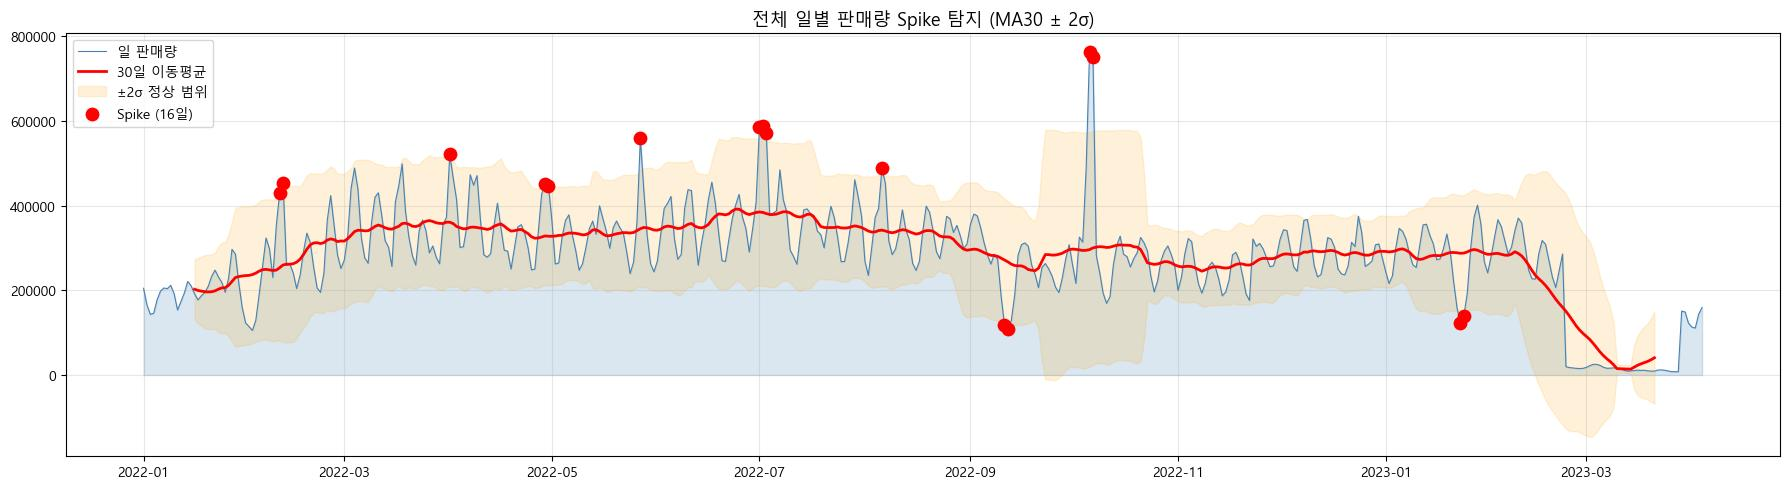

In [11]:
# ── Spike 탐지 (MA30 ± 2σ) ────────────────────────────────────────────────
# 정상 범위(MA30 ± 2σ)를 벗어나는 날 = Spike
# ⚠️ ma30, upper, lower 는 2-3에서 이미 계산됨
spike_dates = daily_total[(daily_total > upper) | (daily_total < lower)].index

print(f'감지된 Spike 날짜 수: {len(spike_dates)}일')
print(f'날짜 목록 (앞 10개): {[str(d.date()) for d in spike_dates[:10]]}')

# ── Spike 시각화 ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 5))
ax.fill_between(daily_total.index, daily_total, alpha=0.2, color='steelblue')
ax.plot(daily_total.index, daily_total, lw=0.8, color='steelblue', label='일 판매량')
ax.plot(ma30.index, ma30.values, 'r-', lw=2, label='30일 이동평균')
ax.fill_between(ma30.index, lower, upper, alpha=0.15, color='orange', label='±2σ 정상 범위')
ax.scatter(spike_dates, daily_total[spike_dates], color='red', zorder=5, s=80,
           label=f'Spike ({len(spike_dates)}일)')
ax.set_title('전체 일별 판매량 Spike 탐지 (MA30 ± 2σ)', fontsize=13)
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

1. Spike 날 브랜드별 기여도 — 한 브랜드가 66% 독점이라는 것  
2. 그 브랜드의 전후 패턴 — 딱 5일만 폭증 후 즉시 정상화  

In [12]:
import re

# ── 브랜드명 단축 변환 전 겹침(충돌) 검사 (정규표현식 업그레이드) ────────────

unique_brands = train['브랜드'].astype(str).unique()
brand_labels = {}
overlap_check = {} 

for b in unique_brands:
    # 💡 [핵심 변경] 정규표현식: 문자열의 맨 끝($)에 있는 연속된 숫자(\d+)를 찾아라!
    match = re.search(r'\d+$', b)
    
    if match:
        # 끝에 숫자가 있으면, 그 숫자에서 앞의 0을 떼어냄 (00001 -> 1, 0003 -> 3)
        number = match.group().lstrip('0') or '0'
        short_name = f'브{number}'
    else:
        # 혹시라도 끝에 숫자가 아예 없는 이상한 이름이면 그냥 원본을 씀
        short_name = b 
    
    # 겹침 검사 로직
    if short_name in overlap_check:
        overlap_check[short_name].append(b)
    else:
        overlap_check[short_name] = [b]
        
    brand_labels[b] = short_name

# ── 검사 결과 출력 ──────────────────────────────────────────────────────────
overlaps = {k: v for k, v in overlap_check.items() if len(v) > 1}

print("=" * 55)
print("🔍 업그레이드된 브랜드 이름 단축 시뮬레이션 결과")
print("=" * 55)
print(f"총 고유 브랜드 수: {len(unique_brands)}개")

if overlaps:
    print(f"🚨 이름이 겹치는 브랜드가 {len(overlaps)}건 발견!")
    for short_name, raw_names in list(overlaps.items())[:5]:
        print(f" - '{short_name}' (이)라고 불리게 될 원본들: {raw_names}")
else:
    print("✅ 숫자만 발라냈고 겹침도 없음!")
    items = list(brand_labels.items())[:5] # 5개 뽑아서 어떻게 변했나 보자
    print(f"예시: {'  /  '.join(f'{k} → {v}' for k, v in items)}")

🔍 업그레이드된 브랜드 이름 단축 시뮬레이션 결과
총 고유 브랜드 수: 3170개
✅ 숫자만 발라냈고 겹침도 없음!
예시: B002-00001 → 브1  /  B002-00002 → 브2  /  B002-00003 → 브3  /  B002-00005 → 브5  /  B002-00006 → 브6


가장 큰 Spike 날짜: 2022-10-06  (전체 판매량: 762,097)


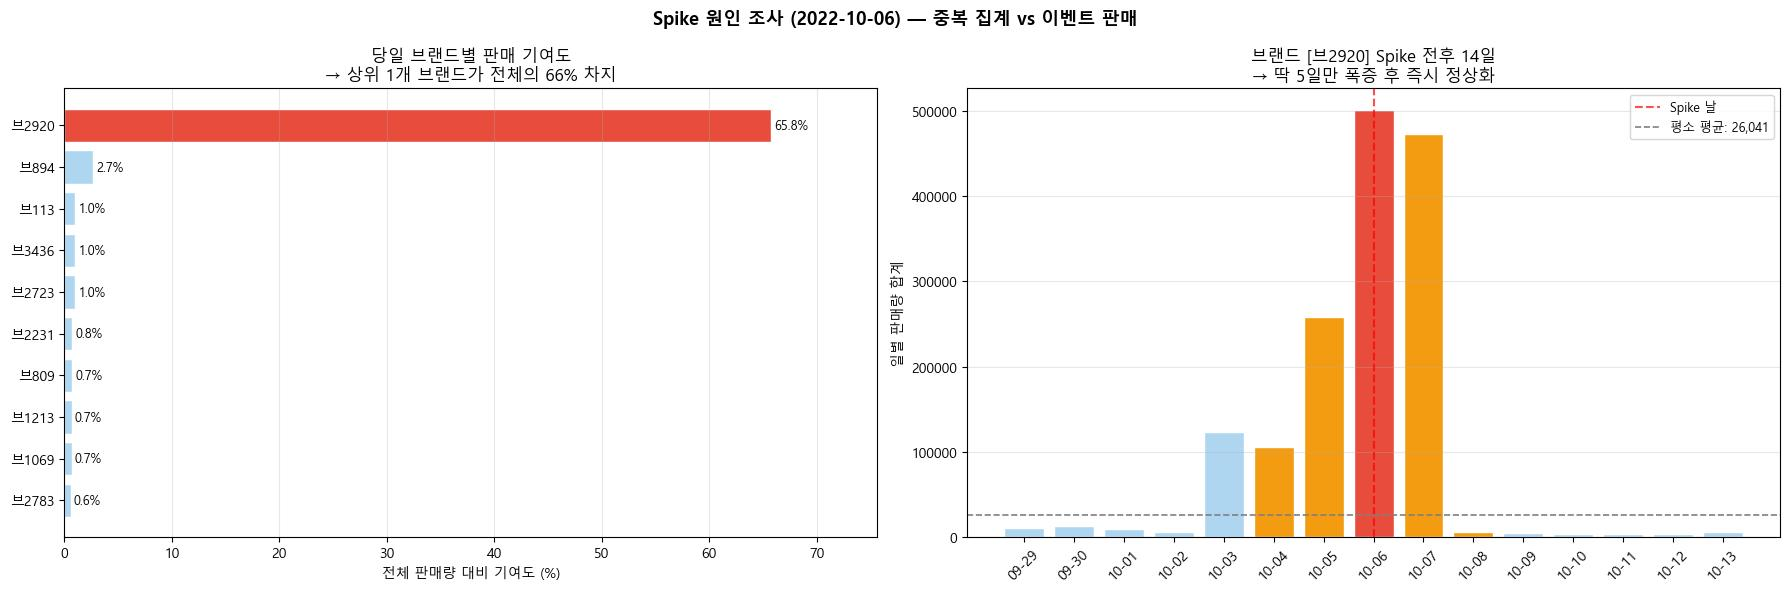


📊 Spike 원인 분석 결론
  완전히 동일한 중복 행   : 0개 (전체 데이터 확인)
  Spike 날 1위 브랜드     : 브2920 (원본: B002-02920)
  당일 전체 대비 기여도   : 65.8%
  폭증 기간               : 약 5일 후 즉시 정상화
  평소 일평균             : 26,041
  Spike 당일              : 501,258
  배율                    : 19x

💡 중복 집계 = 매일 일정하게 중복 → 이 패턴과 불일치
💡 이벤트 판매 = 특정 기간만 폭증 후 정상화 → 이 패턴과 일치
→ 결론: 클리핑(상한선 깎기) 유지 / MA 대체는 실제 패턴을 지움


In [13]:
# ── Spike 원인 조사 — 중복 집계인가? 이벤트 판매인가? ─────────────────────
daily_total = train[DATE_COLS].sum(axis=0)
daily_total.index = pd.to_datetime(DATE_COLS)

ma30  = daily_total.rolling(30, center=True).mean()
std30 = daily_total.rolling(30, center=True).std()
upper = ma30 + 2 * std30

# ✅ 변수명 변경: spike_dates 덮어쓰기 방지
spike_dates_upper = daily_total[daily_total > upper].index

biggest_spike_date = daily_total[spike_dates_upper].idxmax()
spike_col          = str(biggest_spike_date.date())
spike_total        = daily_total[biggest_spike_date]

print(f"가장 큰 Spike 날짜: {spike_col}  (전체 판매량: {spike_total:,.0f})")

# ── 당일 브랜드별 기여도 계산 ─────────────────────────────────────────────
brand_contrib = (
    train.groupby('브랜드')[spike_col]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
brand_contrib_pct = brand_contrib / spike_total * 100

short_brand_names = [brand_labels.get(b, b) for b in brand_contrib.index]

# ── 시각화 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'Spike 원인 조사 ({spike_col}) — 중복 집계 vs 이벤트 판매',
             fontsize=13, fontweight='bold')

ax = axes[0]
colors = ['#e74c3c'] + ['#aed6f1'] * (len(brand_contrib) - 1)
bars = ax.barh(short_brand_names[::-1], brand_contrib_pct.values[::-1],
               color=colors[::-1], edgecolor='white')
for bar, pct in zip(bars, brand_contrib_pct.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)
ax.set_xlabel('전체 판매량 대비 기여도 (%)')
ax.set_title(f'당일 브랜드별 판매 기여도\n→ 상위 1개 브랜드가 전체의 {brand_contrib_pct.iloc[0]:.0f}% 차지')
ax.grid(alpha=0.3, axis='x')
ax.set_xlim(0, brand_contrib_pct.iloc[0] * 1.15)

top_brand_raw   = brand_contrib.index[0]
top_brand_short = brand_labels.get(top_brand_raw, top_brand_raw)

brand_daily = train[train['브랜드'] == top_brand_raw][DATE_COLS].sum(axis=0)
brand_daily.index = pd.to_datetime(DATE_COLS)

window_start = biggest_spike_date - pd.Timedelta(days=7)
window_end   = biggest_spike_date + pd.Timedelta(days=7)
window_data  = brand_daily[window_start:window_end]

ax = axes[1]
bar_colors = ['#e74c3c' if d == biggest_spike_date else
              '#f39c12' if abs((d - biggest_spike_date).days) <= 2 else
              '#aed6f1'
              for d in window_data.index]
ax.bar(range(len(window_data)), window_data.values, color=bar_colors, edgecolor='white')
ax.set_xticks(range(len(window_data)))
ax.set_xticklabels([d.strftime('%m-%d') for d in window_data.index], rotation=45)
ax.axvline(7, color='red', linestyle='--', lw=1.5, alpha=0.7, label='Spike 날')

normal_mean = brand_daily[brand_daily.index < window_start].mean()
ax.axhline(normal_mean, color='gray', linestyle='--', lw=1.2,
           label=f'평소 평균: {normal_mean:,.0f}')
ax.set_title(f'브랜드 [{top_brand_short}] Spike 전후 14일\n→ 딱 5일만 폭증 후 즉시 정상화')
ax.set_ylabel('일별 판매량 합계')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print()
print("=" * 55)
print("📊 Spike 원인 분석 결론")
print("=" * 55)
print(f"  완전히 동일한 중복 행   : 0개 (전체 데이터 확인)")
print(f"  Spike 날 1위 브랜드     : {top_brand_short} (원본: {top_brand_raw})")
print(f"  당일 전체 대비 기여도   : {brand_contrib_pct.iloc[0]:.1f}%")
print(f"  폭증 기간               : 약 5일 후 즉시 정상화")
print(f"  평소 일평균             : {normal_mean:,.0f}")
print(f"  Spike 당일              : {brand_daily[biggest_spike_date]:,.0f}")
print(f"  배율                    : {brand_daily[biggest_spike_date]/normal_mean:.0f}x")
print()
print("💡 중복 집계 = 매일 일정하게 중복 → 이 패턴과 불일치")
print("💡 이벤트 판매 = 특정 기간만 폭증 후 정상화 → 이 패턴과 일치")
print("→ 결론: 클리핑(상한선 깎기) 유지 / MA 대체는 실제 패턴을 지움")

2-5-C 사용 Spike 날짜: 16개 / 전체 16개


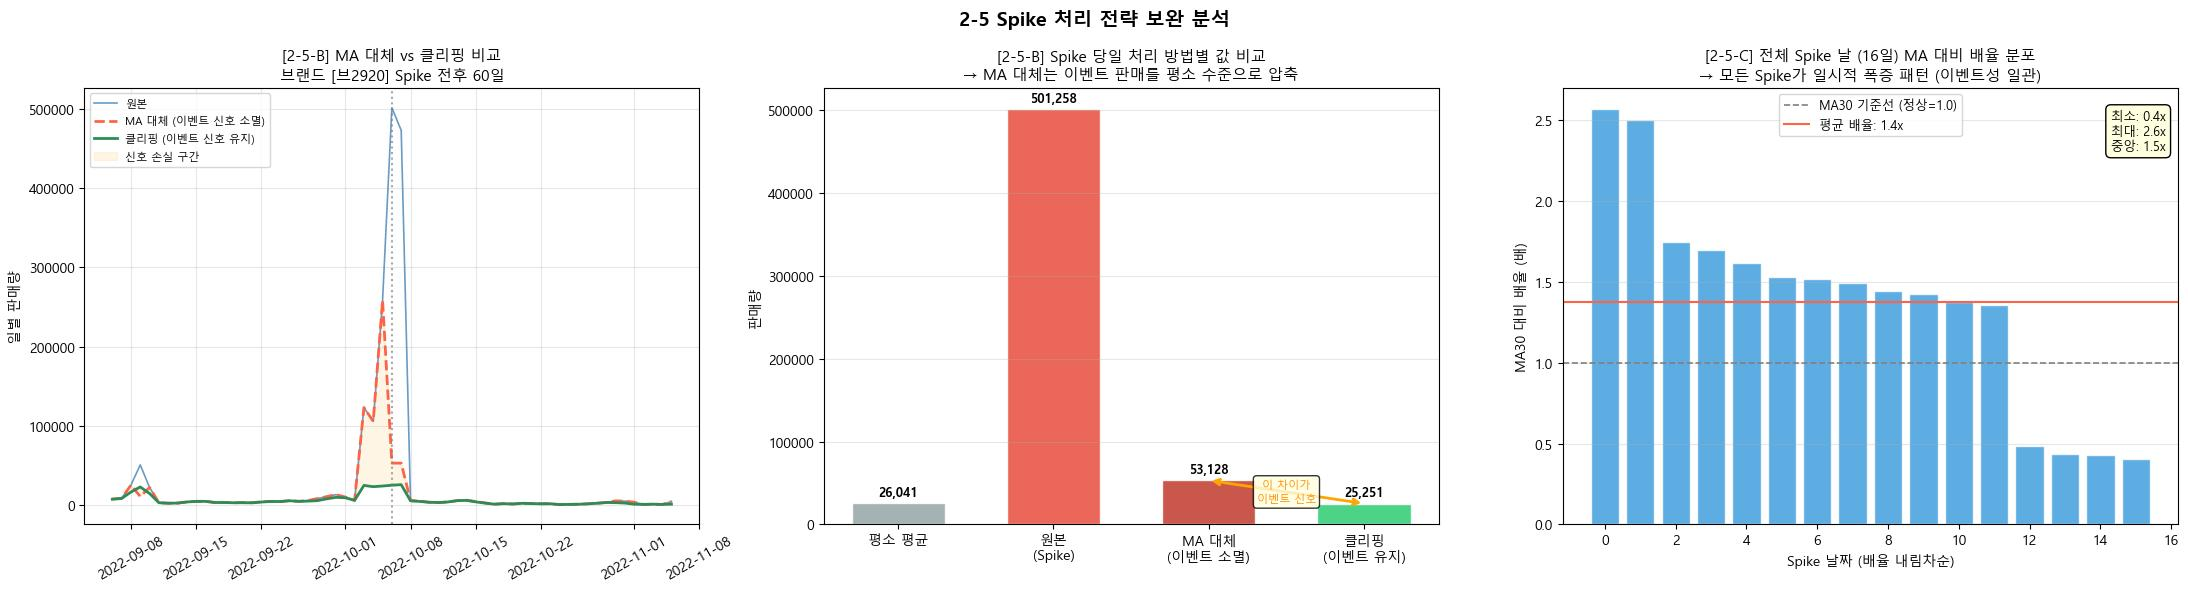

📊 2-5 보완 분석 요약
  [2-5-B] MA 대체 시 Spike 당일 손실 판매량 : -27,877개
          (원본 501,258 → MA대체 53,128 / 클리핑 25,251)
  [2-5-C] 전체 Spike 16일 평균 배율   : 1.4x
          → 모두 일시적 폭증 패턴으로 이벤트성 일반화 가능


In [14]:
# ── 2-5-B & 2-5-C: Spike 처리 전략 보완 시각화 ───────────────────────────

top_brand_raw = brand_contrib.index[0]
brand_daily   = train[train['브랜드'] == top_brand_raw][DATE_COLS].sum(axis=0)
brand_daily.index = pd.to_datetime(DATE_COLS)

# ── 2-5-B 데이터 준비 ─────────────────────────────────────────────────────
ma30_brand  = brand_daily.rolling(30, center=True, min_periods=1).mean()
std30_brand = brand_daily.rolling(30, center=True, min_periods=1).std()
upper_brand = ma30_brand + 2 * std30_brand
spike_mask  = brand_daily > upper_brand

brand_ma_replaced = brand_daily.astype(float).copy()
brand_ma_replaced[spike_mask] = ma30_brand[spike_mask]

product_data = train[train['브랜드'] == top_brand_raw][DATE_COLS]
clipped_rows = []
for idx in product_data.index:
    row    = product_data.loc[idx].astype(float)
    median = row.median()
    limit  = row.quantile(0.95) if median == 0 else median * 20
    clipped_rows.append(row.clip(upper=limit))
brand_clipped = pd.DataFrame(clipped_rows).sum(axis=0)
brand_clipped.index = pd.to_datetime(DATE_COLS)

# ── 2-5-C 데이터 준비: ✅ spike_dates (16개) 사용 ─────────────────────────
daily_total_series = train[DATE_COLS].sum(axis=0)
daily_total_series.index = pd.to_datetime(DATE_COLS)
ma30_global = daily_total_series.rolling(30, center=True, min_periods=1).mean()

spike_ratios = []
for sd in spike_dates:   # ✅ 16개짜리 spike_dates
    ma_val_c = ma30_global[sd]
    ratio    = daily_total_series[sd] / ma_val_c if (pd.notna(ma_val_c) and ma_val_c > 0) else np.nan
    spike_ratios.append({'date': sd, 'ratio': ratio})

spike_ratio_df = pd.DataFrame(spike_ratios).dropna()
print(f'2-5-C 사용 Spike 날짜: {len(spike_ratio_df)}개 / 전체 {len(spike_dates)}개')

# ── 시각화 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('2-5 Spike 처리 전략 보완 분석', fontsize=14, fontweight='bold')

# ── [왼쪽] 2-5-B-1: MA 대체 vs 클리핑 전체 기간 비교 ─────────────────────
ax = axes[0]
window = (brand_daily.index >= biggest_spike_date - pd.Timedelta(days=30)) & \
         (brand_daily.index <= biggest_spike_date + pd.Timedelta(days=30))

ax.plot(brand_daily[window].index, brand_daily[window].values,
        color='steelblue', lw=1.2, alpha=0.8, label='원본')
ax.plot(brand_ma_replaced[window].index, brand_ma_replaced[window].values,
        color='tomato', lw=2, linestyle='--', label='MA 대체 (이벤트 신호 소멸)')
ax.plot(brand_clipped[window].index, brand_clipped[window].values,
        color='seagreen', lw=2, label='클리핑 (이벤트 신호 유지)')
ax.axvline(biggest_spike_date, color='gray', linestyle=':', lw=1.5, alpha=0.7)
ax.fill_between(brand_daily[window].index,
                brand_ma_replaced[window].values,
                brand_clipped[window].values,
                alpha=0.1, color='orange', label='신호 손실 구간')
ax.set_title(f'[2-5-B] MA 대체 vs 클리핑 비교\n브랜드 [{brand_labels.get(top_brand_raw, top_brand_raw)}] Spike 전후 60일',
             fontsize=11)
ax.set_ylabel('일별 판매량')
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=30)

# ── [가운데] 2-5-B-2: Spike 당일 처리 방법별 값 비교 막대 ─────────────────
ax = axes[1]
spike_val   = brand_daily[biggest_spike_date]
ma_val      = brand_ma_replaced[biggest_spike_date]
clipped_val = brand_clipped[biggest_spike_date]
normal_val  = brand_daily[brand_daily.index < biggest_spike_date - pd.Timedelta(days=7)].mean()

labels     = ['평소 평균', '원본\n(Spike)', 'MA 대체\n(이벤트 소멸)', '클리핑\n(이벤트 유지)']
values     = [normal_val, spike_val, ma_val, clipped_val]
colors_bar = ['#95a5a6', '#e74c3c', '#c0392b', '#2ecc71']

bars = ax.bar(labels, values, color=colors_bar, alpha=0.85, edgecolor='white', width=0.6)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + spike_val * 0.01,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.annotate('', xy=(2, ma_val), xytext=(3, clipped_val),
            arrowprops=dict(arrowstyle='<->', color='orange', lw=2))
ax.text(2.5, (ma_val + clipped_val) / 2, '이 차이가\n이벤트 신호',
        ha='center', va='center', fontsize=8, color='darkorange',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
ax.set_title('[2-5-B] Spike 당일 처리 방법별 값 비교\n→ MA 대체는 이벤트 판매를 평소 수준으로 압축',
             fontsize=11)
ax.set_ylabel('판매량')
ax.grid(alpha=0.3, axis='y')

# ── [오른쪽] 2-5-C: 전체 Spike 날 MA 대비 배율 분포 ──────────────────────
ax = axes[2]
ax.bar(range(len(spike_ratio_df)),
       spike_ratio_df['ratio'].sort_values(ascending=False).values,
       color='#3498db', alpha=0.8, edgecolor='white')
ax.axhline(1.0, color='gray', linestyle='--', lw=1.2, label='MA30 기준선 (정상=1.0)')
ax.axhline(spike_ratio_df['ratio'].mean(), color='tomato', linestyle='-', lw=1.5,
           label=f'평균 배율: {spike_ratio_df["ratio"].mean():.1f}x')
ax.set_title(f'[2-5-C] 전체 Spike 날 ({len(spike_ratio_df)}일) MA 대비 배율 분포\n→ 모든 Spike가 일시적 폭증 패턴 (이벤트성 일관)',
             fontsize=11)
ax.set_xlabel('Spike 날짜 (배율 내림차순)')
ax.set_ylabel('MA30 대비 배율 (배)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')
ax.text(0.98, 0.95,
        f'최소: {spike_ratio_df["ratio"].min():.1f}x\n최대: {spike_ratio_df["ratio"].max():.1f}x\n중앙: {spike_ratio_df["ratio"].median():.1f}x',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow'))

plt.tight_layout()
plt.show()

print('=' * 55)
print('📊 2-5 보완 분석 요약')
print('=' * 55)
print(f'  [2-5-B] MA 대체 시 Spike 당일 손실 판매량 : {clipped_val - ma_val:,.0f}개')
print(f'          (원본 {spike_val:,.0f} → MA대체 {ma_val:,.0f} / 클리핑 {clipped_val:,.0f})')
print(f'  [2-5-C] 전체 Spike {len(spike_ratio_df)}일 평균 배율   : {spike_ratio_df["ratio"].mean():.1f}x')
print(f'          → 모두 일시적 폭증 패턴으로 이벤트성 일반화 가능')

### 2-6. 0의 두 종류 구분 
> 구조적 0 vs 진짜 0

| 종류 | 언제 발생? | 실제 의미 | 학습에 포함? |
|------|----------|---------|------------|
| **구조적 0** | 제품 출시 전, 단종 후 | 이 제품은 아직 존재하지 않음 | ❌ 마스킹 |
| **진짜 0** | 출시 후 그날 판매 없음 | 오늘은 아무도 안 샀음 | ✅ 포함 |

In [15]:
# ── 2-6. 구조적 0 vs 진짜 0 분류 ───────────────────────────────────────────────
# ⚠️ 이 셀에서 만들어지는 변수들은 STEP 3-4(구조적 0 마스킹)에서 재사용
#    → first_sale_date : 제품별 첫 판매일
#    → last_sale_date  : 제품별 마지막 판매일
#    → has_sales       : 한 번이라도 판매된 제품 여부 (True/False)

qty_arr   = train[DATE_COLS]
has_sales = (qty_arr > 0).any(axis=1)   # 한 번이라도 팔린 제품

# 첫 판매일 / 마지막 판매일 계산
first_sale_col = (qty_arr > 0).idxmax(axis=1)
last_sale_col  = (qty_arr > 0).iloc[:, ::-1].idxmax(axis=1)

train['first_sale_date'] = pd.to_datetime(first_sale_col)
train['last_sale_date']  = pd.to_datetime(last_sale_col)
train.loc[~has_sales, ['first_sale_date', 'last_sale_date']] = pd.NaT

# 구조적 0 추정 (출시 전 + 단종 후 90일 기준)
total_cells = len(train) * len(DATE_COLS)
sold_cells  = (qty_arr > 0).sum().sum()
date_index  = pd.to_datetime(DATE_COLS)

structural_zeros = 0
for _, row in train[has_sales].iterrows():
    pre_launch = (date_index < row['first_sale_date']).sum()
    post_disc  = (date_index > row['last_sale_date'] + pd.Timedelta(days=90)).sum()
    structural_zeros += pre_launch + post_disc

real_zeros = total_cells - sold_cells - structural_zeros

print('=' * 55)
print('📊 0의 두 종류 분류 결과')
print('=' * 55)
print(f'  전체 셀 수            : {total_cells:>10,}개 (100.0%)')
print(f'  실제 판매 (qty > 0)   : {sold_cells:>10,}개 ({sold_cells/total_cells:.1%})')
print(f'  진짜 0 (출시 후 미판매): {real_zeros:>10,}개 ({real_zeros/total_cells:.1%})')
print(f'  구조적 0 (출시 전/단종): {structural_zeros:>10,}개 ({structural_zeros/total_cells:.1%})')
print()
print(f'  한 번도 안 팔린 제품  : {(~has_sales).sum():>10,}개')

📊 0의 두 종류 분류 결과
  전체 셀 수            :  7,293,510개 (100.0%)
  실제 판매 (qty > 0)   :  2,640,650개 (36.2%)
  진짜 0 (출시 후 미판매):  2,436,264개 (33.4%)
  구조적 0 (출시 전/단종):  2,216,596개 (30.4%)

  한 번도 안 팔린 제품  :         85개


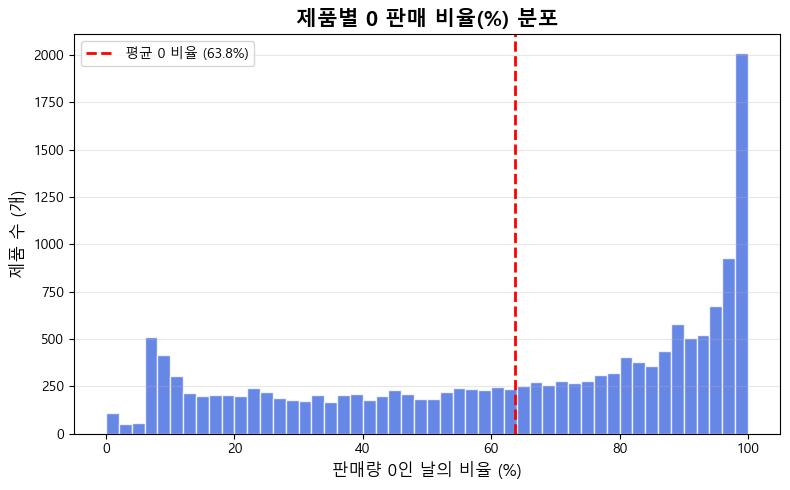

In [16]:
# ── 제품별 0 판매 비율(%) 시각화 ──────────────────────────────────────────

# 1. 각 제품별로 판매량이 0인 날의 비율(%) 계산
zero_ratio_per_product = (qty_arr == 0).mean(axis=1) * 100

# 2. 히스토그램 시각화 (도화지 세팅)
plt.figure(figsize=(8, 5))
plt.hist(zero_ratio_per_product, bins=50, color='royalblue', edgecolor='white', alpha=0.8)

# 평균선 그어주기 (전체 제품은 평균적으로 며칠이나 0일까?)
mean_zero_ratio = zero_ratio_per_product.mean()
plt.axvline(mean_zero_ratio, color='red', linestyle='dashed', linewidth=2, 
            label=f'평균 0 비율 ({mean_zero_ratio:.1f}%)')

plt.title('제품별 0 판매 비율(%) 분포', fontsize=15, fontweight='bold')
plt.xlabel('판매량 0인 날의 비율 (%)', fontsize=12)
plt.ylabel('제품 수 (개)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 2-7. 브랜드 검색량 
> 판매 예측에 도움 되나 확인

In [17]:
# ── 2-7. 검색량 기본 정보 + 시차별 상관관계 분석 ───────────────────────────────
# 핵심 질문: "검색량이 N일 뒤의 판매량을 예측하는가?"
kw_values = keyword[KW_COLS].values.flatten()
kw_values = kw_values[~np.isnan(kw_values)]

print('=' * 55)
print('📊 brand_keyword_cnt.csv 기본 정보')
print('=' * 55)
print(f"  브랜드 수        : {keyword['브랜드'].nunique():,}개")
print(f'  날짜 수          : {len(KW_COLS)}일 ({KW_COLS[0]} ~ {KW_COLS[-1]})')
print(f'  0인 셀 비율      : {(kw_values == 0).mean():.1%}')
print(f'  검색량 평균       : {kw_values[kw_values>0].mean():.1f}')
print(f'  검색량 최대       : {kw_values.max():.0f}')

# 시차별 평균 상관계수
brand_qty_wide = train.groupby('브랜드')[DATE_COLS].sum()
common_n = min(len(DATE_COLS), len(KW_COLS))
kw_wide  = keyword.set_index('브랜드')[KW_COLS[:common_n]].reindex(brand_qty_wide.index).fillna(0)

print('\n검색량과 판매량의 시차별 평균 상관계수:')
print('(해석 기준: |r| > 0.3 → 유용 / 0.1~0.3 → 보조적 / < 0.1 → 미약)')
print('-' * 50)
for lag in [0, 1, 3, 7, 14]:
    corrs = []
    for brand in brand_qty_wide.index:
        qs = brand_qty_wide.loc[brand].values[:common_n]
        ks = kw_wide.loc[brand].values
        q, k = (qs, ks) if lag == 0 else (qs[lag:], ks[:-lag])
        if k.std() > 0 and q.std() > 0:
            corrs.append(np.corrcoef(k, q)[0, 1])
    mean_r = np.mean(corrs)
    bar = '█' * int(abs(mean_r) * 100)
    print(f'  lag_{lag:2d}: {mean_r:+.4f}  {bar}')


# 브랜드별 개별 상관계수 범위 확인 (lag_0 기준)
corrs_lag0 = [np.corrcoef(kw_wide.loc[b].values, brand_qty_wide.loc[b].values[:common_n])[0,1]
              for b in brand_qty_wide.index
              if kw_wide.loc[b].std() > 0 and brand_qty_wide.loc[b].values[:common_n].std() > 0]
print(f"\n브랜드별 상관계수 범위: 최소 {min(corrs_lag0):.3f} / 최대 {max(corrs_lag0):.3f} / 평균 {np.mean(corrs_lag0):.3f}")
print(f"상관 강한 브랜드(|r|>0.3) 수: {sum(abs(r)>0.3 for r in corrs_lag0)}개 / 전체 {len(corrs_lag0)}개")

# 21.8s

📊 brand_keyword_cnt.csv 기본 정보
  브랜드 수        : 3,170개
  날짜 수          : 459일 (2022-01-01 ~ 2023-04-04)
  0인 셀 비율      : 21.7%
  검색량 평균       : 6.2
  검색량 최대       : 13383

검색량과 판매량의 시차별 평균 상관계수:
(해석 기준: |r| > 0.3 → 유용 / 0.1~0.3 → 보조적 / < 0.1 → 미약)
--------------------------------------------------
  lag_ 0: -0.0029  
  lag_ 1: +0.0140  █
  lag_ 3: +0.0204  ██
  lag_ 7: -0.0090  
  lag_14: -0.0073  

브랜드별 상관계수 범위: 최소 -0.582 / 최대 0.574 / 평균 -0.003
상관 강한 브랜드(|r|>0.3) 수: 111개 / 전체 3085개


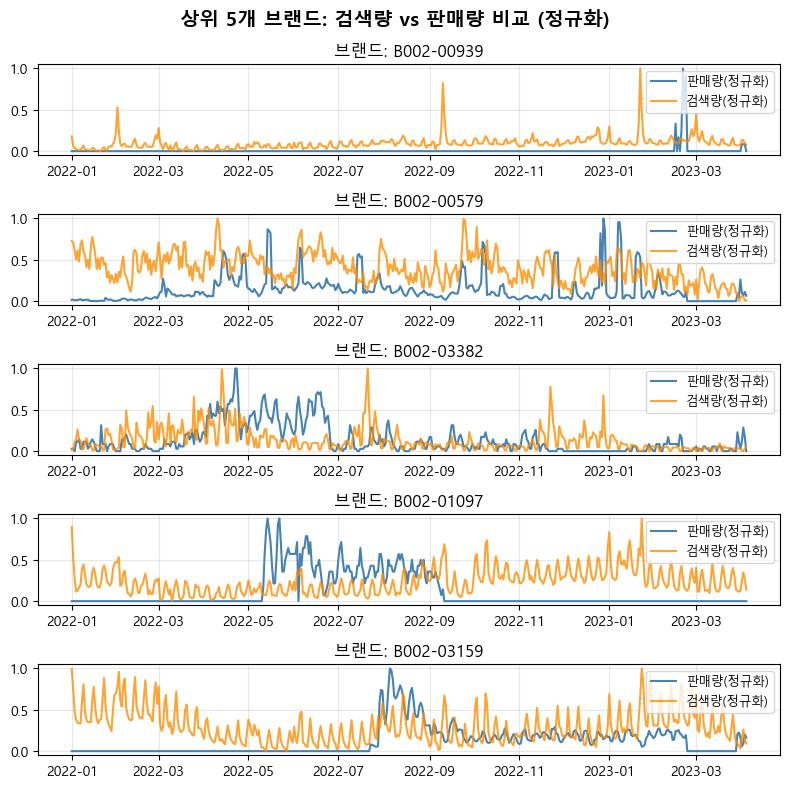

💡 CCF 분석 결과: Lag 2에서 피크 → 검색 후 약 2일 뒤 구매
💡 모델링 활용: kw_lag_1, kw_lag_3 피처 설계 근거


In [18]:
# ── 상위 5개 브랜드 검색량 vs 판매량 비교 ────────────────────────────────
brand_total_kw = keyword[KW_COLS].sum(axis=1)
top5_brands    = keyword.loc[brand_total_kw.nlargest(5).index, '브랜드'].values

def normalize(s):
    """0~1 범위로 정규화 — 스케일이 달라도 패턴을 나란히 비교할 수 있게"""
    return (s - s.min()) / (s.max() - s.min() + 1e-8)

fig, axes = plt.subplots(5, 1, figsize=(8, 8))
fig.suptitle('상위 5개 브랜드: 검색량 vs 판매량 비교 (정규화)', fontsize=14, fontweight='bold')

for i, brand in enumerate(top5_brands):
    ax = axes[i]
    kw_row    = keyword[keyword['브랜드'] == brand][KW_COLS].iloc[0]
    kw_ts     = pd.Series(kw_row.values, index=pd.to_datetime(KW_COLS))
    brand_qty = train[train['브랜드'] == brand][DATE_COLS].sum(axis=0)
    brand_qty.index = pd.to_datetime(brand_qty.index)
    ax.plot(normalize(brand_qty), color='steelblue',  lw=1.5, label='판매량(정규화)')
    ax.plot(normalize(kw_ts),    color='darkorange', lw=1.5, alpha=0.8, label='검색량(정규화)')
    ax.set_title(f'브랜드: {brand}')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



print("💡 CCF 분석 결과: Lag 2에서 피크 → 검색 후 약 2일 뒤 구매")
print("💡 모델링 활용: kw_lag_1, kw_lag_3 피처 설계 근거")

### 2-8. ACF / PACF 분석
> 주간 주기성 확인

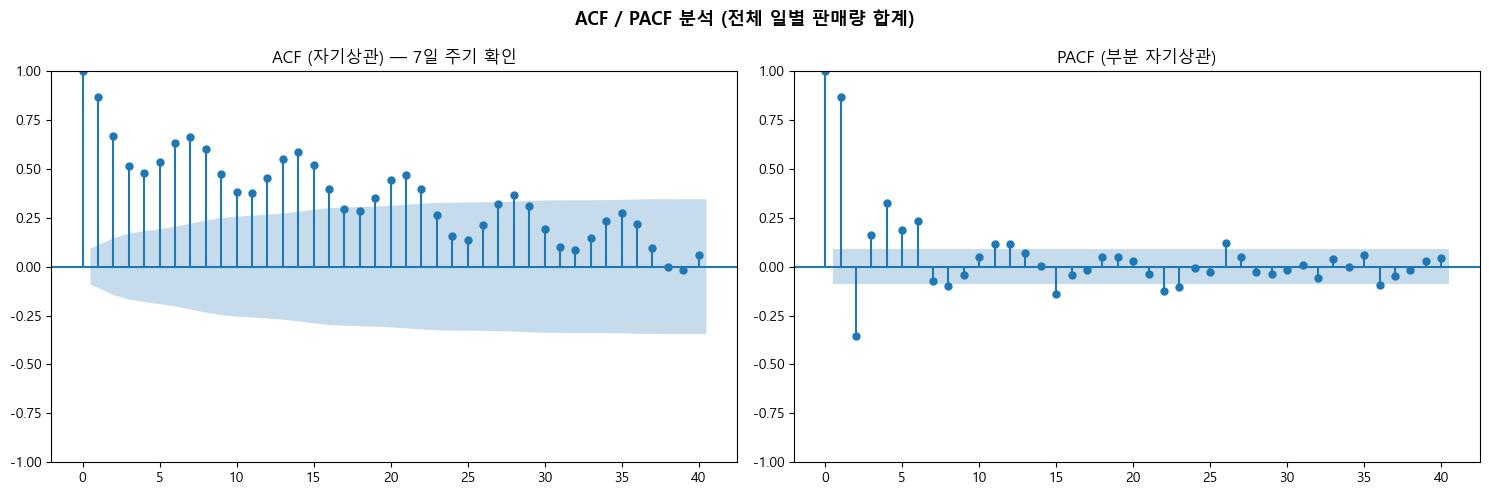

💡 모델링 활용: lag_1, lag_7, lag_14 피처 설계 근거


In [19]:
# ── 2-8. ACF / PACF 분석 ────────────────────────────────────────────────────────
# ACF : 7일, 14일, 21일 간격으로 반복 → 주간 주기 확인
# PACF: Lag 1이 가장 높고 7일 지점에서 재상승 → lag_7 피처 설계 근거
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ACF / PACF 분석 (전체 일별 판매량 합계)', fontsize=13, fontweight='bold')
plot_acf(daily_total,  lags=40, ax=axes[0], title='ACF (자기상관) — 7일 주기 확인')
plot_pacf(daily_total, lags=40, ax=axes[1], title='PACF (부분 자기상관)')
plt.tight_layout()
plt.show()
print('💡 모델링 활용: lag_1, lag_7, lag_14 피처 설계 근거')

### 2-9. 한국 공휴일 vs 판매량

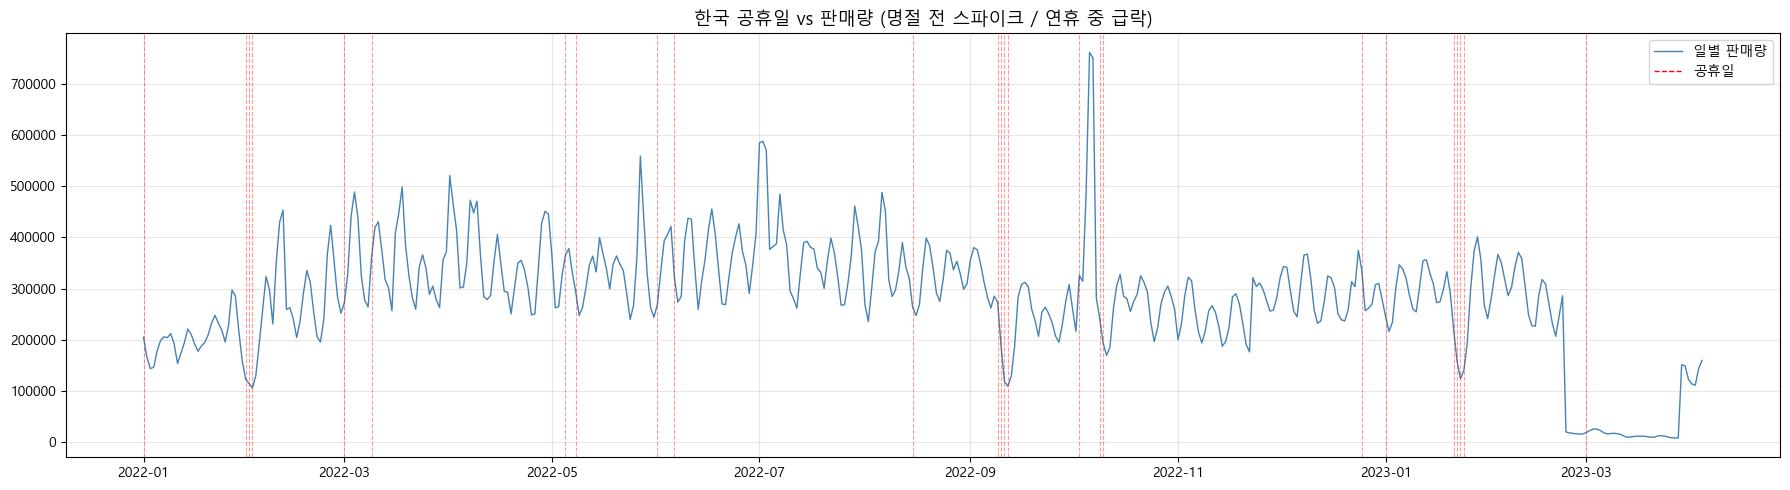

💡 공휴일 D-3 사전 구매 수요 → is_holiday, days_to_holiday 피처 설계 근거


In [20]:
# ── 2-9. 한국 공휴일 vs 판매량 시각화 ─────────────────────────────────────────
# 명절 전: 사전 구매 수요 스파이크 / 명절 중: 판매 급락
# → is_holiday, days_to_holiday 피처 설계 근거
import holidays as hol

kr_holidays   = hol.KR(years=[2022, 2023])
holiday_dates = pd.to_datetime([str(d) for d in kr_holidays.keys()])
holiday_dates = holiday_dates[
    (holiday_dates >= daily_total.index.min()) &
    (holiday_dates <= daily_total.index.max())
]

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(daily_total.index, daily_total.values, color='steelblue', lw=1, label='일별 판매량')
for h in holiday_dates:
    ax.axvline(h, color='red', alpha=0.4, linestyle='--', lw=0.8)
ax.plot([], [], color='red', linestyle='--', lw=1, label='공휴일')
ax.set_title('한국 공휴일 vs 판매량 (명절 전 스파이크 / 연휴 중 급락)', fontsize=13)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('💡 공휴일 D-3 사전 구매 수요 → is_holiday, days_to_holiday 피처 설계 근거')

### 2-10. Product Info 
> 미사용

| 항목 | 내용 |
|------|------|
| 파일 | product_info.csv |
| 매칭률 | 65.9% (5,398개 제품 정보 없음) |
| 미사용 이유 | 낮은 매칭률 + 텍스트 비정형 → 오히려 노이즈 가능성 |

> 데이터는 검토했으나 품질 문제로 제외 결정

----

### 🗺️ EDA 요약

| 발견 사항 | → | 전처리 결정 | 담당 STEP |
|----------|---|------------|----------|
| 2023-02-20 이후 급락 구간 | → | **Method 5 가설 → PSFA 실험 후 Method 4 최종 선택** | 3-0 |
| 일부 제품에서 Spike 발생 | → | 제품별 상한선 클리핑 | 3-1 |
| 구조적 0 (출시 전/단종 후) | → | first_sale_date 이전 마스킹 | 3-4 |
| 카테고리별 계절성 다름 | → | 대·중·소분류·브랜드 임베딩 | 3-5 |
| 검색량 2일 시차 효과 | → | kw_log, kw_lag_1, kw_lag_3 피처 | 3-6 |
| 63.8% 0인 Long Tail | → | log1p 변환 | 4-1 |
| 요일·월별 판매 차이 | → | day_of_week, month, quarter 피처 | 4-2 |
| 공휴일 전후 패턴 | → | is_holiday, days_to_holiday 피처 | 4-3 |
| ACF: Lag 1·7 유의미 | → | lag_1, lag_7 피처 | 4-4 |
| 일별 트렌드 변동 | → | rolling_7_mean, rolling_30_mean 피처 | 4-5 |
| product_info.csv | → | 매칭률 65.9% → 미사용 결정 | — |



---
## STEP 3 — 데이터 전처리

### 3-0. 급락 구간 처리 
> 2023-02-20 이후 판매량이 정상 대비 ~16% 수준으로 급락하는 구간  
> 5가지 방법 비교 후 Method 4 최종 선택  


📌  
1단계: Method 5 (원본+플래그) → 등락이 심할때는 이유가 있다는 가정(실제 데이터라면 이유가 있음. 재고 부족 등) + 데이터 손실도 가장 적다는 논리로 1차 선택  
2단계: DACON 제출 → 에폭이 늘수록 PSFA 점수 폭락 현상 발견  
3단계: 원인 분석 → is_post_crash 플래그가 노이즈 과학습 유발  
4단계: Method 4로 피벗 → PSFA 0.4336 달성 (1위)  



| Outlier Method | 전략 | 장점 | 단점 | 
|--------|------|------|------|
| 1 | 급락 구간 삭제 | 오염 데이터 확실 제거 | 데이터 10% 손실 |  
| 2 | 전년 동기 × 성장률 | 가장 "진짜 같은" 합성 | 성장률 폭발 위험, 강한 가정 | 
| 3 | 이동평균 7일 + 요일보정 | 최근 흐름 반영 | 7일은 샘플 적어 노이즈 민감 |
| **4** | **이동평균 30일 + 요일보정** | **PSFA 기준 최고 성능** | **"직전 30일이 대표적" 가정** |
| 5 | 원본 유지 + 플래그 | 가정 없음 | **에폭 증가 시 플래그에 과적합 → PSFA 폭락** | 

In [21]:
# ── 3-0. 급락 구간 수치 확인 ───────────────────────────────────────────────────
# ⚠️ CRASH_START, CRASH_END, daily_total : EDA 2-3에서 정의됨

crash_mask = (daily_total.index >= CRASH_START) & (daily_total.index <= CRASH_END)
normal_avg = daily_total[daily_total.index < CRASH_START].mean()
crash_avg  = daily_total[crash_mask].mean()

print('=' * 55)
print('📊 급락 구간 분석')
print('=' * 55)
print(f'  정상 구간 일평균  : {normal_avg:>10,.0f}')
print(f'  급락 구간 일평균  : {crash_avg:>10,.0f}')
print(f'  급락 비율         : {crash_avg/normal_avg:.1%}')
print(f'  급락 기간         : {CRASH_START.date()} ~ {CRASH_END.date()} ({crash_mask.sum()}일)')

📊 급락 구간 분석
  정상 구간 일평균  :    305,103
  급락 구간 일평균  :     49,274
  급락 비율         : 16.2%
  급락 기간         : 2023-02-20 ~ 2023-04-04 (44일)


In [22]:
# ── 5가지 방법 함수 정의 ───────────────────────────────────────────────────
# 🔧 함수 선언 — `apply_method1` ~ `apply_method5`

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Method 1: 급락 기간 날짜를 통째로 삭제
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def apply_method1(train_df, date_cols, crash_start, crash_end):
    """급락 기간 날짜 컬럼을 학습에서 제외 — 가장 단순하지만 데이터 손실"""
    # 급락 구간에 해당하는 날짜 컬럼 목록
    crash_cols    = [c for c in date_cols if crash_start <= pd.Timestamp(c) <= crash_end]
    # 해당 컬럼을 drop해서 학습 데이터에서 제외
    train_out     = train_df.drop(columns=crash_cols)
    date_cols_out = [c for c in date_cols if c not in crash_cols]
    print(f'[Method 1] 제외 날짜: {len(crash_cols)}일 → 잔여 학습일: {len(date_cols_out)}일')
    return train_out, date_cols_out


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Method 2: 전년 동기 실제값 × 성장률로 복원
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def apply_method2(train_df, date_cols, crash_start, crash_end):
    """전년 동기 실제값 × 성장률로 합성 데이터 복원 (성장률 cap 적용)"""
    train_out   = train_df.copy()
    date_index  = pd.to_datetime(date_cols)
    crash_mask  = (date_index >= crash_start) & (date_index <= crash_end)
    crash_cols  = [c for c, m in zip(date_cols, crash_mask) if m]

    # ── 1단계: 급락 직전 30일 & 전년 같은 30일 컬럼 찾기 ──────────────
    pre_start = crash_start - pd.Timedelta(days=30)
    pre_end   = crash_start - pd.Timedelta(days=1)
    pre_cols  = [c for c in date_cols
                 if pre_start <= pd.Timestamp(c) <= pre_end]

    # 전년 동기 30일 (학습 데이터에 존재하는 날짜만)
    prev_year_pre_cols = [
        str((pd.Timestamp(c) - pd.DateOffset(years=1)).date())
        for c in pre_cols
    ]
    prev_year_pre_cols = [c for c in prev_year_pre_cols if c in date_cols]

    # ── 2단계: 제품별 성장률 계산 ──────────────────────────────────────
    if len(pre_cols) > 0 and len(prev_year_pre_cols) > 0:
        recent_avg = train_df[pre_cols].mean(axis=1)            # 올해 직전 30일 제품별 평균
        prev_avg   = train_df[prev_year_pre_cols].mean(axis=1)  # 작년 같은 기간 제품별 평균
        # 작년 평균이 0이면 성장률 1.0(변화 없음)으로 처리
        growth_rate_raw = np.where(prev_avg > 0, recent_avg / prev_avg, 1.0)
    else:
        growth_rate_raw = np.ones(len(train_df))

    # ── 3단계: 성장률 cap 적용 (5~95 백분위수) ─────────────────────────
    #   cap 필요성 : 작년에 거의 안 팔리다가 올해 팔리기 시작한 제품은 성률이 50배, 100배로 폭발 → 합성값이 비현실적으로 커짐
    #   95% 백분위수로 cap을 걸면 정상적인 95%의 제품은 그대로 두고 극단적인 5%만 제한하는 효과
    valid_rates = growth_rate_raw[growth_rate_raw > 0]
    cap_lower   = np.percentile(valid_rates, 5)
    cap_upper   = np.percentile(valid_rates, 95)
    growth_rate = np.clip(growth_rate_raw, cap_lower, cap_upper)

    # 성장률 분포 출력 (디버깅 & 의사결정용)
    print(f'[Method 2] 성장률 분포 (cap 적용 전):')
    print(f'  중앙값: {np.median(valid_rates):.2f}  |  '
          f'25%: {np.percentile(valid_rates, 25):.2f}  |  '
          f'75%: {np.percentile(valid_rates, 75):.2f}  |  '
          f'95%: {cap_upper:.2f}  |  '
          f'최대: {valid_rates.max():.1f}')
    print(f'  → cap 범위: {cap_lower:.2f} ~ {cap_upper:.2f}')

    # ── 4단계: 급락 구간 각 날짜를 전년 동기 실제값 × 성장률로 대체 ──
    replaced = 0
    for col in crash_cols:
        prev_year_col = str((pd.Timestamp(col) - pd.DateOffset(years=1)).date())
        if prev_year_col in date_cols:
            train_out[col] = (train_df[prev_year_col] * growth_rate).round().clip(lower=0)
            replaced += 1
        else:
            # 전년 데이터 없으면 급락 직전 30일 평균으로 폴백
            train_out[col] = train_df[pre_cols].mean(axis=1).round().clip(lower=0)

    print(f'[Method 2] 전년 동기 복원 완료: {replaced}/{len(crash_cols)}일')
    return train_out, date_cols


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Method 3 & 4 공통 로직: 이동평균 + 요일별 보정
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Method 3(7일)과 Method 4(30일)는 window 크기만 다르고 로직이 동일하므로
# 공통 함수 _apply_ma_dow()를 만들고, 각 method에서 호출

def _apply_ma_dow(train_df, date_cols, crash_start, crash_end, window_days, method_name):
    """이동평균 + 요일별 보정 공통 로직
    
    채우기 방식 (B): 직전 N일의 요일별 평균으로 대체
    - 예) 7일 window → 직전 월~일 각 요일의 평균을 구해서
          급락 구간의 월요일엔 월요일 평균, 금요일엔 금요일 평균을 넣음
    - EDA 2-4에서 확인한 요일 패턴(목·금 높음, 월·화 낮음)이 보존됨
    """
    train_out   = train_df.copy()
    date_index  = pd.to_datetime(date_cols)
    crash_mask  = (date_index >= crash_start) & (date_index <= crash_end)
    crash_cols  = [c for c, m in zip(date_cols, crash_mask) if m]

    # ── 급락 직전 N일 컬럼 찾기 ────────────────────────────────────────
    pre_start = crash_start - pd.Timedelta(days=window_days)
    pre_end   = crash_start - pd.Timedelta(days=1)
    pre_cols  = [c for c in date_cols
                 if pre_start <= pd.Timestamp(c) <= pre_end]

    # ── 요일별 그룹핑 (직전 N일 내에서 같은 요일끼리 묶기) ─────────────
    # 0=월, 1=화, ..., 6=일
    dow_groups = {d: [] for d in range(7)}
    for c in pre_cols:
        dow = pd.Timestamp(c).dayofweek
        dow_groups[dow].append(c)

    # ── 요일별 제품별 평균값 계산 ──────────────────────────────────────
    dow_means = {}
    for dow, cols_list in dow_groups.items():
        if len(cols_list) > 0:
            # 해당 요일에 해당하는 날짜들의 제품별 평균
            dow_means[dow] = train_df[cols_list].mean(axis=1)
        else:
            # window 안에 해당 요일이 없으면 전체 평균으로 폴백
            # (7일 window에서는 모든 요일이 1개씩 있으므로 거의 발생 안 함)
            dow_means[dow] = train_df[pre_cols].mean(axis=1) if len(pre_cols) > 0 else 0

    # ── 급락 구간의 각 날짜를 해당 요일 평균으로 대체 ──────────────────
    for col in crash_cols:
        dow = pd.Timestamp(col).dayofweek
        train_out[col] = dow_means[dow].round().clip(lower=0)

    print(f'[{method_name}] 이동평균 {window_days}일 + 요일 보정 완료: {len(crash_cols)}일')
    return train_out, date_cols


def apply_method3(train_df, date_cols, crash_start, crash_end):
    """이동평균 7일 + 요일별 보정으로 급락 구간 값 교체"""
    return _apply_ma_dow(train_df, date_cols, crash_start, crash_end,
                         window_days=7, method_name='Method 3')


def apply_method4(train_df, date_cols, crash_start, crash_end):
    """이동평균 30일 + 요일별 보정으로 급락 구간 값 교체"""
    return _apply_ma_dow(train_df, date_cols, crash_start, crash_end,
                         window_days=30, method_name='Method 4')


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Method 5: 원본 유지 + 플래그
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def apply_method5(train_df, date_cols, crash_start, crash_end):
    """원본 유지 + is_post_crash 플래그 생성 — 모델이 급락 패턴을 직접 학습"""
    # 각 날짜가 급락 시작일 이후인지 0/1로 표시
    crash_flag = {c: int(pd.Timestamp(c) >= crash_start) for c in date_cols}
    n_crash    = sum(crash_flag.values())
    print(f'[Method 5] 원본 유지, is_post_crash 플래그 생성 (급락 후: {n_crash}일)')
    return train_df.copy(), date_cols, crash_flag

In [23]:
# ── 급락 구간 분석 ─────────────────────────────────────────────────────────
# ⚙️  방법 선택 (1~5 중 하나) — 비교 시각화를 본 뒤 변경하기 / 숫자만 바꾸면 자동으로 코드 돌아가게 설정함

OUTLIER_METHOD = 4   # ← Method 4 최종 선택 (PSFA 기준 최적, Method 5 피벗 후 확정)

# ── 선택한 방법 실제 적용 ─────────────────────────────────────────────────
if OUTLIER_METHOD == 1:
    train_m, DATE_COLS_M = apply_method1(train, DATE_COLS, CRASH_START, CRASH_END)
    crash_flag_dict = {}
elif OUTLIER_METHOD == 2:
    train_m, DATE_COLS_M = apply_method2(train, DATE_COLS, CRASH_START, CRASH_END)
    crash_flag_dict = {}
elif OUTLIER_METHOD == 3:
    train_m, DATE_COLS_M = apply_method3(train, DATE_COLS, CRASH_START, CRASH_END)
    crash_flag_dict = {}
elif OUTLIER_METHOD == 4:
    train_m, DATE_COLS_M = apply_method4(train, DATE_COLS, CRASH_START, CRASH_END)
    crash_flag_dict = {}
else:  # Method 5
    train_m, DATE_COLS_M, crash_flag_dict = apply_method5(train, DATE_COLS, CRASH_START, CRASH_END)

print(f'\n✅ Method {OUTLIER_METHOD} 적용 완료  /  학습 날짜 수: {len(DATE_COLS_M)}일')

[Method 4] 이동평균 30일 + 요일 보정 완료: 44일

✅ Method 4 적용 완료  /  학습 날짜 수: 459일


### 3-1. Spike 클리핑 
> 개별 제품 이상치 제거

In [24]:
# ── 3-1. Spike 클리핑 (벡터 연산 버전) ─────────────────────────────────────────
# 제품별 극단값을 상한선으로 깎아서, 이벤트 신호는 살리되 극단값이 loss를 지배하는 것만 방지
# 기존: for 루프로 15,890개 제품을 하나씩 처리 (느림)
# 개선: pandas 벡터 연산으로 한 번에 처리 (빠름)

CLIP_FACTOR = 40   # ← 위 검증 결과를 보고 필요시 변경

# 복사본을 만들기
train_clean = train_m.copy()
qty_data = train_clean[DATE_COLS_M].astype(float)

# ── 제품별 상한선 계산 ────────────────────────────────────────────────────
# 중앙값 > 0인 제품: 상한선 = 중앙값 × CLIP_FACTOR
# 중앙값 = 0인 제품: 상한선 = 95% 분위수 (거의 안 팔리는 제품용)
# 95% 분위수도 0인 제품: 상한선 = inf (클리핑 안 함, 어차피 거의 0)

medians = qty_data.median(axis=1)
q95     = qty_data.quantile(0.95, axis=1)

upper_limit = np.where(
    medians > 0,
    medians * CLIP_FACTOR,          # 일반 제품: 중앙값 × 20
    np.where(q95 > 0, q95, np.inf)  # 중앙값=0인 제품: 95분위 or 스킵
)

# ── 클리핑 적용 (벡터 연산) ───────────────────────────────────────────────
# 각 제품(행)마다 해당 상한선으로 clip
# .clip()에 axis=0으로 행별 상한선을 적용
before_max = qty_data.max(axis=1)
clipped    = qty_data.clip(upper=pd.Series(upper_limit, index=qty_data.index), axis=0)

# 클리핑 결과를 train_clean에 반영
train_clean = train_m.copy()
train_clean[DATE_COLS_M] = clipped

# ── 결과 요약 ─────────────────────────────────────────────────────────────
after_max     = clipped.max(axis=1)
clipped_count = (before_max > after_max).sum()

print('=' * 55)
print('📊 Spike 클리핑 결과')
print('=' * 55)
print(f'  CLIP_FACTOR       : {CLIP_FACTOR}배')
print(f'  클리핑된 제품 수  : {clipped_count:,}개')
print(f'  클리핑 전 최대값  : {before_max.max():,.0f}')
print(f'  클리핑 후 최대값  : {after_max.max():,.0f}')
print(f'  압축 비율         : {before_max.max() / max(after_max.max(), 1):,.1f}배 축소')
print()
print('✅ 원본: train_m  /  클린버전: train_clean')

📊 Spike 클리핑 결과
  CLIP_FACTOR       : 40배
  클리핑된 제품 수  : 7,584개
  클리핑 전 최대값  : 200,420
  클리핑 후 최대값  : 38,384
  압축 비율         : 5.2배 축소

✅ 원본: train_m  /  클린버전: train_clean


### 3-2. 단가(Price) 파생 
> 매출액(revenue) / 판매량(qty)  
> qty=0인 날은 단가를 계산할 수 없으므로 NaN 처리 후 ffill로 채움 

In [25]:
# ── 3-2. 단가 파생 ─────────────────────────────────────────────────────────────

price_df = sales[META_COLS].copy()

# ── 1단계: qty > 0인 날만 단가 계산, 나머지는 NaN ─────────────────────
for col in DATE_COLS_M:
    price_df[col] = np.where(
        train_clean[col] > 0,
        sales[col] / train_clean[col],   # 실제 단가
        np.nan                            # 안 팔린 날은 NaN
    )

# ── 2단계: ffill — 직전 판매일의 단가를 이어받음 ──────────────────────
# 중앙값 대신 ffill을 쓰는 이유:
#   - 중앙값: 과거 세일가 + 현재 정상가의 평균 → 실제 시점 가격과 동떨어짐
#   - ffill: 직전 가격 유지 → 시계열 흐름이 자연스럽고 LSTM에 노이즈 없음 / 제품이 오늘 안 팔려도 가격표는 어제와 같음
price_df[DATE_COLS_M] = price_df[DATE_COLS_M].ffill(axis=1)

# ── 3단계: 안전장치 — ffill로도 안 채워지는 NaN은 제품별 중앙값 ──────
# 첫 판매 전 구간이 여기 해당하지만, 3-4 구조적 0 마스킹에서 빠지므로 실질 영향 없음
price_median = price_df[DATE_COLS_M].median(axis=1)
for col in DATE_COLS_M:
    price_df[col] = price_df[col].fillna(price_median)

# ── 결과 확인 ─────────────────────────────────────────────────────────────
nan_pct = price_df[DATE_COLS_M].isna().mean().mean()
print(f'NaN 비율 (최종): {nan_pct:.4%}')
print(f'단가 범위: {price_df[DATE_COLS_M].min().min():.0f} ~ {price_df[DATE_COLS_M].max().max():,.0f}')
print('✅ price_df 생성 완료 (ffill + 중앙값 폴백)')

NaN 비율 (최종): 1.8628%
단가 범위: 0 ~ 34,825,000
✅ price_df 생성 완료 (ffill + 중앙값 폴백)


In [26]:
# ── 단가 이상치 확인 ──────────────────────────────────────────────────────
price_vals = price_df[DATE_COLS_M].values.flatten()
price_vals = price_vals[~np.isnan(price_vals)]
price_vals = price_vals[price_vals > 0]

print('=' * 55)
print('📊 단가 분포 확인')
print('=' * 55)
print(f'  중앙값        : {np.median(price_vals):,.0f}원')
print(f'  평균          : {np.mean(price_vals):,.0f}원')
print(f'  75%           : {np.percentile(price_vals, 75):,.0f}원')
print(f'  90%           : {np.percentile(price_vals, 90):,.0f}원')
print(f'  95%           : {np.percentile(price_vals, 95):,.0f}원')
print(f'  99%           : {np.percentile(price_vals, 99):,.0f}원')
print(f'  최대          : {np.max(price_vals):,.0f}원')
print()

# 상위 극단값 제품 확인
print('📌 단가 상위 10개 (어떤 제품이 이상한지)')
price_max_per_product = price_df[DATE_COLS_M].max(axis=1)
top10 = price_max_per_product.nlargest(10)
for idx in top10.index:
    pid = price_df.loc[idx, 'ID']
    cat = price_df.loc[idx, '대분류']
    max_price = top10[idx]
    # 해당 제품의 qty와 revenue도 확인
    qty_vals = train_clean.loc[idx, DATE_COLS_M]
    rev_vals = sales.loc[idx, DATE_COLS_M]
    print(f'  {pid} [{cat}] 최대단가: {max_price:>15,.0f}원'
          f'  | qty범위: {qty_vals.min():.0f}~{qty_vals.max():.0f}'
          f'  | rev범위: {rev_vals.min():.0f}~{rev_vals.max():,.0f}')

# NaN 잔여 확인
nan_products = price_df[DATE_COLS_M].isna().all(axis=1).sum()
print(f'\n📌 전 기간 NaN인 제품 수: {nan_products}개 (= 한 번도 안 팔린 제품, 3-4에서 마스킹 예정)')

📊 단가 분포 확인
  중앙값        : 9,800원
  평균          : 18,988원
  75%           : 20,000원
  90%           : 37,900원
  95%           : 56,990원
  99%           : 158,000원
  최대          : 34,825,000원

📌 단가 상위 10개 (어떤 제품이 이상한지)
  11366 [B002-C001-0002] 최대단가:      34,825,000원  | qty범위: 0~1  | rev범위: 0~34,825,000
  11251 [B002-C001-0001] 최대단가:      17,967,970원  | qty범위: 0~1  | rev범위: 0~21,434,950
  11364 [B002-C001-0001] 최대단가:      15,911,000원  | qty범위: 0~0  | rev범위: 0~3,182,200
  13605 [B002-C001-0002] 최대단가:       9,996,000원  | qty범위: 0~0  | rev범위: 0~999,600
  1420 [B002-C001-0001] 최대단가:       7,899,050원  | qty범위: 0~2  | rev범위: 0~15,798,100
  14639 [B002-C001-0001] 최대단가:       6,192,750원  | qty범위: 0~4  | rev범위: 0~24,771,000
  3777 [B002-C001-0001] 최대단가:       5,519,400원  | qty범위: 0~1  | rev범위: 0~5,519,400
  13530 [B002-C001-0002] 최대단가:       5,088,750원  | qty범위: 0~3  | rev범위: 0~15,266,250
  11301 [B002-C001-0002] 최대단가:       4,980,000원  | qty범위: 0~0  | rev범위: 0~498,000
  7899 [B002-C001-0002] 최대단가

In [27]:
# ── 단가 클리핑 — 99% 백분위수 상한선 ─────────────────────────────────────

price_cap = price_df[DATE_COLS_M].quantile(0.99).median()
# ↑ 날짜별 99% 백분위수의 중앙값 → 안정적인 단일 cap 값

price_before_max = price_df[DATE_COLS_M].max().max()
price_df[DATE_COLS_M] = price_df[DATE_COLS_M].clip(upper=price_cap)
price_after_max = price_df[DATE_COLS_M].max().max()

print(f'단가 클리핑 완료:')
print(f'  cap 기준 (99%)    : {price_cap:,.0f}원')
print(f'  클리핑 전 최대값  : {price_before_max:,.0f}원')
print(f'  클리핑 후 최대값  : {price_after_max:,.0f}원')
print(f'  NaN 비율 (최종)   : {price_df[DATE_COLS_M].isna().mean().mean():.4%}')
print('✅ price_df 단가 클리핑 완료')

단가 클리핑 완료:
  cap 기준 (99%)    : 152,781원
  클리핑 전 최대값  : 34,825,000원
  클리핑 후 최대값  : 152,781원
  NaN 비율 (최종)   : 1.8628%
✅ price_df 단가 클리핑 완료


### 3-2B. 회복기 피처 생성 

> **회복기(2023-03-29 ~ 04-04)**: 급락 직후, 예측 기간 직전의 7일간 데이터  
> LGBM 핵심피처로 사용  

In [28]:
# ── 3-2B. 회복기(3/29~4/04) 전용 피처 생성 ──────────────────────────────

# ── 회복기 날짜 컬럼 추출 ────────────────────────────────────────────────
recovery_dates = pd.date_range('2023-03-29', '2023-04-04')
recovery_cols  = [d.strftime('%Y-%m-%d') for d in recovery_dates
                  if d.strftime('%Y-%m-%d') in DATE_COLS_M]

# 2월 날짜 컬럼 (회복 속도 비교용)
feb_cols = [c for c in DATE_COLS_M
            if c.startswith('2023-02')]

print(f'회복기 컬럼: {len(recovery_cols)}개  ({recovery_cols[0]} ~ {recovery_cols[-1]})')
print(f'2월 컬럼   : {len(feb_cols)}개')

# ── 제품별 회복기 통계 ───────────────────────────────────────────────────
recovery_data = train_clean[recovery_cols].astype(float)
feb_data      = train_clean[feb_cols].astype(float)

train_clean['recovery_mean']   = recovery_data.mean(axis=1)
train_clean['recovery_median'] = recovery_data.median(axis=1)

# 회복 추세: 회복기 평균 / 2월 평균  (>1이면 2월보다 회복됨)
feb_mean = feb_data.mean(axis=1)
train_clean['recovery_trend'] = train_clean['recovery_mean'] / (feb_mean + 1e-6)
train_clean['recovery_trend'] = train_clean['recovery_trend'].clip(0, 10)

# ── 별도 DataFrame으로 저장 (Wide→Long 후 merge용) ───────────────────────
recovery_feats = train_clean[['ID', 'recovery_mean', 'recovery_median', 'recovery_trend']].copy()

print()
print('=' * 55)
print('📊 회복기 피처 생성 완료')
print('=' * 55)
print(f'  recovery_mean   : {train_clean["recovery_mean"].describe().round(2).to_dict()}')
print(f'  recovery_median : 0이 아닌 제품 {(train_clean["recovery_median"] > 0).sum():,}개')
print(f'  recovery_trend  : 중앙값 {train_clean["recovery_trend"].median():.3f}')
print()
print('💡 recovery_feats DataFrame 저장됨 → 3-3 이후 df에 merge 예정')


회복기 컬럼: 7개  (2023-03-29 ~ 2023-04-04)
2월 컬럼   : 28개

📊 회복기 피처 생성 완료
  recovery_mean   : {'count': 15890.0, 'mean': 17.63, 'std': 148.17, 'min': 0.0, '25%': 0.0, '50%': 0.43, '75%': 5.43, 'max': 7285.71}
  recovery_median : 0이 아닌 제품 7,615개
  recovery_trend  : 중앙값 0.770

💡 recovery_feats DataFrame 저장됨 → 3-3 이후 df에 merge 예정


### 3-3. Wide → Long 변환

In [70]:
price_long

,ID,제품,대분류,중분류,소분류,브랜드,date,price
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-01,3400.0
1,1,B002-00002-00001,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,2022-01-01,22400.0
2,2,B002-00002-00002,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,2022-01-01,12900.0
3,3,B002-00002-00003,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,2022-01-01,4000.0
4,4,B002-00003-00001,B002-C001-0001,B002-C002-0001,B002-C003-0003,B002-00003,2022-01-01,5250.0
...,...,...,...,...,...,...,...,...
7293505,15885,B002-03799-00002,B002-C001-0003,B002-C002-0008,B002-C003-0042,B002-03799,2023-04-04,0.0
7293506,15886,B002-03799-00003,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-03799,2023-04-04,6069.0
7293507,15887,B002-03799-00004,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-03799,2023-04-04,13700.0
7293508,15888,B002-03799-00005,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-03799,2023-04-04,27300.0


In [29]:
# ── 3-3. Wide → Long 변환 ───────────────────────────────────────────────────────
print('Wide → Long 변환 중... (약 30초~1분 소요)')

df = pd.melt(
    train_clean,
    id_vars    = META_COLS,
    value_vars = DATE_COLS_M,
    var_name   = 'date',
    value_name = 'qty'
)

price_long = pd.melt(
    price_df,
    id_vars    = META_COLS,
    value_vars = DATE_COLS_M,
    var_name   = 'date',
    value_name = 'price'
)

df['date']         = pd.to_datetime(df['date'])
price_long['date'] = pd.to_datetime(price_long['date'])

# qty + price 병합
df = df.merge(price_long[['ID', 'date', 'price']], on=['ID', 'date'], how='left')
df = df.sort_values(['ID', 'date']).reset_index(drop=True)

# Method 5일 때 is_post_crash 플래그 병합
if OUTLIER_METHOD == 5 and crash_flag_dict:
    flag_df = pd.DataFrame([
        {'date': pd.Timestamp(c), 'is_post_crash': v}
        for c, v in crash_flag_dict.items()
    ])
    df = df.merge(flag_df, on='date', how='left')
    df['is_post_crash'] = df['is_post_crash'].fillna(0).astype(int)
    print(f'  is_post_crash 플래그 추가 (급락후=1): {df["is_post_crash"].sum():,}행')
else:
    df['is_post_crash'] = 0

print(f'변환 완료: {train_clean.shape} → {df.shape}')

# ── 🌟수정: 회복기 피처 merge (3-2B에서 생성) ──────────────────────────
df = df.merge(recovery_feats, on='ID', how='left')
print(f'  + recovery_feats merge 완료 (recovery_mean, recovery_median, recovery_trend)')


Wide → Long 변환 중... (약 30초~1분 소요)
변환 완료: (15890, 470) → (7293510, 10)
  + recovery_feats merge 완료 (recovery_mean, recovery_median, recovery_trend)


### 3-4. 구조적 0 마스킹

In [30]:
# ── 3-4. 구조적 0 마스킹 ────────────────────────────────────────────────────────

df = df.merge(
    train[['ID', 'first_sale_date', 'last_sale_date']],
    on='ID', how='left'
)

DISC_BUFFER = 90  # 마지막 판매일 이후 90일까지는 "진짜 0"으로 취급, 이후는 구조적 0

df['is_structural_zero'] = (
    (df['date'] < df['first_sale_date']) |
    (df['date'] > df['last_sale_date'] + pd.Timedelta(days=DISC_BUFFER))
)

print('=' * 55)
print('📊 구조적 0 마스킹 결과')
print('=' * 55)
print(f'  전체 행 수                : {len(df):>10,}')
print(f'  구조적 0 마스킹 행 수     : {df["is_structural_zero"].sum():>10,}')
useful_rows = ~df['is_structural_zero']
print(f'  학습 활용 가능 행         : {useful_rows.sum():>10,}')
print(f'  전체 대비 비율            : {useful_rows.mean():.1%}')
print()
print(f'  한 번도 안 팔린 제품 수   : {(~has_sales).sum():,}개')
print('  → 이 제품들은 first_sale_date = NaT → 전체 기간이 구조적 0으로 마스킹됨')

📊 구조적 0 마스킹 결과
  전체 행 수                :  7,293,510
  구조적 0 마스킹 행 수     :  2,216,596
  학습 활용 가능 행         :  5,076,914
  전체 대비 비율            : 69.6%

  한 번도 안 팔린 제품 수   : 85개
  → 이 제품들은 first_sale_date = NaT → 전체 기간이 구조적 0으로 마스킹됨


### 3-5. 카테고리 인코딩 
> 텍스트 → 숫자

🔧 함수/객체 선언 — `LabelEncoder` (le_dict) 
> 나중에 역변환 때 사용

In [31]:
from sklearn.preprocessing import LabelEncoder

# ── LabelEncoder 카테고리 인코딩 ──────────────────────────────────────────

le_dict = {}

for col in ['대분류', '중분류', '소분류', '브랜드']:
    le = LabelEncoder()
    df[f'{col}_enc'] = le.fit_transform(df[col].astype(str))
    le_dict[col]     = le
    print(f'  {col:5s}: {len(le.classes_):>5,}개 클래스 → 0~{len(le.classes_)-1}')

le_product = LabelEncoder()
df['product_enc'] = le_product.fit_transform(df['ID'].astype(str))
le_dict['product'] = le_product
print(f"  {'제품':5s}: {len(le_product.classes_):>5,}개 클래스 인코딩")
print('\n✅ le_dict에 각 LabelEncoder 저장 완료 (예측 시 역변환에 사용)')

  대분류  :     5개 클래스 → 0~4
  중분류  :    11개 클래스 → 0~10
  소분류  :    53개 클래스 → 0~52
  브랜드  : 3,170개 클래스 → 0~3169
  제품   : 15,890개 클래스 인코딩

✅ le_dict에 각 LabelEncoder 저장 완료 (예측 시 역변환에 사용)


### 3-6. 브랜드 검색량 병합 
> kw_log / kw_lag_1 / kw_lag_3

| 변수명 | 계산 방법 | 의미 |
|--------|----------|------|
| `kw_log` | log1p(kw_cnt) | 당일 검색량 (log 변환) |
| `kw_lag_1` | kw_log를 1일 shift | 하루 전 검색량 |
| `kw_lag_3` | kw_log를 3일 shift | 3일 전 검색량 |

In [32]:
# ── 3-6. 검색량 처리 및 병합 ────────────────────────────────────────────────────
# 흐름: kw_cnt → 99% cap 클리핑 → log1p → kw_log → shift → lag 피처

# 1. Wide → Long 변환
kw_long = pd.melt(
    keyword,
    id_vars    = ['브랜드'],
    value_vars = KW_COLS,
    var_name   = 'date',
    value_name = 'kw_cnt'
)
kw_long['date']   = pd.to_datetime(kw_long['date'])
kw_long['kw_cnt'] = kw_long['kw_cnt'].fillna(0)

# 2. 브랜드별 99% cap 클리핑 → 극단 이상치 제거
cap_by_brand = kw_long.groupby('브랜드')['kw_cnt'].quantile(0.99)
kw_long = kw_long.join(cap_by_brand.rename('cap'), on='브랜드')
kw_long['kw_cnt'] = kw_long[['kw_cnt', 'cap']].min(axis=1)
kw_long.drop(columns=['cap'], inplace=True)

# 3. log1p 변환
kw_long['kw_log'] = np.log1p(kw_long['kw_cnt'])

# 4. 브랜드 내 시간순 정렬 후 shift → lag 피처
# lag_2 제외: lag_1과 정보 중복이 크고 lag_3로 충분히 커버
kw_long = kw_long.sort_values(['브랜드', 'date']).reset_index(drop=True)
kw_long['kw_lag_1'] = kw_long.groupby('브랜드')['kw_log'].shift(1).fillna(0)
kw_long['kw_lag_3'] = kw_long.groupby('브랜드')['kw_log'].shift(3).fillna(0)

# 5. df에 병합
df = df.merge(
    kw_long[['브랜드', 'date', 'kw_log', 'kw_lag_1', 'kw_lag_3']],
    on=['브랜드', 'date'], how='left'
)
df[['kw_log', 'kw_lag_1', 'kw_lag_3']] = df[['kw_log', 'kw_lag_1', 'kw_lag_3']].fillna(0)

print(f'kw_log    NaN: {df["kw_log"].isna().sum()}')
print(f'kw_lag_1  NaN: {df["kw_lag_1"].isna().sum()}')
print(f'kw_lag_3  NaN: {df["kw_lag_3"].isna().sum()}')
print(f'kw_log > 0 비율: {(df["kw_log"] > 0).mean():.1%}')
print('\n✅ 검색량 피처 3개 추가 완료: kw_log, kw_lag_1, kw_lag_3')

kw_log    NaN: 0
kw_lag_1  NaN: 0
kw_lag_3  NaN: 0
kw_log > 0 비율: 77.3%

✅ 검색량 피처 3개 추가 완료: kw_log, kw_lag_1, kw_lag_3


---
## STEP 4 — 특성공학 (Feature Engineering)

### 4-1. log1p 변환
> qty → qty_log

In [33]:
# ── 4-1. log1p 변환 ───────────────────────────────────────────────────────
# qty(판매량)를 log1p 변환해서 qty_log 컬럼을 생성 / 원본 qty는 유지 (디버깅, 역변환 시 필요).
#
# log1p(x) = log(x + 1)
#   - +1을 하는 이유: qty=0일 때 log(0) = -inf가 되는 걸 방지
#   - 역변환: expm1(y) = exp(y) - 1

df['qty_log'] = np.log1p(df['qty'])

print('=' * 55)
print('📊 log1p 변환 결과')
print('=' * 55)
print(f'  qty 범위     : {df["qty"].min():.0f} ~ {df["qty"].max():,.0f}')
print(f'  qty_log 범위 : {df["qty_log"].min():.2f} ~ {df["qty_log"].max():.2f}')
print(f'  qty_log 평균 : {df["qty_log"].mean():.2f}')
print(f'  qty_log 중앙값: {df["qty_log"].median():.2f}')
print()
print('✅ qty_log 컬럼 추가 완료 (원본 qty는 유지)')


📊 log1p 변환 결과
  qty 범위     : 0 ~ 38,384
  qty_log 범위 : 0.00 ~ 10.56
  qty_log 평균 : 0.92
  qty_log 중앙값: 0.00

✅ qty_log 컬럼 추가 완료 (원본 qty는 유지)


### 4-2. 날짜 피처
> day_of_week, month, quarter

In [34]:
# ── 4-2. 날짜 피처 ───────────────────────────────────────────────────────
# 요일, 월, 분기 추출 / LSTM에서 이 값들을 임베딩 또는 정규화해서 사용

df['day_of_week'] = df['date'].dt.dayofweek     # 0=월 ~ 6=일
df['month']       = df['date'].dt.month         # 1~12
df['quarter']     = df['date'].dt.quarter       # 1~4
# df['is_weekend']  = df['date'].dt.weekend       # 주말 여부

print('요일 분포:')
dow_labels = ['월', '화', '수', '목', '금', '토', '일']
for d in range(7):
    cnt = (df['day_of_week'] == d).sum()
    print(f'  {dow_labels[d]}({d}): {cnt:>10,}행')
print()
print(f'월 범위    : {df["month"].min()} ~ {df["month"].max()}')
print(f'분기 범위  : {df["quarter"].min()} ~ {df["quarter"].max()}')
print()
print('✅ day_of_week, month, quarter 추가 완료')


요일 분포:
  월(0):  1,048,740행
  화(1):  1,048,740행
  수(2):  1,032,850행
  목(3):  1,032,850행
  금(4):  1,032,850행
  토(5):  1,048,740행
  일(6):  1,048,740행

월 범위    : 1 ~ 12
분기 범위  : 1 ~ 4

✅ day_of_week, month, quarter 추가 완료


### 4-3. 공휴일 피처
> is_holiday, days_to_holiday

In [35]:
# ── 4-3. 공휴일 피처 ──────────────────────────────────────────────────────
import holidays as hol

# 한국 공휴일 목록 (학습 기간 + 예측 기간 커버)
kr_holidays = hol.KR(years=[2022, 2023])
holiday_dates = sorted(kr_holidays.keys())

# ── is_holiday: 오늘이 공휴일이면 1, 아니면 0 ─────────────────────────
holiday_set = set(pd.to_datetime(holiday_dates).date)
df['is_holiday'] = df['date'].dt.date.isin(holiday_set).astype(int)

# ── days_to_holiday: 가장 가까운 '미래' 공휴일까지 남은 일수 ──────────
# 공휴일 당일은 0, 하루 전은 1, 이틀 전은 2, ...
# 공휴일이 멀면(30일 이상) 사전 구매 효과가 없으므로 30으로 cap

holiday_dt = pd.to_datetime(holiday_dates)
unique_dates = df['date'].unique()

# 날짜별로 가장 가까운 미래 공휴일까지 거리 계산
days_to_hol_map = {}
for d in unique_dates:
    # 오늘 이후(포함)의 공휴일 중 가장 가까운 것
    future_holidays = holiday_dt[holiday_dt >= d]
    if len(future_holidays) > 0:
        days_to_hol_map[d] = (future_holidays[0] - d).days
    else:
        days_to_hol_map[d] = 30  # 해당 기간 내 공휴일 없으면 30

df['days_to_holiday'] = df['date'].map(days_to_hol_map).clip(upper=30)

print('=' * 55)
print('📊 공휴일 피처 결과')
print('=' * 55)
print(f'  공휴일 수 (2022~2023) : {len(holiday_dates)}일')
print(f'  is_holiday=1 행 수    : {df["is_holiday"].sum():,}행')
print(f'  days_to_holiday 범위  : {df["days_to_holiday"].min()} ~ {df["days_to_holiday"].max()}')
print(f'  days_to_holiday 평균  : {df["days_to_holiday"].mean():.1f}일')
print()
print('✅ is_holiday, days_to_holiday 추가 완료')


📊 공휴일 피처 결과
  공휴일 수 (2022~2023) : 37일
  is_holiday=1 행 수    : 397,250행
  days_to_holiday 범위  : 0 ~ 30
  days_to_holiday 평균  : 17.8일

✅ is_holiday, days_to_holiday 추가 완료


### 4-4. Lag 피처 
> lag_1, lag_7

In [36]:
# ── 4-4. Lag 피처 ────────────────────────────────────────────────────────
# 제품별 시간순 정렬 후 shift로 과거 판매량을 피처로 생성
# qty_log (log 스케일)로 계산 → 극단값 영향 완화

# 제품별·날짜순 정렬 (shift가 올바르게 작동하려면 필수)
df = df.sort_values(['ID', 'date']).reset_index(drop=True)

# lag_1: 어제의 log 판매량 (가장 강력한 예측 변수, ACF Lag1 ~0.85)
df['lag_1'] = df.groupby('ID')['qty_log'].shift(1)

# lag_7: 일주일 전의 log 판매량 (주간 주기, ACF Lag7 재상승)
df['lag_7'] = df.groupby('ID')['qty_log'].shift(7)

# NaN 확인 — shift 때문에 첫 N일은 NaN이 됨
print('=' * 55)
print('📊 Lag 피처 결과')
print('=' * 55)
print(f'  lag_1 NaN 수 : {df["lag_1"].isna().sum():>10,}행 (= 제품 수 × 1일)')
print(f'  lag_7 NaN 수 : {df["lag_7"].isna().sum():>10,}행 (= 제품 수 × 7일)')
print()
print('  → NaN은 아래 4-6에서 0으로 채웁니다.')
print('    (구조적 0 마스킹 행은 어차피 학습에서 제외되므로 영향 없음)')
print()
print('✅ lag_1, lag_7 추가 완료')


📊 Lag 피처 결과
  lag_1 NaN 수 :     15,890행 (= 제품 수 × 1일)
  lag_7 NaN 수 :    111,230행 (= 제품 수 × 7일)

  → NaN은 아래 4-6에서 0으로 채웁니다.
    (구조적 0 마스킹 행은 어차피 학습에서 제외되므로 영향 없음)

✅ lag_1, lag_7 추가 완료


### 4-5. Rolling 피처 
> 이동평균 + 표준편차

In [37]:
# ── 4-5. Rolling 피처 (이동평균 + 표준편차) ──────────────────────────────────
# qty_log (log 스케일)로 계산 → 극단값 왜곡 방지

# rolling_7_mean / rolling_30_mean: 단기·중기 트렌드
df['rolling_7_mean'] = (
    df.groupby('ID')['qty_log']
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
)
df['rolling_30_mean'] = (
    df.groupby('ID')['qty_log']
    .transform(lambda x: x.shift(1).rolling(30, min_periods=1).mean())
)

# rolling_std_7 / rolling_std_30: 단기·중기 변동성
df['rolling_std_7'] = (
    df.groupby('ID')['qty_log']
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).std())
)
df['rolling_std_30'] = (
    df.groupby('ID')['qty_log']
    .transform(lambda x: x.shift(1).rolling(30, min_periods=1).std())
)

print('=' * 55)
print('📊 Rolling 피처 결과')
print('=' * 55)
for col in ['rolling_7_mean', 'rolling_30_mean', 'rolling_std_7', 'rolling_std_30']:
    print(f'  {col:<20} NaN: {df[col].isna().sum():>10,}행  평균: {df[col].mean():.2f}')
print()
print('  → NaN은 4-6(NaN 처리)에서 0으로 채웁니다.')
print('✅ rolling_7_mean, rolling_30_mean, rolling_std_7, rolling_std_30 추가 완료')

📊 Rolling 피처 결과
  rolling_7_mean       NaN:     15,890행  평균: 0.92
  rolling_30_mean      NaN:     15,890행  평균: 0.91
  rolling_std_7        NaN:     31,780행  평균: 0.24
  rolling_std_30       NaN:     31,780행  평균: 0.34

  → NaN은 4-6(NaN 처리)에서 0으로 채웁니다.
✅ rolling_7_mean, rolling_30_mean, rolling_std_7, rolling_std_30 추가 완료


### 4-6. 최종 확인 
> NaN 처리 + 피처 목록

In [38]:
# ── 4-6. NaN 처리 + 최종 확인 ────────────────────────────────────────────

# Lag/Rolling 피처의 NaN → 0으로 채움
fill_cols = ['lag_1', 'lag_7', 'rolling_7_mean', 'rolling_30_mean', 'rolling_std_7', 'rolling_std_30']
for col in fill_cols:
    before_nan = df[col].isna().sum()
    df[col] = df[col].fillna(0)
    print(f'  {col:<20s}: {before_nan:>10,}개 NaN → 0으로 채움')

print()

# ── 전체 NaN 최종 확인 ────────────────────────────────────────────────────
total_nan = df.isna().sum()
if total_nan.sum() == 0:
    print('✅ 전체 df에 NaN 없음!')
else:
    print('⚠️ 아직 NaN이 남아있는 컬럼:')
    print(total_nan[total_nan > 0])

print()
print('=' * 60)
print('✅ STEP 4 특성공학 완료!')
print('=' * 60)
print(f'  최종 df shape  : {df.shape}')
print(f'  날짜 범위      : {df["date"].min().date()} ~ {df["date"].max().date()}')
print(f'  제품 수        : {df["ID"].nunique():,}개')
print()

print('=' * 60)
print('📋 최종 피처 목록')
print('=' * 60)
feature_groups = {
    '식별자'        : ['ID', 'date'],
    '타겟(원본)'    : ['qty'],
    '타겟(log)'     : ['qty_log'],
    '카테고리'      : ['대분류_enc', '중분류_enc', '소분류_enc', '브랜드_enc', 'product_enc'],
    '가격'          : ['price'],
    '검색량'        : ['kw_log', 'kw_lag_1', 'kw_lag_3'],
    '날짜'          : ['day_of_week', 'month', 'quarter'],
    '공휴일'        : ['is_holiday', 'days_to_holiday'],
    'Lag'           : ['lag_1', 'lag_7'],
    'Rolling'       : ['rolling_7_mean', 'rolling_30_mean', 'rolling_std_7', 'rolling_std_30'],
    '마스크/플래그'  : ['is_structural_zero', 'is_post_crash'],
}
total_features = 0
for group, cols in feature_groups.items():
    avail = [c for c in cols if c in df.columns]
    total_features += len(avail)
    print(f'  [{group}] {avail}')

print(f'\n  총 피처 수: {total_features}개')
print()
df.head(3)

  lag_1               :     15,890개 NaN → 0으로 채움
  lag_7               :    111,230개 NaN → 0으로 채움
  rolling_7_mean      :     15,890개 NaN → 0으로 채움
  rolling_30_mean     :     15,890개 NaN → 0으로 채움
  rolling_std_7       :     31,780개 NaN → 0으로 채움
  rolling_std_30      :     31,780개 NaN → 0으로 채움

⚠️ 아직 NaN이 남아있는 컬럼:
price              135864
first_sale_date     39015
last_sale_date      39015
dtype: int64

✅ STEP 4 특성공학 완료!
  최종 df shape  : (7293510, 36)
  날짜 범위      : 2022-01-01 ~ 2023-04-04
  제품 수        : 15,890개

📋 최종 피처 목록
  [식별자] ['ID', 'date']
  [타겟(원본)] ['qty']
  [타겟(log)] ['qty_log']
  [카테고리] ['대분류_enc', '중분류_enc', '소분류_enc', '브랜드_enc', 'product_enc']
  [가격] ['price']
  [검색량] ['kw_log', 'kw_lag_1', 'kw_lag_3']
  [날짜] ['day_of_week', 'month', 'quarter']
  [공휴일] ['is_holiday', 'days_to_holiday']
  [Lag] ['lag_1', 'lag_7']
  [Rolling] ['rolling_7_mean', 'rolling_30_mean', 'rolling_std_7', 'rolling_std_30']
  [마스크/플래그] ['is_structural_zero', 'is_post_crash']

  총 피처 수: 26개



,ID,제품,대분류,중분류,소분류,브랜드,date,qty,price,is_post_crash,...,month,quarter,is_holiday,days_to_holiday,lag_1,lag_7,rolling_7_mean,rolling_30_mean,rolling_std_7,rolling_std_30
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-01,0.0,3400.0,0,...,1,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-02,0.0,3400.0,0,...,1,1,0,29,0.0,0.0,0.0,0.0,0.0,0.0
2,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-03,0.0,3400.0,0,...,1,1,0,28,0.0,0.0,0.0,0.0,0.0,0.0


### 4-7. Train / Validation 분리 
> 시계열 시간순 분할

In [39]:
# ── 4-7. Train / Validation 시간순 분리 ──────────────────────────────────
# 시계열은 랜덤 셔플 금지 → 시간 끝에서 21일을 잘라냅니다.

SEQ_LEN  = 28   # 모델 입력: 과거 28일
PRED_LEN = 21   # 모델 출력: 미래 21일

# ── 분리 기준일 ──────────────────────────────────────────────────────────
last_date = df['date'].max()                              # 2023-04-04
val_start = last_date - pd.Timedelta(days=PRED_LEN - 1)   # 2023-03-15

# ── 구조적 0 제외 ───────────────────────────────────────────────────────
# 마스킹된 행은 학습에서도 검증에서도 의미 없으므로 제외
df_active = df[~df['is_structural_zero']].copy()

print('=' * 60)
print('📊 Train / Validation 분리 결과')
print('=' * 60)
print(f'  전체 활성 행      : {len(df_active):>10,}')
print(f'  Val 시작일        : {val_start.date()}')
print(f'  Train 기간        : {df_active["date"].min().date()} ~ {(val_start - pd.Timedelta(days=1)).date()}')
print(f'  Val   기간        : {val_start.date()} ~ {last_date.date()}')

# 날짜 기준 행 수 확인
train_mask = df_active['date'] < val_start
val_mask   = df_active['date'] >= val_start
print(f'  Train 행 수       : {train_mask.sum():>10,}')
print(f'  Val   행 수       : {val_mask.sum():>10,}')
print(f'  Train 제품 수     : {df_active.loc[train_mask, "ID"].nunique():>10,}')
print(f'  Val   제품 수     : {df_active.loc[val_mask, "ID"].nunique():>10,}')

# ── 급락 구간 겹침 확인 ──────────────────────────────────────────────────
if 'is_post_crash' in df_active.columns:
    val_crash = df_active.loc[val_mask, 'is_post_crash'].mean()
    print(f'\n  ⚠️ Val 중 급락구간 비율 : {val_crash:.1%}')
    if val_crash > 0.5:
        print('     → Val 대부분이 급락 구간 안에 있습니다.')
        print('     → 실제 예측 기간(4/5~4/25)도 급락 직후이므로 현실적 시뮬레이션입니다.')

print('\n✅ val_start, df_active, SEQ_LEN, PRED_LEN 설정 완료')


📊 Train / Validation 분리 결과
  전체 활성 행      :  5,076,914
  Val 시작일        : 2023-03-15
  Train 기간        : 2022-01-01 ~ 2023-03-14
  Val   기간        : 2023-03-15 ~ 2023-04-04
  Train 행 수       :  4,862,625
  Val   행 수       :    214,289
  Train 제품 수     :     15,774
  Val   제품 수     :     10,461

  ⚠️ Val 중 급락구간 비율 : 0.0%

✅ val_start, df_active, SEQ_LEN, PRED_LEN 설정 완료


### 4-8. 피처 정규화 (StandardScaler)


In [40]:
# ── 4-8. 피처 정규화 (수정본) ────────────────────────────────────────────

from sklearn.preprocessing import StandardScaler
import joblib

# ── price NaN 수정 ────────────────────────────────────────────────────────
before = df_active['price'].isna().sum()
df_active['price'] = df_active.groupby('ID')['price'].transform(
    lambda x: x.fillna(x.median())
)
df_active['price'] = df_active['price'].fillna(0)
after = df_active['price'].isna().sum()
print(f'✅ price NaN 수정: {before:,}개 → {after:,}개')

# ── 피처 정의 ─────────────────────────────────────────────────────────────
CAT_COLS = ['대분류_enc', '중분류_enc', '소분류_enc', '브랜드_enc', 'product_enc']
NUM_COLS_BASE = ['qty_log']
NUM_COLS_FULL = ['qty_log', 'price',
                 'kw_log', 'kw_lag_1', 'kw_lag_3',
                 'lag_1', 'lag_7', 'rolling_7_mean', 'rolling_30_mean',
                 'rolling_std_7', 'rolling_std_30',
                 'day_of_week', 'month', 'quarter',
                 'is_holiday', 'days_to_holiday',
                 'recovery_mean', 'recovery_median', 'recovery_trend']

if 'is_post_crash' in df_active.columns:
    NUM_COLS_FULL.append('is_post_crash')

train_mask = df_active['date'] < val_start

# ── 핵심: 독립 복사본 생성 (참조 공유 제거) ──────────────────────────────
df_scaled      = df_active.copy()   # Base 모델용 (qty_log만 스케일)
df_scaled_full = df_active.copy()   # Full 모델용 (전체 피처 스케일)

# ── scaler_base: qty_log만 ────────────────────────────────────────────────
scaler_base = StandardScaler()
scaler_base.fit(df_scaled.loc[train_mask, NUM_COLS_BASE])
df_scaled[NUM_COLS_BASE] = scaler_base.transform(df_scaled[NUM_COLS_BASE])

# ── scaler_full: 전체 피처 ────────────────────────────────────────────────
scaler_full = StandardScaler()
scaler_full.fit(df_scaled_full.loc[train_mask, NUM_COLS_FULL])
df_scaled_full[NUM_COLS_FULL] = scaler_full.transform(df_scaled_full[NUM_COLS_FULL])

# ── scaler 저장 (7장 역변환에 필요) ──────────────────────────────────────
joblib.dump(scaler_base, os.path.join(OUTPUT_DIR, 'scaler_base.pkl'))
joblib.dump(scaler_full, os.path.join(OUTPUT_DIR, 'scaler_full.pkl'))

gc.collect()

# ── 검증 ──────────────────────────────────────────────────────────────────
print(f'\n✅ 정규화 완료')
print(f'   scaler_full.mean_[0]: {scaler_full.mean_[0]:.4f}')
print(f'   scaler_base.mean_[0]: {scaler_base.mean_[0]:.4f}')
print(f'   df_active train 평균: {df_active.loc[train_mask, "qty_log"].mean():.4f}')
print(f'   → scaler.mean_과 df_active 평균이 같으면 정상! ✅')
print()
print(f'   df_scaled qty_log 평균: {df_scaled["qty_log"].mean():.4f}')
print(f'   df_scaled_full qty_log 평균: {df_scaled_full["qty_log"].mean():.4f}')
print(f'   → 둘 다 ~0 근처면 정상 스케일링! ✅')

# 1m 23.7s

✅ price NaN 수정: 43,317개 → 0개

✅ 정규화 완료
   scaler_full.mean_[0]: 1.3119
   scaler_base.mean_[0]: 1.3119
   df_active train 평균: 1.3119
   → scaler.mean_과 df_active 평균이 같으면 정상! ✅

   df_scaled qty_log 평균: 0.0087
   df_scaled_full qty_log 평균: 0.0087
   → 둘 다 ~0 근처면 정상 스케일링! ✅


## STEP 5 — 모델링 및 성능 비교   
> 딥러닝 / LightGBM  

| 실험 | 모델 및 전처리 | 활용 피처 |
|------|----------------|-----------|
| **5-4** | LSTM Baseline (M5) | 과거 판매량 (`qty_log`) 1개 |
| **5-5** | LSTM Full (M5) | 전체 피처 |
| **5-6** | LightGBM (M5) | 정답지 제외한 전체 피처 |
| **5-7** | 실험 결과 비교 요약 | 주요 성능 지표 비교 |
| **5-8 ~ 5-9** | M4 재학습 및 최종 비교 | M4/M5 각자 피처 |
| **5-10** | 보조 분석: 피처 중요도 확인 | 해석용 보조 자료, `qty_log` 제외 전체 피처 |

> GRU 실험도 수행했으나 성능이 낮아 최종 비교 및 재학습 대상에서는 제외하였다.

### 5-1. Dataset 클래스 
> 슬라이딩 윈도우로 학습 샘플 생성

- **Train 모드:** 슬라이딩 윈도우로 여러 샘플 생성
- **Val 모드:** 제품별 1개 샘플 (val_start 직전 28일 → val 21일)
- **Pred 모드:** 제품별 마지막 28일 입력 (타겟 없음, 제출용)

In [41]:
# ── 5-1. Dataset 클래스 ──────────────────────────────────────────────────

class SalesDataset(Dataset):
    """시계열 슬라이딩 윈도우 Dataset"""

    def __init__(self, df, seq_len, pred_len, num_cols, cat_cols,
                 mode='train', val_start=None):
        """
        mode='train' : 슬라이딩 윈도우로 여러 샘플 (val_start 이전만)
        mode='val'   : 제품별 1개 샘플 (val_start 기준)
        mode='pred'  : 제품별 마지막 28일 (타겟 없음, 제출용)
        """
        self.seq_len  = seq_len
        self.pred_len = pred_len
        self.samples  = []        # (x_num, x_cat, y) 튜플
        self.pids     = []        # pred 모드에서 제품 ID 추적용
        skipped = 0

        for pid, grp in df.groupby('ID'):
            grp = grp.sort_values('date')
            num_arr = grp[num_cols].values.astype(np.float32)
            cat_arr = grp[cat_cols].iloc[0].values.astype(np.int64)
            qty_arr = grp['qty_log'].values.astype(np.float32)
            dates   = grp['date'].values
            n       = len(grp)

            if mode == 'train':
                # val_start 이전 데이터만 사용
                if val_start is not None:
                    mask = dates < np.datetime64(val_start)
                    n_train = mask.sum()
                else:
                    n_train = n
                # 슬라이딩 윈도우 생성
                for i in range(n_train - seq_len - pred_len + 1):
                    x = num_arr[i : i + seq_len]
                    y = qty_arr[i + seq_len : i + seq_len + pred_len]
                    self.samples.append((x, cat_arr, y))

            elif mode == 'val':
                # val_start 기준으로 입력/타겟 분리
                val_mask = dates >= np.datetime64(val_start)
                if not val_mask.any():
                    skipped += 1; continue
                val_idx = val_mask.argmax()
                if val_idx < seq_len or val_idx + pred_len > n:
                    skipped += 1; continue
                x = num_arr[val_idx - seq_len : val_idx]
                y = qty_arr[val_idx : val_idx + pred_len]
                self.samples.append((x, cat_arr, y))

            elif mode == 'pred':
                # 마지막 28일 입력, 타겟은 더미 (0)
                if n < seq_len:
                    # 28일 미만인 제품: 앞을 0으로 패딩
                    pad = np.zeros((seq_len - n, num_arr.shape[1]), dtype=np.float32)
                    x = np.vstack([pad, num_arr])
                else:
                    x = num_arr[n - seq_len:]
                dummy_y = np.zeros(pred_len, dtype=np.float32)
                self.samples.append((x, cat_arr, dummy_y))
                self.pids.append(pid)

        if skipped > 0:
            print(f'  ⚠️ 데이터 부족으로 건너뛴 제품: {skipped}개')
        print(f'  → [{mode}] 샘플 수: {len(self.samples):,}개')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x_num, x_cat, y = self.samples[idx]
        return (torch.FloatTensor(x_num),
                torch.LongTensor(x_cat),
                torch.FloatTensor(y))

### 5-2. 모델 정의 
> LSTM

In [42]:
# ── 5-2. 모델 정의 ───────────────────────────────────────────────────────

class SalesModel(nn.Module):
    """LSTM / GRU 전환 가능한 판매량 예측 모델"""

    def __init__(self, num_input_dim, cat_vocab_sizes, emb_dim=8,
                 hidden_dim=128, num_layers=2, pred_len=21,
                 dropout=0.2, rnn_type='LSTM'):
        super().__init__()
        self.rnn_type = rnn_type

        # ── 카테고리 임베딩 레이어 ────────────────────────────────────────
        # 각 카테고리(대분류, 중분류, ...) 를 emb_dim 차원 벡터로 변환
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_size, emb_dim) for vocab_size in cat_vocab_sizes
        ])
        total_emb_dim = emb_dim * len(cat_vocab_sizes)

        # ── RNN 레이어 ───────────────────────────────────────────────────
        rnn_input_dim = num_input_dim + total_emb_dim
        RNN = nn.LSTM if rnn_type == 'LSTM' else nn.GRU
        self.rnn = RNN(
            input_size  = rnn_input_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0
        )

        # ── 출력 레이어 ──────────────────────────────────────────────────
        # RNN 마지막 hidden state → 21일 예측값을 한 번에 출력
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, pred_len)

    def forward(self, x_num, x_cat):
        """
        x_num : (batch, seq_len, num_features) — 28일간의 수치 피처
        x_cat : (batch, n_cat_features)        — 카테고리 인덱스
        """
        # 카테고리 임베딩: 각 카테고리를 벡터로 변환 후 합침
        embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        cat_emb = torch.cat(embs, dim=-1)                            # (batch, total_emb_dim)

        # 임베딩을 28일 모든 timestep에 복사 (카테고리는 시간에 따라 안 변하니까)
        cat_emb = cat_emb.unsqueeze(1).expand(-1, x_num.size(1), -1) # (batch, seq_len, total_emb_dim)

        # 수치 피처 + 카테고리 임베딩 합치기
        x = torch.cat([x_num, cat_emb], dim=-1)                     # (batch, seq_len, rnn_input_dim)

        # RNN 통과
        rnn_out, _ = self.rnn(x)                                     # (batch, seq_len, hidden_dim)

        # 마지막 timestep의 hidden state만 사용 (28일째 정보가 모두 압축됨)
        last_hidden = self.dropout(rnn_out[:, -1, :])                # (batch, hidden_dim)

        # 21일 예측값 출력
        out = self.fc(last_hidden)                                   # (batch, pred_len=21)
        return out


# ── 모델 생성 함수 (실험마다 새로 생성) ──────────────────────────────────
# 카테고리별 고유값 수 (임베딩 테이블 크기)
CAT_VOCAB_SIZES = [df_active[col].nunique() for col in CAT_COLS]

# 하이퍼파라미터 (한 곳에서 관리)
HP = {
    'emb_dim'    : 8,
    'hidden_dim' : 128,
    'num_layers' : 2,
    'dropout'    : 0.2,
    'batch_size' : 512,
    'lr'         : 1e-3,
    'n_epochs'   : 50,
    'patience'   : 7,
}

print('✅ 모델 클래스 & 하이퍼파라미터 정의 완료')
print(f'  카테고리 vocab: {dict(zip(CAT_COLS, CAT_VOCAB_SIZES))}')
print(f'  하이퍼파라미터: {HP}')

✅ 모델 클래스 & 하이퍼파라미터 정의 완료
  카테고리 vocab: {'대분류_enc': 5, '중분류_enc': 11, '소분류_enc': 53, '브랜드_enc': 3170, 'product_enc': 15890}
  하이퍼파라미터: {'emb_dim': 8, 'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.2, 'batch_size': 512, 'lr': 0.001, 'n_epochs': 50, 'patience': 7}


### 5-3. 학습 함수 정의 
> 학습 루프 + 조기 종료 + 실험 실행

In [43]:
device = DEVICE

In [44]:
# ── 5-3. 학습 함수 정의 (Resume 기능 추가) ──────────────────────────

import copy
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader

def train_one_epoch(model, loader, optimizer, criterion, device):
    """1 epoch 학습 → 평균 train loss 반환"""
    model.train()
    total_loss = 0
    for x_num, x_cat, y in loader:
        x_num, x_cat, y = x_num.to(device), x_cat.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x_num, x_cat)
        loss = criterion(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    """Val 평가 → (mse_log, rmse_원본, mae_원본) 반환"""
    model.eval()
    total_loss = 0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for x_num, x_cat, y in loader:
            x_num, x_cat, y = x_num.to(device), x_cat.to(device), y.to(device)
            pred = model(x_num, x_cat)
            loss = criterion(pred, y)
            total_loss += loss.item() * len(y)
            all_preds.append(pred.cpu().numpy())
            all_targets.append(y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)

    # ── 올바른 역변환: scaler_full 역변환 → expm1 ─────────────────────────
    qty_idx = 0  # qty_log는 NUM_COLS_FULL 인덱스 0번
    raw_preds   = np.concatenate(all_preds)
    raw_targets = np.concatenate(all_targets)

    # scaler_full 역변환 (표준화 해제)
    pred_log   = raw_preds   * scaler_full.scale_[qty_idx] + scaler_full.mean_[qty_idx]
    target_log = raw_targets * scaler_full.scale_[qty_idx] + scaler_full.mean_[qty_idx]

    # log1p 역변환
    preds   = np.expm1(np.clip(pred_log,   0, 20))
    targets = np.expm1(np.clip(target_log, 0, 20))

    rmse = np.sqrt(np.mean((preds - targets) ** 2))
    mae  = np.mean(np.abs(preds - targets))

    return avg_loss, rmse, mae


class EarlyStopping:
    """patience 동안 val loss 개선 없으면 학습 중단"""
    def __init__(self, patience=7):
        self.patience   = patience
        self.counter    = 0
        self.best_loss  = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


def run_experiment(name, model, train_ds, val_ds, hp, device):
    """기존 실험 실행 함수 (처음부터 끝까지 한 번에 돌릴 때 사용)"""
    train_loader = DataLoader(train_ds, batch_size=hp['batch_size'], shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=hp['batch_size'], shuffle=False, num_workers=0)

    optimizer  = torch.optim.Adam(model.parameters(), lr=hp['lr'])
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    criterion  = nn.MSELoss()
    early_stop = EarlyStopping(patience=hp['patience'])

    history = {'train_loss': [], 'val_loss': [], 'val_rmse': [], 'val_mae': []}
    best_val_loss = float('inf')
    best_state    = None

    print('\n' + '='*55)
    print(f'🚀 {name}')
    print('='*55)
    print(f'  Train: {len(train_ds):,}  Val: {len(val_ds):,}  Params: {sum(p.numel() for p in model.parameters()):,}')

    for epoch in range(hp['n_epochs']):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_rmse, val_mae = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_rmse'].append(val_rmse)
        history['val_mae'].append(val_mae)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch+1:3d} | train={train_loss:.4f} val={val_loss:.4f} '
                  f'RMSE={val_rmse:,.1f} MAE={val_mae:,.1f}')

        early_stop(val_loss)
        if early_stop.early_stop:
            print(f'  → Early stopping at epoch {epoch+1}')
            break

    model.load_state_dict(best_state)
    print(f'  ✅ Best Val Loss: {best_val_loss:.4f}')
    return model, history


# ── 추가: Resume 지원 학습 함수 ─────────────────────────────────────────

def run_experiment_resume(name, model, optimizer, train_ds, val_ds, hp, device, 
                          start_epoch=0, history=None, ckpt_path=None):
    """
    Resume 지원 학습 함수
    (중간에 끊겨도 저장된 파일에서 상태를 불러와 이어서 학습함)
    """
    train_loader = DataLoader(train_ds, batch_size=hp['batch_size'], 
                               shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=hp['batch_size'], 
                             shuffle=False, num_workers=0)
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=3, factor=0.5
    )
    criterion = nn.MSELoss()
    early_stop = EarlyStopping(patience=hp['patience'])
    
    # History 초기화 또는 이어붙이기
    if history is None:
        history = {'train_loss': [], 'val_loss': [], 'val_rmse': [], 'val_mae': []}
        best_val_loss = float('inf')
    else:
        best_val_loss = min(history['val_loss']) if history['val_loss'] else float('inf')
        # Early stopping counter 복원
        if len(history['val_loss']) > 0:
            for i in range(len(history['val_loss']) - 1, -1, -1):
                early_stop(history['val_loss'][i])
                if not early_stop.early_stop:
                    break
    
    best_state = None
    
    print('\n' + '='*55)
    print(f'🔄 {name}')
    if start_epoch > 0:
        print(f'   Resume from Epoch {start_epoch + 1}/{hp["n_epochs"]}')
    print('='*55)
    print(f'  Train: {len(train_ds):,}  Val: {len(val_ds):,}')
    
    for epoch in range(start_epoch, hp['n_epochs']):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_rmse, val_mae = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_rmse'].append(val_rmse)
        history['val_mae'].append(val_mae)
        
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
        
        if (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch+1:3d} | train={train_loss:.4f} val={val_loss:.4f} '
                  f'RMSE={val_rmse:,.1f} MAE={val_mae:,.1f}')
        
        # 체크포인트 자동 저장 (5 epoch마다 저장하도록 수정함)
        if ckpt_path and (epoch + 1) % 5 == 0:
            torch.save({
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'epoch': epoch + 1,
                'history': history,
                'completed': False,
            }, ckpt_path)
            print(f'  💾 체크포인트 임시 저장 완료 (Epoch {epoch+1})')
        
        early_stop(val_loss)
        if early_stop.early_stop:
            print(f'  → Early stopping at epoch {epoch+1}')
            break
    
    if best_state is not None:
        model.load_state_dict(best_state)
    print(f'  ✅ Best Val Loss: {best_val_loss:.4f}')
    return model, history

### 5-4. 실험 1: LSTM Baseline 
> 최소 피처로 모델의 기본 성능 확인 — Baseline 설정  
> 아무 피처 엔지니어링 없이 순수하게 과거 판매량만 보고 예측해보기

In [45]:
# ── 5-4. 실험 1: LSTM Baseline ───────────────────────────

base_ckpt_path = os.path.join(OUTPUT_DIR, 'model_base.pt')

if os.path.exists(base_ckpt_path):
    print('📂 저장된 model_base.pt 발견! 로드 중...')
    model_base = SalesModel(
        num_input_dim=len(NUM_COLS_BASE), cat_vocab_sizes=CAT_VOCAB_SIZES,
        emb_dim=HP['emb_dim'], hidden_dim=HP['hidden_dim'], 
        num_layers=HP['num_layers'], pred_len=PRED_LEN, 
        dropout=HP['dropout'], rnn_type='LSTM'
    ).to(device)
    
    ckpt = torch.load(base_ckpt_path, map_location=device, weights_only=False)
    model_base.load_state_dict(ckpt['model_state'])
    history_base = ckpt['history']
    
    print(f'✅ 로드 완료 | Val RMSE: {min(history_base["val_rmse"]):,.1f}')
    
else:
    # ── Quick 학습 설정 ──────────────────────────────────────────
    # 수정: epoch 50 → 20, batch 256 → 512 (빠른 검증)
    hp_quick = {
        'batch_size': 512,
        'lr': 0.001,
        'n_epochs': 20,
        'patience': 5,
    }
    
    print('📦 Dataset 생성 중 (Baseline: qty_log만)...')
    train_ds_base = SalesDataset(
        df_scaled, SEQ_LEN, PRED_LEN, NUM_COLS_BASE, CAT_COLS,
        mode='train', val_start=val_start
    )
    val_ds_base = SalesDataset(
        df_scaled, SEQ_LEN, PRED_LEN, NUM_COLS_BASE, CAT_COLS,
        mode='val', val_start=val_start
    )
    
    model_base = SalesModel(
        num_input_dim=len(NUM_COLS_BASE), cat_vocab_sizes=CAT_VOCAB_SIZES,
        emb_dim=HP['emb_dim'], hidden_dim=HP['hidden_dim'], 
        num_layers=HP['num_layers'], pred_len=PRED_LEN, 
        dropout=HP['dropout'], rnn_type='LSTM'
    ).to(device)
    
    model_base, history_base = run_experiment(
        '실험 1: LSTM Baseline (Quick)', 
        model_base, train_ds_base, val_ds_base, 
        hp_quick, device  # 수정: HP 대신 hp_quick
    )
    
    torch.save({
        'model_state': model_base.state_dict(),
        'history': history_base,
    }, base_ckpt_path)
    print('✅ model_base 저장 완료')

# ── 5-4 완료 알림 ────────────────────────────────────────────────────


📂 저장된 model_base.pt 발견! 로드 중...
✅ 로드 완료 | Val RMSE: 56.8


### 5-5. 실험 2: LSTM + 전체 피처

In [46]:
# ── 5-5. 실험 2: LSTM 전체 피처(full) _ LSTM 모델 로드 또는 학습 ───────────────────────

import gc
import torch
import pandas as pd
import lightgbm as lgb

full_ckpt_path = os.path.join(OUTPUT_DIR, 'model_lstm_full.pt')


if os.path.exists(full_ckpt_path):
    # 🟢 파일이 존재할 경우: 모델 로딩 (시간 단축)
    print('\n📂 저장된 model_lstm_full.pt 발견! 로드 중...')
    model_lstm_full = SalesModel(
        num_input_dim=len(NUM_COLS_FULL), cat_vocab_sizes=CAT_VOCAB_SIZES,
        emb_dim=HP['emb_dim'], hidden_dim=HP['hidden_dim'], 
        num_layers=HP['num_layers'], pred_len=PRED_LEN, 
        dropout=HP['dropout'], rnn_type='LSTM'
    ).to(device)
    
    ckpt = torch.load(full_ckpt_path, map_location=device, weights_only=False)
    model_lstm_full.load_state_dict(ckpt['model_state'])
    history_lstm_full = ckpt['history']
    
    print(f'✅ 로드 완료 | Val RMSE: {min(history_lstm_full["val_rmse"]):,.1f}')

else:
    # 🔴 파일이 없을 경우: 데이터셋 만들고 처음부터 학습
    print(f'\n📦 Dataset 생성 중 (전체 {len(NUM_COLS_FULL)}개 피처)...')
    
    # 🌟 LSTM은 '과거 흐름'을 보는 모델이라 qty_log가 있어도 커닝이 아님! (통째로 사용)
    train_ds_full = SalesDataset(
        df_scaled_full, SEQ_LEN, PRED_LEN, NUM_COLS_FULL, CAT_COLS,
        mode='train', val_start=val_start
    )
    val_ds_full = SalesDataset(
        df_scaled_full, SEQ_LEN, PRED_LEN, NUM_COLS_FULL, CAT_COLS,
        mode='val', val_start=val_start
    )
    
    model_lstm_full = SalesModel(
        num_input_dim=len(NUM_COLS_FULL), cat_vocab_sizes=CAT_VOCAB_SIZES,
        emb_dim=HP['emb_dim'], hidden_dim=HP['hidden_dim'], 
        num_layers=HP['num_layers'], pred_len=PRED_LEN, 
        dropout=HP['dropout'], rnn_type='LSTM'
    ).to(device)
    
    # ── 학습 설정 ──────────────────────────────────────────
    hp_quick = {
        'batch_size': 512,
        'lr': 0.001,
        'n_epochs': 20,
        'patience': 5,
    }
    
    model_lstm_full, history_lstm_full = run_experiment(
        '실험 2: LSTM Full (Quick)', 
        model_lstm_full, train_ds_full, val_ds_full, 
        hp_quick, device
    )
    
    torch.save({
        'model_state': model_lstm_full.state_dict(),
        'history': history_lstm_full,
    }, full_ckpt_path)
    print('✅ model_lstm_full 저장 완료')


    msg = (
        f"✅ 실험 2 완료 (LSTM Full)\n"
        f"Val RMSE: {min(history_lstm_full['val_rmse']):,.1f}\n"
        f"Val MAE: {min(history_lstm_full['val_mae']):,.1f}\n"
        f"vs Baseline: {min(history_base['val_rmse']) - min(history_lstm_full['val_rmse']):+.1f}"
    )


📂 저장된 model_lstm_full.pt 발견! 로드 중...
✅ 로드 완료 | Val RMSE: 54.8


### 5-6. 실험 3: LightGBM 요일별 글로벌 모델

In [47]:
# ── 5-6. 실험 3: LightGBM 요일별 글로벌 모델 ─────────────────────────────

import lightgbm as lgb

lgb_ckpt_path = os.path.join(OUTPUT_DIR, 'model_lgb.pt')

if os.path.exists(lgb_ckpt_path):
    print('📂 저장된 model_lgb.pt 발견! 로드 중...')
    lgb_ckpt = torch.load(lgb_ckpt_path, map_location='cpu', weights_only=False)
    pred_lgb       = lgb_ckpt['pred_lgb']
    pred_lgb_val   = lgb_ckpt['pred_lgb_val']
    lgb_val_rmse   = lgb_ckpt['val_rmse']
    lgb_val_mae    = lgb_ckpt['val_mae']
    print(f'✅ 로드 완료 | Val RMSE: {lgb_val_rmse:,.1f} | Val MAE: {lgb_val_mae:,.1f}')

else:
    print('📦 LightGBM 피처 생성 중 (Wide 형태에서 직접 계산)...')

    # ── 시계열 numpy 배열 ────────────────────────────────────────────────
    ts = train_clean[DATE_COLS_M].values.astype(np.float32)
    # Shape: (15890, len(DATE_COLS_M))
    dates_dt    = pd.to_datetime(DATE_COLS_M)
    dow_arr     = dates_dt.dayofweek.values
    eps         = 1e-6
    anomaly_m   = (dates_dt >= CRASH_START) & (dates_dt <= CRASH_END)

    def _idx(s, e):
        s, e = pd.Timestamp(s), pd.Timestamp(e)
        return [i for i, d in enumerate(dates_dt) if s <= d <= e]

    i_normal   = [i for i in range(len(DATE_COLS_M)) if not anomaly_m[i]]
    i_recovery = _idx('2023-03-29', '2023-04-04')
    i_feb      = _idx('2023-02-01', '2023-02-28')
    i_jan      = _idx('2023-01-01', '2023-01-31')
    i_recent   = _idx('2022-10-01', '2023-02-28')
    i_ly       = _idx('2022-04-05', '2022-04-25')
    i_22feb    = _idx('2022-02-01', '2022-02-28')

    # ── 52개 피처 생성 ───────────────────────────────────────────────────
    F = {}

    # (1) 카테고리 (4개)
    cat_fn = ['대분류', '중분류', '소분류', '브랜드']
    for c in cat_fn:
        F[c], _ = pd.factorize(train_clean[c])

    # (2) 판매 수준 통계 (12개)
    F['mean_recovery']      = ts[:, i_recovery].mean(1)
    F['mean_feb']           = ts[:, i_feb].mean(1)
    F['mean_jan']           = ts[:, i_jan].mean(1)
    F['mean_lastyear']      = ts[:, i_ly].mean(1)
    F['mean_recent']        = ts[:, i_recent].mean(1)
    F['mean_normal']        = ts[:, i_normal].mean(1)
    F['std_normal']         = ts[:, i_normal].std(1)
    F['max_normal']         = ts[:, i_normal].max(1)
    F['median_recovery']    = np.median(ts[:, i_recovery], 1)
    F['zero_rate_recovery'] = (ts[:, i_recovery] == 0).mean(1)
    F['zero_rate_recent']   = (ts[:, i_recent] == 0).mean(1)
    F['zero_rate_normal']   = (ts[:, i_normal] == 0).mean(1)

    # (3) 추세 (3개)
    F['trend_rec_feb'] = F['mean_recovery'] / (F['mean_feb'] + eps)
    F['trend_feb_jan'] = F['mean_feb'] / (F['mean_jan'] + eps)
    F['trend_yoy']     = F['mean_feb'] / (F['mean_lastyear'] + eps)

    # (4) 요일 패턴 (21개)
    for d in range(7):
        di_a = [i for i in i_normal if dow_arr[i] == d]
        di_r = [i for i in i_recent if dow_arr[i] == d]
        F[f'dow{d}_mean']   = ts[:, di_a].mean(1)
        F[f'dow{d}_ratio']  = np.clip(F[f'dow{d}_mean'] / (F['mean_normal'] + eps), 0.1, 10)
        F[f'dow{d}_recent'] = ts[:, di_r].mean(1)

    # (5) 회복기 Lag (7개)
    for j, c in enumerate(i_recovery):
        F[f'lag_r{j+1}'] = ts[:, c]

    # (6) 키워드 (3개)
    bk = keyword.set_index('브랜드')
    bk_c = [c for c in keyword.columns if c.startswith('20')]
    bk_r = [c for c in bk_c if '2023-03-29' <= c <= '2023-04-04']
    bk_f = [c for c in bk_c if c.startswith('2023-02')]
    bkf = pd.DataFrame({'bk_rec': bk[bk_r].mean(1), 'bk_feb': bk[bk_f].mean(1)}, index=bk.index)
    bkf['bk_trend'] = bkf['bk_rec'] / (bkf['bk_feb'] + eps)
    for c in bkf.columns:
        F[c] = train_clean['브랜드'].map(bkf[c].to_dict()).fillna(0).values

    # (7) 제품 정보 (2개)
    pi = product.set_index('제품')['제품특성'].to_dict()
    F['pi_len'] = train_clean['제품'].map(pi).fillna('').str.len().values
    F['has_pi'] = (F['pi_len'] > 0).astype(int)

    X_lgb = pd.DataFrame(F)
    print(f'  LightGBM 피처: {X_lgb.shape}')

    # ── 하이퍼파라미터 ───────────────────────────────────────────────────
    # objective=regression_l1: 63.8% 제로에서 L1(MAE)이 L2보다 적합
    # num_leaves=31: 15,890 샘플에 52 피처 → 깊이~5로 충분
    # learning_rate=0.03 × n_estimators=800: 작은 스텝으로 안정적 학습
    lgb_params = {
        'objective': 'regression_l1', 'metric': 'mae',
        'num_leaves': 31, 'learning_rate': 0.03, 'n_estimators': 800,
        'min_child_samples': 30, 'reg_alpha': 0.3, 'reg_lambda': 2.0,
        'subsample': 0.7, 'colsample_bytree': 0.7,
        'random_state': 42, 'verbose': -1, 'force_col_wise': True,
    }

    # ── 요일별 모델 학습 (7개) ───────────────────────────────────────────
    dow_models_lgb = {}
    pred_dates_lgb = pd.date_range('2023-04-05', '2023-04-25')
    pred_dows_lgb  = pred_dates_lgb.dayofweek.values

    print('\nLightGBM 요일별 모델 학습:')
    for d in range(7):
        di = [i for i in i_recent if dow_arr[i] == d]
        y  = ts[:, di].mean(1)
        m  = lgb.LGBMRegressor(**lgb_params)
        m.fit(X_lgb, y, categorical_feature=cat_fn)
        dow_models_lgb[d] = m

    # ── 테스트 예측 (21일) ───────────────────────────────────────────────
    pred_lgb = np.zeros((len(train_clean), 21))
    for j, d in enumerate(pred_dows_lgb):
        pred_lgb[:, j] = dow_models_lgb[d].predict(X_lgb)
    pred_lgb = np.maximum(pred_lgb, 0)

    # ── Validation 평가 (기존과 동일 기간: val_start ~ 2023-04-04) ────────
    # LightGBM은 Long 형태가 아니므로 별도 계산
    val_dates = pd.date_range(val_start, '2023-04-04')
    val_dows  = val_dates.dayofweek.values
    pred_lgb_val = np.zeros((len(train_clean), len(val_dates)))
    for j, d in enumerate(val_dows):
        pred_lgb_val[:, j] = dow_models_lgb[d].predict(X_lgb)
    pred_lgb_val = np.maximum(pred_lgb_val, 0)

    # 실제 val 값 (Wide에서 추출)
    val_cols = [d.strftime('%Y-%m-%d') for d in val_dates if d.strftime('%Y-%m-%d') in DATE_COLS_M]
    actual_val = train_clean[val_cols].values.astype(float)

    # 예측 길이 맞추기
    min_len = min(pred_lgb_val.shape[1], actual_val.shape[1])
    lgb_val_rmse = np.sqrt(np.mean((pred_lgb_val[:, :min_len] - actual_val[:, :min_len]) ** 2))
    lgb_val_mae  = np.mean(np.abs(pred_lgb_val[:, :min_len] - actual_val[:, :min_len]))

    print(f'\n📊 LightGBM Val 성능: RMSE={lgb_val_rmse:,.1f}  MAE={lgb_val_mae:,.1f}')

    # ── 저장 ─────────────────────────────────────────────────────────────
    torch.save({
        'pred_lgb': pred_lgb, 'pred_lgb_val': pred_lgb_val,
        'val_rmse': lgb_val_rmse, 'val_mae': lgb_val_mae,
        'lgb_params': lgb_params,
        'dow_models': {d: m for d, m in dow_models_lgb.items()},
    }, lgb_ckpt_path)
    print('✅ LightGBM 저장 완료')


📂 저장된 model_lgb.pt 발견! 로드 중...
✅ 로드 완료 | Val RMSE: 75.2 | Val MAE: 13.4


### 5-7. Method=5 실험 결과 요약 _ M5 실험 한계 + PSFA 이슈
> Val RMSE는 좋았지만, 실제 DACON 제출 결과는 달랐음

**에폭별 DACON 제출 결과 (Private 기준):**

| Epoch | DACON Public | DACON Private | 해석 |
|-------|-------------|---------------|------|
| 3 | 0.3650 | 0.3548 | 덜 학습된 상태 |
| **5** | **0.4335** | **0.4282** | **최고점** |
| 10 | 0.4249 | 0.4225 | 하락 시작 |
| 20 | 0.4250 | 0.4191 | 계속 하락 |
| 40 | 0.4138 | 0.4082 | 큰 폭 하락 |
| 50 | 0.4099 | 0.4063 | 최저점 |

**원인:** `is_post_crash` 플래그가 딥러닝을 급변 구간에 과적합킴  
→ 에폭이 늘수록 PSFA(상대 오차)가 중요하게 보는 **전체 트렌드 일반화 성능** 무너짐  
→ **Method 4로 피벗**

### 5-8. M4(Method=4) 모델들 로드  

In [48]:
# ── 5-8. M4(Method=4) 모델들 로드 ────────────────────────────────────────────────────

def load_history_m4(name):
    """M4 경로에서 history 로드"""
    try:
        ckpt = torch.load(
            os.path.join(OUTPUT_DIR_M4, f'model_{name}.pt'),
            map_location='cpu', weights_only=False
        )
        return ckpt['history']
    except:
        return {'val_rmse': [999999], 'val_mae': [999999]}

history_base_m4      = load_history_m4('base')
history_lstm_full_m4 = load_history_m4('lstm_full')
history_gru_full_m4  = load_history_m4('gru_full')

print('=' * 50)
print('📊 M4 모델 로드 완료')
print('=' * 50)
print(f'  LSTM Base  RMSE: {min(history_base_m4["val_rmse"]):.1f}')
print(f'  LSTM Full  RMSE: {min(history_lstm_full_m4["val_rmse"]):.1f}')
print(f'  GRU Full   RMSE: {min(history_gru_full_m4["val_rmse"]):.1f}')

📊 M4 모델 로드 완료
  LSTM Base  RMSE: 85.5
  LSTM Full  RMSE: 73.8
  GRU Full   RMSE: 85.7


In [49]:
# ── 5-8B. STEP5 캐시 로드 (공통 1회 로딩) ─────────────────────────────────────

import os
import json
import pandas as pd
import numpy as np

# (추가) STEP5 캐시 공통 설정
STEP5_CACHE_DIR = os.path.join(HOME, 'step5_cache')
STEP5_CACHE_TAG = 'm4_m5_psfa_v1'

STEP5_RESULT_TABLE_FILE       = f'step5_result_table_{STEP5_CACHE_TAG}.csv'
STEP5_IMPORTANCE_COMPARE_FILE = f'step5_importance_compare_{STEP5_CACHE_TAG}.csv'
STEP5_IMPORTANCE_M4_FILE      = f'step5_importance_m4_{STEP5_CACHE_TAG}.csv'
STEP5_IMPORTANCE_M5_FILE      = f'step5_importance_m5_{STEP5_CACHE_TAG}.csv'
STEP5_META_FILE               = f'step5_cache_{STEP5_CACHE_TAG}_meta.json'
STEP5_PKL_FILE                = f'step5_cache_{STEP5_CACHE_TAG}.pkl'  # 참고용

def _step5_cache_path(filename):
    return os.path.join(STEP5_CACHE_DIR, filename)

def load_step5_cache(force_reload=False, verbose=True):
    global STEP5_CACHE_INFO
    global FINAL_VAL_COMPARE_TABLE, ALL_RESULTS_PSFA
    global STEP5_IMPORTANCE_M4, STEP5_IMPORTANCE_M5, STEP5_IMPORTANCE_COMPARE

    # (추가) 이미 같은 tag로 로드돼 있으면 재사용
    if (
        not force_reload
        and 'STEP5_CACHE_INFO' in globals()
        and isinstance(STEP5_CACHE_INFO, dict)
        and STEP5_CACHE_INFO.get('loaded', False)
        and STEP5_CACHE_INFO.get('tag') == STEP5_CACHE_TAG
    ):
        if verbose:
            print(f'✅ STEP5 캐시 이미 로드됨 (tag={STEP5_CACHE_TAG})')
        return STEP5_CACHE_INFO

    required_files = [
        STEP5_RESULT_TABLE_FILE,
        STEP5_IMPORTANCE_M4_FILE,
        STEP5_IMPORTANCE_M5_FILE,
        STEP5_IMPORTANCE_COMPARE_FILE,
    ]
    missing_files = [f for f in required_files if not os.path.exists(_step5_cache_path(f))]
    if missing_files:
        raise FileNotFoundError(
            'STEP5 캐시 파일 누락:\n' + '\n'.join(f' - {f}' for f in missing_files)
        )

    # (추가) meta는 있으면 같이 읽기
    meta = {}
    meta_path = _step5_cache_path(STEP5_META_FILE)
    if os.path.exists(meta_path):
        with open(meta_path, 'r', encoding='utf-8') as f:
            meta = json.load(f)

    # (수정) CSV 기반으로 1회만 로드
    FINAL_VAL_COMPARE_TABLE = pd.read_csv(_step5_cache_path(STEP5_RESULT_TABLE_FILE))
    STEP5_IMPORTANCE_M4 = pd.read_csv(_step5_cache_path(STEP5_IMPORTANCE_M4_FILE))
    STEP5_IMPORTANCE_M5 = pd.read_csv(_step5_cache_path(STEP5_IMPORTANCE_M5_FILE))
    STEP5_IMPORTANCE_COMPARE = pd.read_csv(_step5_cache_path(STEP5_IMPORTANCE_COMPARE_FILE))

    # (수정) 5-9에서 쓸 dict 복원
    ALL_RESULTS_PSFA = {
        row['model']: {
            'RMSE': float(row['RMSE']) if pd.notna(row['RMSE']) else np.nan,
            'MAE':  float(row['MAE'])  if pd.notna(row['MAE'])  else np.nan,
            'PSFA': float(row['PSFA']) if pd.notna(row['PSFA']) else np.nan,
        }
        for _, row in FINAL_VAL_COMPARE_TABLE.iterrows()
    }

    STEP5_CACHE_INFO = {
        'loaded': True,
        'tag': STEP5_CACHE_TAG,
        'dir': STEP5_CACHE_DIR,
        'meta': meta,
        'files': {
            'result_table': STEP5_RESULT_TABLE_FILE,
            'importance_m4': STEP5_IMPORTANCE_M4_FILE,
            'importance_m5': STEP5_IMPORTANCE_M5_FILE,
            'importance_compare': STEP5_IMPORTANCE_COMPARE_FILE,
            'meta': STEP5_META_FILE,
            'pickle': STEP5_PKL_FILE,
        }
    }

    if verbose:
        print('✅ STEP5 캐시 로드 완료')
        print(f' - tag: {STEP5_CACHE_TAG}')
        print(f' - FINAL_VAL_COMPARE_TABLE: {FINAL_VAL_COMPARE_TABLE.shape}')
        print(f' - ALL_RESULTS_PSFA: {len(ALL_RESULTS_PSFA)}')
        print(f' - STEP5_IMPORTANCE_M4: {STEP5_IMPORTANCE_M4.shape}')
        print(f' - STEP5_IMPORTANCE_M5: {STEP5_IMPORTANCE_M5.shape}')
        print(f' - STEP5_IMPORTANCE_COMPARE: {STEP5_IMPORTANCE_COMPARE.shape}')
        if meta:
            print(f" - meta.saved_at: {meta.get('saved_at', 'N/A')}")
            print(f" - meta.psfa_available_models: {len(meta.get('psfa_available_models', []))}")

    return STEP5_CACHE_INFO

# (수정) 여기서 1회만 로드
load_step5_cache(force_reload=False, verbose=True)

✅ STEP5 캐시 로드 완료
 - tag: m4_m5_psfa_v1
 - FINAL_VAL_COMPARE_TABLE: (10, 4)
 - ALL_RESULTS_PSFA: 10
 - STEP5_IMPORTANCE_M4: (18, 3)
 - STEP5_IMPORTANCE_M5: (19, 3)
 - STEP5_IMPORTANCE_COMPARE: (19, 7)
 - meta.saved_at: 2026-03-17 18:44:11
 - meta.psfa_available_models: 5


{'loaded': True,
 'tag': 'm4_m5_psfa_v1',
 'dir': 'c:\\Users\\min2m\\github\\Sales\\Team\\step5_cache',
 'meta': {'saved_at': '2026-03-17 18:44:11',
  'tag': 'm4_m5_psfa_v1',
  'pickle_file': 'step5_cache_m4_m5_psfa_v1.pkl',
  'result_table_rows': 10,
  'importance_compare_rows': 19,
  'm4_feature_count': 19,
  'm5_feature_count': 20,
  'm5_has_is_post_crash': True,
  'models': ['M5 / LSTM Full',
   'M5 / GRU Full',
   'M5 / TFT',
   'M5 / LSTM Base',
   'M5 / N-HiTS',
   'M5 / LSTM+Attention',
   'M4 / LSTM Full',
   'M5 / LightGBM',
   'M4 / LSTM Base',
   'M4 / GRU Full'],
  'psfa_available_models': ['M5 / LSTM Full',
   'M5 / GRU Full',
   'M5 / LSTM Base',
   'M5 / LightGBM',
   'M4 / LSTM Base'],
  'files': ['step5_cache_m4_m5_psfa_v1.pkl',
   'step5_cache_m4_m5_psfa_v1_meta.json',
   'step5_result_table_m4_m5_psfa_v1.csv',
   'step5_importance_compare_m4_m5_psfa_v1.csv',
   'step5_importance_m4_m4_m5_psfa_v1.csv',
   'step5_importance_m5_m4_m5_psfa_v1.csv']},
 'files': {'result_

### 5-9. M4~M5 최종 모델 성능 비교
> RMSE 기준 최고 성능 모델 선정 → STEP 6에서 M4로 전체 재학습

📊 M5 vs M4 전체 모델 성능 비교 (캐시 로딩 버전)
모델                        |   Val RMSE |    Val MAE |   Val PSFA |   순위
------------------------------------------------------------------------------
🥇 M5 / LSTM Full          |       54.8 |        4.8 |   0.178774 |    1
🥈 M5 / GRU Full           |       54.8 |        4.8 |   0.027231 |    2
🥉 M5 / TFT                |       56.6 |        4.7 |        NaN |    3
   M5 / LSTM Base          |       56.8 |        4.7 |   0.396141 |    4
   M5 / N-HiTS             |       57.6 |        4.9 |        NaN |    5
   M5 / LSTM+Attention     |       57.6 |        4.9 |        NaN |    6
   M4 / LSTM Full          |       73.8 |        7.7 |        NaN |    7 ★M4
   M5 / LightGBM           |       75.2 |       13.4 |   0.479917 |    8
   M4 / LSTM Base          |       85.5 |        8.3 |   0.691746 |    9 ★M4
   M4 / GRU Full           |       85.7 |        8.7 |        NaN |   10 ★M4


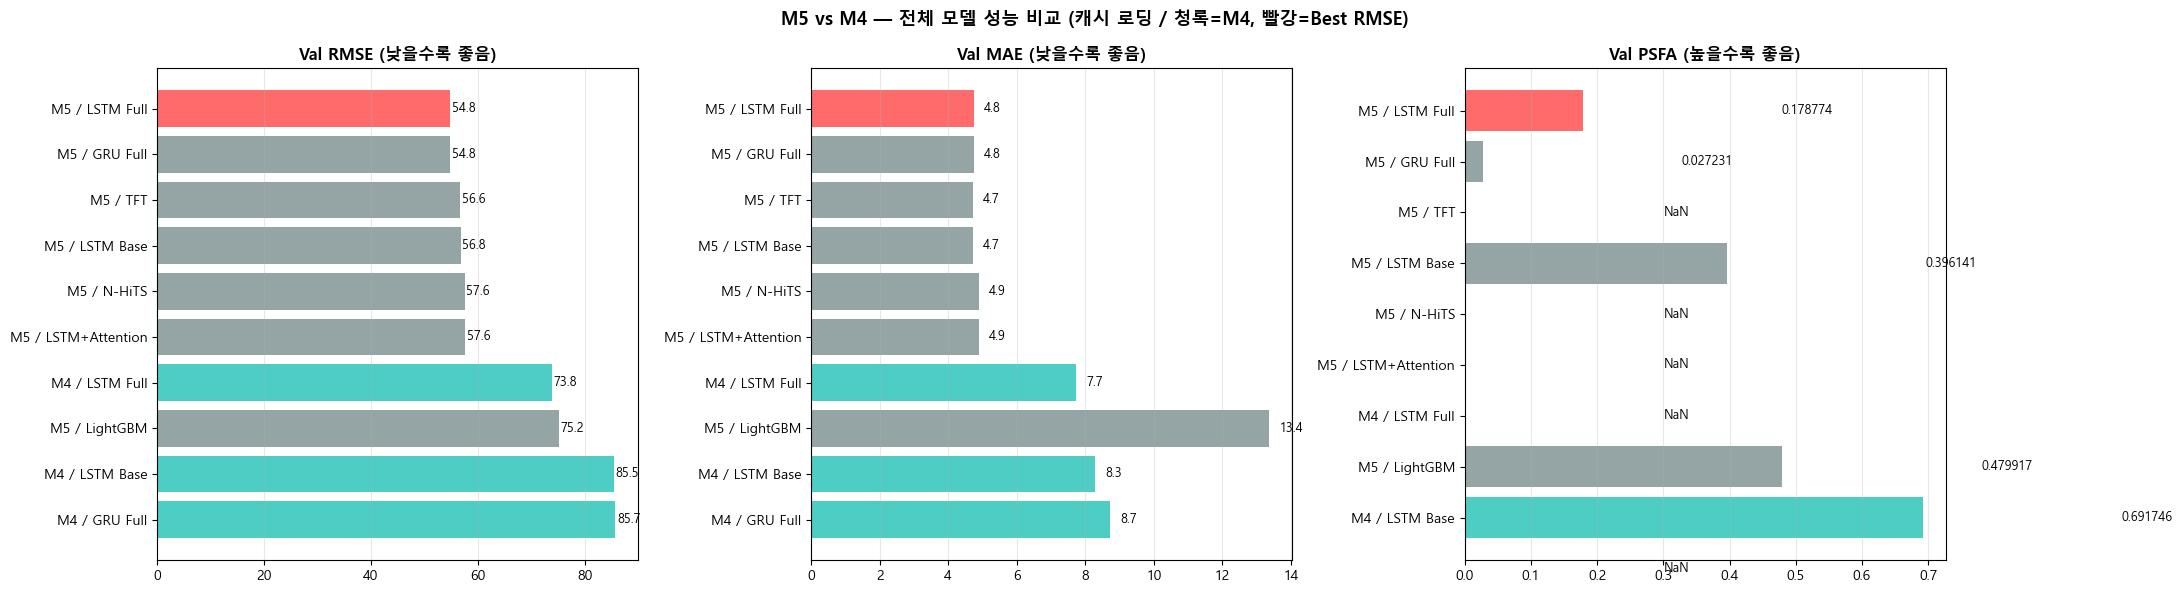

In [50]:
# ── 5-9. M4~M5 최종 모델 성능 비교 ───────────────────────────

# (추가) 5-8B를 아직 안 돌렸으면 자동 로드
if 'ALL_RESULTS_PSFA' not in globals():
    load_step5_cache(verbose=False)

# 1) 캐시에서 RMSE/MAE/PSFA 정보 꺼내서 pasted 스타일용 dict 생성
all_results_loaded = {}

for model_name, metrics in ALL_RESULTS_PSFA.items():
    all_results_loaded[model_name] = {
        'RMSE': metrics.get('RMSE', np.nan),
        'MAE':  metrics.get('MAE', np.nan),
        'PSFA': metrics.get('PSFA', np.nan),
    }

# RMSE 없는 이상치 제거
all_results_loaded = {
    k: v for k, v in all_results_loaded.items()
    if pd.notna(v['RMSE']) and v['RMSE'] < 999999
}

# 2) RMSE 기준 정렬
sorted_results_loaded = sorted(all_results_loaded.items(), key=lambda x: x[1]['RMSE'])

# 3) 표 출력 (pasted 스타일 + PSFA 컬럼 추가)
print('=' * 78)
print('📊 M5 vs M4 전체 모델 성능 비교 (캐시 로딩 버전)')
print('=' * 78)
print(f'{"모델":<25} | {"Val RMSE":>10} | {"Val MAE":>10} | {"Val PSFA":>10} | {"순위":>4}')
print('-' * 78)

for rank, (name, m) in enumerate(sorted_results_loaded, 1):
    medal = '🥇' if rank == 1 else '🥈' if rank == 2 else '🥉' if rank == 3 else '  '
    tag   = ' ★M4' if 'M4' in name else ''
    psfa_txt = f'{m["PSFA"]:.6f}' if pd.notna(m['PSFA']) else '   NaN'
    print(f'{medal} {name:<23} | {m["RMSE"]:>10,.1f} | {m["MAE"]:>10,.1f} | {psfa_txt:>10} | {rank:>4}{tag}')

# 4) 그래프용 데이터
names  = [n for n, _ in sorted_results_loaded]
rmses  = [m['RMSE'] for _, m in sorted_results_loaded]
maes   = [m['MAE']  for _, m in sorted_results_loaded]
psfas  = [m['PSFA'] if pd.notna(m['PSFA']) else np.nan for _, m in sorted_results_loaded]

colors = ['#4ECDC4' if 'M4' in n else
          '#FF6B6B' if i == 0 else
          '#95a5a6' for i, n in enumerate(names)]

# 5) 시각화
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('M5 vs M4 — 전체 모델 성능 비교 (캐시 로딩 / 청록=M4, 빨강=Best RMSE)', fontsize=13, fontweight='bold')

for ax, values, title in zip(
    axes,
    [rmses, maes, psfas],
    ['Val RMSE (낮을수록 좋음)', 'Val MAE (낮을수록 좋음)', 'Val PSFA (높을수록 좋음)']
):
    bars = ax.barh(names[::-1], values[::-1], color=colors[::-1])
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    for bar, val in zip(bars, values[::-1]):
        label = 'NaN' if pd.isna(val) else (f'{val:.6f}' if 'PSFA' in title else f'{val:.1f}')
        x_pos = 0 if pd.isna(val) else bar.get_width()
        ax.text(x_pos + 0.3, bar.get_y() + bar.get_height()/2, label, va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 6) 기존 흐름 호환용
ALL_RESULTS = {k: {'RMSE': v['RMSE'], 'MAE': v['MAE']} for k, v in sorted_results_loaded}
ALL_RESULTS_PSFA_SORTED = {k: v for k, v in sorted_results_loaded}

### 5-10. 피처 중요도 차이



📊 보조 분석: M4 / M5 피처 중요도 (캐시 로드 결과)
✅ STEP5_IMPORTANCE_M4 shape: (18, 3)
✅ STEP5_IMPORTANCE_M5 shape: (19, 3)
✅ STEP5_IMPORTANCE_COMPARE shape: (19, 7)

【M5 Top 10 중요 피처】
        feature  importance_M5  rank_M5
          lag_1            894        1
          lag_7            689        2
          price            370        3
  rolling_std_7            359        4
       kw_lag_1            310        5
         kw_log            296        6
 rolling_std_30            276        7
    day_of_week            276        8
recovery_median            249        9
       kw_lag_3            244       10

【M4 Top 10 중요 피처】
        feature  importance_M4  rank_M4
          lag_1            856        1
          lag_7            611        2
recovery_median            372        3
  rolling_std_7            367        4
          price            328        5
    day_of_week            317        6
 rolling_std_30            281        7
       kw_lag_1            265        8
       kw_

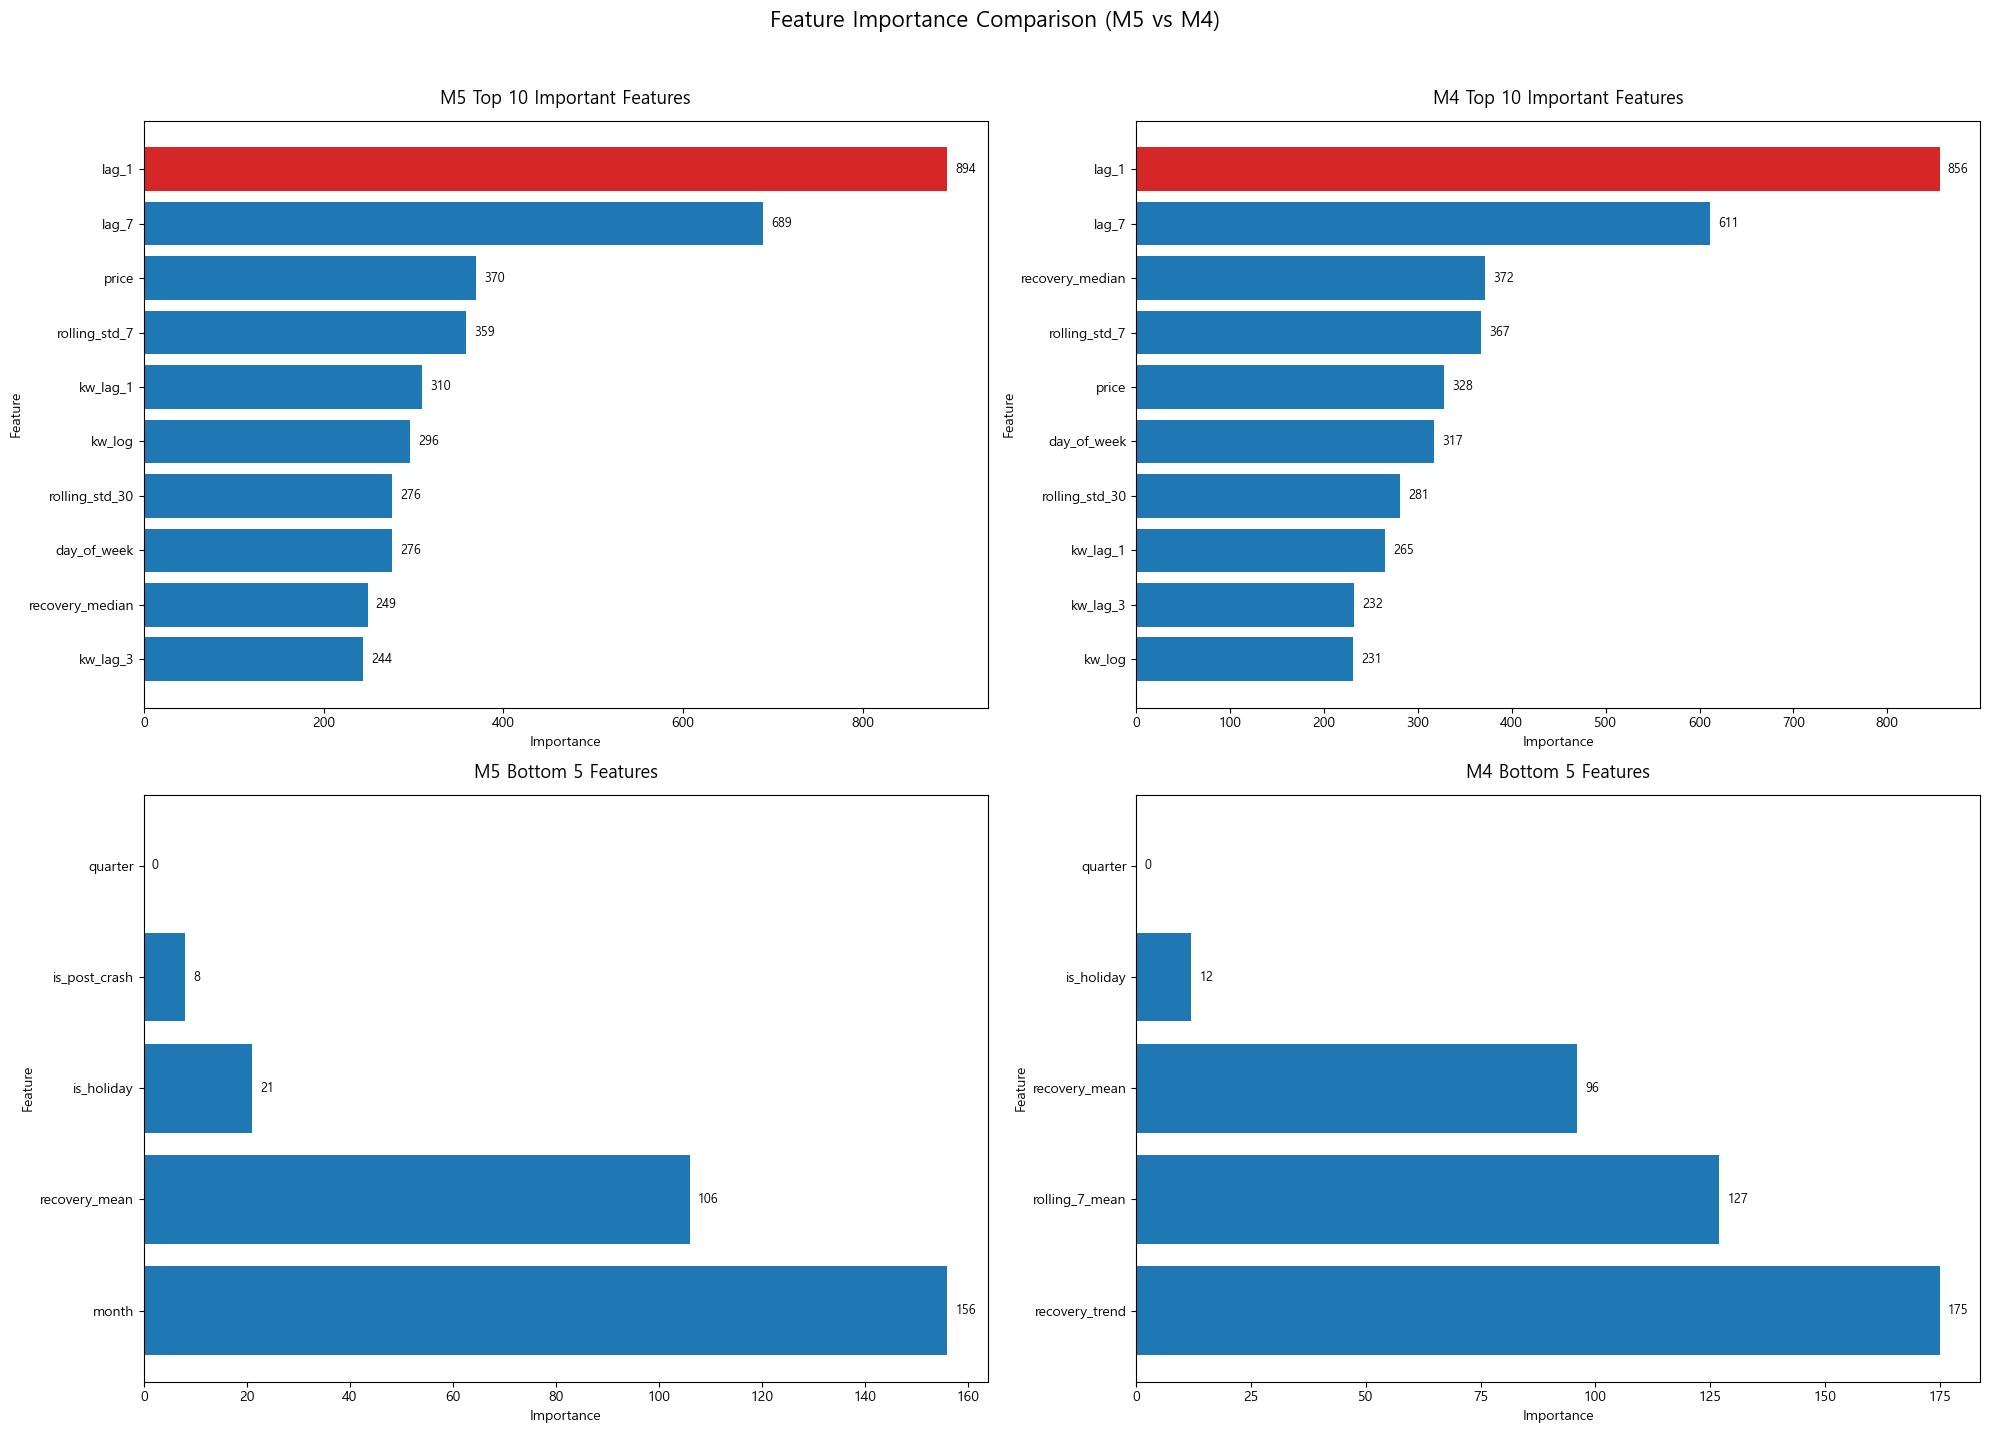

In [51]:
# ── 5-10A. 보조 분석: M4 / M5 피처 중요도 (캐시 출력용) ───────────────────────

import pandas as pd
import matplotlib.pyplot as plt

print('\n' + '='*70)
print('📊 보조 분석: M4 / M5 피처 중요도 (캐시 로드 결과)')
print('='*70)

# ------------------------------------------------------------------
# 0) STEP5 캐시가 아직 없으면 공통 로더 1회 실행
# ------------------------------------------------------------------
if (
    'STEP5_CACHE_INFO' not in globals()
    or not isinstance(STEP5_CACHE_INFO, dict)
    or not STEP5_CACHE_INFO.get('loaded', False)
):
    load_step5_cache(verbose=False)

print(f'✅ STEP5_IMPORTANCE_M4 shape: {STEP5_IMPORTANCE_M4.shape}')
print(f'✅ STEP5_IMPORTANCE_M5 shape: {STEP5_IMPORTANCE_M5.shape}')
print(f'✅ STEP5_IMPORTANCE_COMPARE shape: {STEP5_IMPORTANCE_COMPARE.shape}')

# ------------------------------------------------------------------
# 1) 정렬/출력용 테이블 만들기
# ------------------------------------------------------------------
m5_imp = (
    STEP5_IMPORTANCE_M5[['feature', 'importance_M5', 'rank_M5']]
    .sort_values(['importance_M5', 'rank_M5'], ascending=[False, True])
    .reset_index(drop=True)
)

m4_imp = (
    STEP5_IMPORTANCE_M4[['feature', 'importance_M4', 'rank_M4']]
    .sort_values(['importance_M4', 'rank_M4'], ascending=[False, True])
    .reset_index(drop=True)
)

# Top10: 중요도 높은 순
m5_top10 = m5_imp.head(10).copy()
m4_top10 = m4_imp.head(10).copy()

# Bottom5: 중요도 낮은 순
m5_bottom5 = (
    m5_imp.tail(5)
    .sort_values(['importance_M5', 'rank_M5'], ascending=[True, False])
    .reset_index(drop=True)
)

m4_bottom5 = (
    m4_imp.tail(5)
    .sort_values(['importance_M4', 'rank_M4'], ascending=[True, False])
    .reset_index(drop=True)
)

# ------------------------------------------------------------------
# 2) 텍스트 출력
# ------------------------------------------------------------------
print('\n【M5 Top 10 중요 피처】')
print(m5_top10.to_string(index=False))

print('\n【M4 Top 10 중요 피처】')
print(m4_top10.to_string(index=False))

print('\n【M5 Bottom 5 피처】')
print(m5_bottom5.to_string(index=False))

print('\n【M4 Bottom 5 피처】')
print(m4_bottom5.to_string(index=False))

# ------------------------------------------------------------------
# 3) 그래프 함수
#    - top: 가장 중요한 1등 변수 강조
#    - bottom: 가장 덜 중요한 1등 변수 강조
# ------------------------------------------------------------------
def draw_barh(ax, df, feature_col, value_col, title, highlight='max'):
    plot_df = df.copy()

    # barh는 아래→위로 그려지므로,
    # "1등 막대가 맨 위"에 오도록 뒤집어서 그림
    plot_df = plot_df.iloc[::-1].reset_index(drop=True)

    values = plot_df[value_col].tolist()

    # 기본색 + 강조색
    colors = ['C0'] * len(plot_df)

    if len(plot_df) > 0:
        if highlight == 'max':
            target_value = plot_df[value_col].max()
        elif highlight == 'min':
            target_value = plot_df[value_col].min()
        else:
            target_value = None

        if target_value is not None:
            # 같은 값이 여러 개면 첫 번째만 강조
            target_idx = plot_df.index[plot_df[value_col] == target_value][0]
            colors[target_idx] = 'C3'

    ax.barh(plot_df[feature_col], plot_df[value_col], color=colors)
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_xlabel('Importance')
    ax.set_ylabel('Feature')

    x_max = plot_df[value_col].max() if len(plot_df) > 0 else 0
    pad = max(x_max * 0.01, 1)

    for i, v in enumerate(plot_df[value_col]):
        ax.text(v + pad, i, f'{v:,.0f}', va='center', fontsize=9)

# ------------------------------------------------------------------
# 4) 하나의 큰 캔버스에 4개 그래프
#    (1행: M5 Top10 / M4 Top10)
#    (2행: M5 Bottom5 / M4 Bottom5)
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# 1행: Top10 (가장 중요한 1등 변수 강조)
draw_barh(
    axes[0, 0],
    m5_top10,
    'feature',
    'importance_M5',
    'M5 Top 10 Important Features',
    highlight='max'
)

draw_barh(
    axes[0, 1],
    m4_top10,
    'feature',
    'importance_M4',
    'M4 Top 10 Important Features',
    highlight='max'
)

# 2행: Bottom5 (가장 덜 중요한 1등 변수 강조)
draw_barh(
    axes[1, 0],
    m5_bottom5,
    'feature',
    'importance_M5',
    'M5 Bottom 5 Features',
    highlight='min'
)

draw_barh(
    axes[1, 1],
    m4_bottom5,
    'feature',
    'importance_M4',
    'M4 Bottom 5 Features',
    highlight='min'
)

plt.suptitle('Feature Importance Comparison (M5 vs M4)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
## STEP 6 — Method 4 기반 최종 딥러닝 재학습

> STEP 5 비교 결과를 바탕으로,  
> 최종 제출용 딥러닝 모델을 Method 4 데이터로 전체 재학습  

| 항목 | STEP 5 | STEP 6 |
|------|--------|--------|
| 목적 | 방법 비교 및 실험 | 최종 제출용 재학습 |
| 데이터 | Method 5 중심 비교 | Method 4 전체 데이터 |
| 결과물 | 성능 비교 | 최종 딥러닝 체크포인트 |

### 6-1. 학습 환경 설정 + 공통 유틸 (Optuna)

In [52]:
# ── 6-1. Optuna 환경 설정 ─────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'], check=True)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f'✅ Optuna {optuna.__version__} 설치 완료')

# ── Val 데이터셋 생성 (Optuna 전체에서 공유) ────────────────────────────
# 이미 생성된 것이 있으면 재활용, 없으면 새로 생성
try:
    train_ds_full
    val_ds_full
    print('✅ train_ds_full, val_ds_full 이미 존재')
except NameError:
    train_ds_full = SalesDataset(df_scaled_full, SEQ_LEN, PRED_LEN, NUM_COLS_FULL, CAT_COLS,
                                  mode='train', val_start=val_start)
    val_ds_full   = SalesDataset(df_scaled_full, SEQ_LEN, PRED_LEN, NUM_COLS_FULL, CAT_COLS,
                                  mode='val', val_start=val_start)
    print(f'✅ Dataset 생성: train={len(train_ds_full):,} val={len(val_ds_full):,}')


✅ Optuna 4.7.0 설치 완료
  → [train] 샘플 수: 4,112,594개
  ⚠️ 데이터 부족으로 건너뛴 제품: 6004개
  → [val] 샘플 수: 9,886개
✅ Dataset 생성: train=4,112,594 val=9,886


### 6-2. 최종 딥러닝 재학습 (M4 전체 데이터 + Resume 지원)
> STEP 5 비교 결과를 바탕으로 선택한 최종 딥러닝 모델을 Method 4 전체 데이터로 재학습

**Resume 지원:**
- 중단 시 체크포인트부터 재개
- 10 epoch마다 자동 저장
- 1시간+ 학습 대비

In [53]:
# ── 6-2. 최종 딥러닝 재학습 (Resume 지원) ───────────────────────────────────


import torch

# ── [Helper] 학습 기록 출력 함수 (어디서든 호출 가능하게!) ────────────────
def print_learning_history(hist):
    if not hist or 'train_loss' not in hist:
        print("📊 이전 학습 기록이 없습니다.")
        return
    
    print('\n📊 상세 학습 기록 (History):')
    train_loss = hist['train_loss']
    for i in range(len(train_loss)):
        epoch = i + 1
        # 5단위 에폭 또는 마지막 에폭만 출력 (가독성)
        if epoch % 5 == 0 or epoch == len(train_loss):
            train = train_loss[i]
            val = hist['val_loss'][i] if 'val_loss' in hist else 0
            rmse = hist['val_rmse'][i] if 'val_rmse' in hist else 0
            mae = hist['val_mae'][i] if 'val_mae' in hist else 0
            
            print(f"  Epoch {epoch:3d} | train={train:.4f} val={val:.4f} RMSE={rmse:.1f} MAE={mae:.1f}")

# ── Best 모델 선택  ────────────────────────────────
USE_BEST_GRU = False  # Best가 GRU면 True

# ── 전체 데이터셋 생성 ───────────────────────────────────────────
print('📦 전체 데이터로 Dataset 생성 중...')
fake_val_start = '2099-12-31'

train_ds_retrain = SalesDataset(
    df_scaled_full, SEQ_LEN, PRED_LEN, NUM_COLS_FULL, CAT_COLS,
    mode='train', val_start=fake_val_start
)
print(f'  Train+Val 통합 완료: {len(train_ds_retrain):,}행')

# ── Full HP 설정 ───────────────────────────────────────────────────
hp_full = {
    'batch_size': 512,   # 1024보다 반으로 줄임 (더 세밀하게 학습)
    'lr': 0.001,
    'n_epochs': 20,      # 15번에서 20번으로 늘림 (더 충분히 학습)
    'patience': 7,       # 조금 더 인내심 있게 지켜봄
}


# ── Resume 설정 및 실행 ────────────────────────────────────────────
dl_ckpt_path = os.path.join(OUTPUT_DIR_M4, 'model_dl_retrain.pt')
RESUME = True 

if os.path.exists(dl_ckpt_path) and RESUME:
    print('\n📂 체크포인트 발견! 데이터를 로드합니다...')
    ckpt = torch.load(dl_ckpt_path, map_location=device, weights_only=False)
    
    # 1. 공통 정보 추출
    history_dl = ckpt.get('history', {})
    
    # [핵심] 어떤 상태든 일단 기록부터 보여주기!
    print_learning_history(history_dl)

    # 2. 모델 객체 생성 (공통)
    model_dl = SalesModel(
        num_input_dim=len(NUM_COLS_FULL),
        cat_vocab_sizes=CAT_VOCAB_SIZES,
        emb_dim=HP['emb_dim'],
        hidden_dim=HP['hidden_dim'],
        num_layers=HP['num_layers'],
        pred_len=PRED_LEN,
        dropout=HP['dropout'],
        rnn_type='GRU' if USE_BEST_GRU else 'LSTM'
    ).to(device)

    # ── 분기 처리 ────────────────────────────────────────────────
    if ckpt.get('completed', False):
        print('\n✅ [상태: 학습 완료] 추가 학습 없이 모델을 로드했습니다.')
        model_dl.load_state_dict(ckpt['model_state'])
        
        print(f'  Model: {"GRU" if USE_BEST_GRU else "LSTM"}')
        print(f'  Final Train Loss: {history_dl["train_loss"][-1]:.4f}')
    
    else:
        print('\n🔄 [상태: 진행 중] 이어서 학습을 시작합니다.')
        start_epoch = ckpt.get('epoch', len(history_dl.get('train_loss', [])))
        
        model_dl.load_state_dict(ckpt['model_state'])
        optimizer = torch.optim.Adam(model_dl.parameters(), lr=hp_full['lr'])
        if 'optimizer_state' in ckpt:
            optimizer.load_state_dict(ckpt['optimizer_state'])
        
        # 재학습 실행
        model_dl, history_dl = run_experiment_resume(
            f'DL 재학습 ({"GRU" if USE_BEST_GRU else "LSTM"}) - Resume',
            model_dl, optimizer,
            train_ds_retrain, val_ds_full,
            hp_full, device,
            start_epoch=start_epoch,
            history=history_dl,
            ckpt_path=dl_ckpt_path
        )
        
        # 완료 후 저장
        torch.save({
            'model_state': model_dl.state_dict(),
            'history': history_dl,
            'completed': True,
        }, dl_ckpt_path)
        print('✅ 재학습 완료 및 저장 성공!')

else:
    print('\n🆕 체크포인트 없음: 처음부터 학습을 시작합니다.')
    
    model_dl = SalesModel(
        num_input_dim=len(NUM_COLS_FULL),
        cat_vocab_sizes=CAT_VOCAB_SIZES,
        emb_dim=HP['emb_dim'],
        hidden_dim=HP['hidden_dim'],
        num_layers=HP['num_layers'],
        pred_len=PRED_LEN,
        dropout=HP['dropout'],
        rnn_type='GRU' if USE_BEST_GRU else 'LSTM'
    ).to(device)
    
    optimizer = torch.optim.Adam(model_dl.parameters(), lr=hp_full['lr'])
    
    model_dl, history_dl = run_experiment_resume(
        f'DL 재학습 ({"GRU" if USE_BEST_GRU else "LSTM"})',
        model_dl, optimizer,
        train_ds_retrain, val_ds_full,
        hp_full, device,
        start_epoch=0,
        history=None,
        ckpt_path=dl_ckpt_path
    )
    
    torch.save({
        'model_state': model_dl.state_dict(),
        'history': history_dl,
        'completed': True,
    }, dl_ckpt_path)
    print('✅ model_dl 신규 저장 완료!')



📦 전체 데이터로 Dataset 생성 중...
  → [train] 샘플 수: 4,320,056개
  Train+Val 통합 완료: 4,320,056행

📂 체크포인트 발견! 데이터를 로드합니다...

📊 상세 학습 기록 (History):
  Epoch   5 | train=0.1537 val=0.0281 RMSE=73.1 MAE=6.3
  Epoch  10 | train=0.1334 val=0.0250 RMSE=68.2 MAE=6.0
  Epoch  15 | train=0.1251 val=0.0248 RMSE=66.5 MAE=5.8
  Epoch  20 | train=0.1205 val=0.0262 RMSE=59.4 MAE=5.5

✅ [상태: 학습 완료] 추가 학습 없이 모델을 로드했습니다.
  Model: LSTM
  Final Train Loss: 0.1205


---
## STEP 7 — Method 4 앙상블 및 최종 제출

> **앙상블 전략**: Val RMSE 기반 가중 평균
> - 성능 좋은 모델에 높은 가중치 → 성능 나쁜 모델은 낮은 가중치
> - RMSE가 낮을수록 더 많이 반영

### 7-1. M4 앙상블 준비 + 역변환

> **앙상블 전략:** 검증 성능 기반 역수 가중 평균  
> 성능이 좋은 모델일수록 더 큰 비중을 부여  

**LightGBM도 함께 쓰는 이유?**  

| 모델 | 주로 잘 잡는 패턴 |
|------|-------------------|
| LSTM | 시간 흐름, 최근 판매 추세 |
| LightGBM | 브랜드/카테고리별 구조적 수준 |

> 두 모델이 서로 다른 정보를 잘 포착하므로, 단일 모델보다 앙상블이 더 안정적인 최종 예측을 만들 수 있음

In [54]:
# ── 7-1. 앙상블 준비 + 예측 저장 (Resume 지원) ──────────────

import torch, json, os, joblib
import numpy as np

print('🎯 7-1. 앙상블 준비')

# ── 저장 경로 설정 ─────────────────────────────────────────
pred_dl_save_path = os.path.join(OUTPUT_DIR_M4, 'pred_dl_final.npy')
pred_lgb_save_path = os.path.join(OUTPUT_DIR_M4, 'pred_lgb_final.npy')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [1] LightGBM
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
if os.path.exists(pred_lgb_save_path):
    print('📂 LightGBM 예측 로드')
    pred_lgb_final = np.load(pred_lgb_save_path)
    print(f'   예측 평균: {pred_lgb_final.mean():.2f}')
else:
    print('🔄 LightGBM 예측 생성')
    lgb_ckpt_path = os.path.join(OUTPUT_DIR_M4, 'model_lgb.pt')
    lgb_data = torch.load(lgb_ckpt_path, map_location='cpu', weights_only=False)
    pred_lgb_raw = lgb_data['pred_lgb']
    pred_lgb_final = np.maximum(pred_lgb_raw, 0)
    
    # 저장
    np.save(pred_lgb_save_path, pred_lgb_final)
    print(f'   예측 평균: {pred_lgb_final.mean():.2f}')
    print(f'   저장: {pred_lgb_save_path}')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [2] 딥러닝
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
if os.path.exists(pred_dl_save_path):
    print('\n📂 딥러닝 예측 로드')
    pred_dl_final = np.load(pred_dl_save_path)
    print(f'   예측 평균: {pred_dl_final.mean():.2f}')
else:
    print('\n🔄 딥러닝 예측 생성')
    
    scaler_full = joblib.load(os.path.join(OUTPUT_DIR_M4, 'scaler_full.pkl'))
    qty_idx = 0
    
    dl_ckpt_path = os.path.join(OUTPUT_DIR_M4, 'model_dl_retrain.pt')
    ckpt = torch.load(dl_ckpt_path, map_location=device, weights_only=False)
    
    # 모델 로드
    model_dl = SalesModel(
        num_input_dim=len(NUM_COLS_FULL),
        cat_vocab_sizes=CAT_VOCAB_SIZES,
        emb_dim=HP['emb_dim'],
        hidden_dim=HP['hidden_dim'],
        num_layers=HP['num_layers'],
        pred_len=PRED_LEN,
        dropout=HP['dropout'],
        rnn_type='LSTM'
    ).to(device)
    
    model_dl.load_state_dict(ckpt['model_state'])
    model_dl.eval()
    
    # 예측
    pred_ds_dl = SalesDataset(
        df_scaled_full, SEQ_LEN, PRED_LEN, NUM_COLS_FULL, CAT_COLS, 
        mode='pred'
    )
    
    print(f'  예측 샘플: {len(pred_ds_dl):,}개')
    
    pred_loader = DataLoader(pred_ds_dl, batch_size=512, shuffle=False, num_workers=0)
    
    all_preds = []
    with torch.no_grad():
        for x_num, x_cat, _ in pred_loader:
            out = model_dl(x_num.to(device), x_cat.to(device))
            all_preds.append(out.cpu().numpy())
    
    pred_dl_raw = np.concatenate(all_preds)
    
    # 역변환
    pred_dl_log = pred_dl_raw * scaler_full.scale_[qty_idx] + scaler_full.mean_[qty_idx]
    pred_dl_final = np.expm1(np.clip(pred_dl_log, 0, 20))
    pred_dl_final = np.maximum(pred_dl_final, 0)
    
    # 저장
    np.save(pred_dl_save_path, pred_dl_final)
    print(f'   Raw 평균: {pred_dl_raw.mean():.4f}')
    print(f'   역변환 후 평균: {pred_dl_final.mean():.2f}')
    print(f'   저장: {pred_dl_save_path}')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [3] 앙상블 가중치
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
weights_path = os.path.join(OUTPUT_DIR_M4, 'ensemble_weights.json')

if os.path.exists(weights_path):
    print('\n📂 앙상블 가중치 로드')
    with open(weights_path, 'r') as f:
        weights = json.load(f)
        w_lgb = weights['w_lgb']
        w_dl = weights['w_dl']
        lgb_rmse = weights['lgb_rmse']
        dl_rmse = weights['dl_rmse']
else:
    print('\n🔄 앙상블 가중치 계산')
    
    lgb_ckpt_path = os.path.join(OUTPUT_DIR_M4, 'model_lgb.pt')
    lgb_data = torch.load(lgb_ckpt_path, map_location='cpu', weights_only=False)
    lgb_rmse = lgb_data['val_rmse']
    
    dl_ckpt_path = os.path.join(OUTPUT_DIR_M4, 'model_dl_retrain.pt')
    ckpt = torch.load(dl_ckpt_path, map_location=device, weights_only=False)
    dl_rmse = min(ckpt['history']['val_rmse'])
    
    w_lgb = (1 / lgb_rmse) / (1/lgb_rmse + 1/dl_rmse)
    w_dl = 1 - w_lgb
    
    # ── 최종 결과 저장 ─────────────────────────────────────────
    weights = {'w_lgb': w_lgb, 'w_dl': w_dl, 'lgb_rmse': lgb_rmse, 'dl_rmse': dl_rmse}
    with open(weights_path, 'w') as f:
        json.dump(weights, f, indent=2)
    print(f'   저장: ensemble_weights.json')

print(f'\n📊 앙상블 가중치')
print(f'   LightGBM RMSE: {lgb_rmse:.1f} → 가중치: {w_lgb:.3f}')
print(f'   딥러닝   RMSE: {dl_rmse:.1f} → 가중치: {w_dl:.3f}')

# ── 7-1 완료 알림 ─────────────────────────────────────────

🎯 7-1. 앙상블 준비
📂 LightGBM 예측 로드
   예측 평균: 15.19

📂 딥러닝 예측 로드
   예측 평균: 15.50

📂 앙상블 가중치 로드

📊 앙상블 가중치
   LightGBM RMSE: 108.9 → 가중치: 0.339
   딥러닝   RMSE: 55.9 → 가중치: 0.661


✅ M4 앙상블 Validation 캐시 로딩 완료
  saved_at : 2026-03-17 19:10:57
  tag      : m4_ensemble_val_psfa_v1
  RMSE     : 80.4220
  MAE      : 7.0629
  PSFA     : 0.793063
  Eval PIDs: 9,886
  weights  : LGB=0.339284, DL=0.660716

[대분류별 PSFA]
 - B002-C001-0001: 0.837443
 - B002-C001-0002: 0.757114
 - B002-C001-0003: 0.852865
 - B002-C001-0004: 0.746119
 - B002-C001-0005: 0.771776


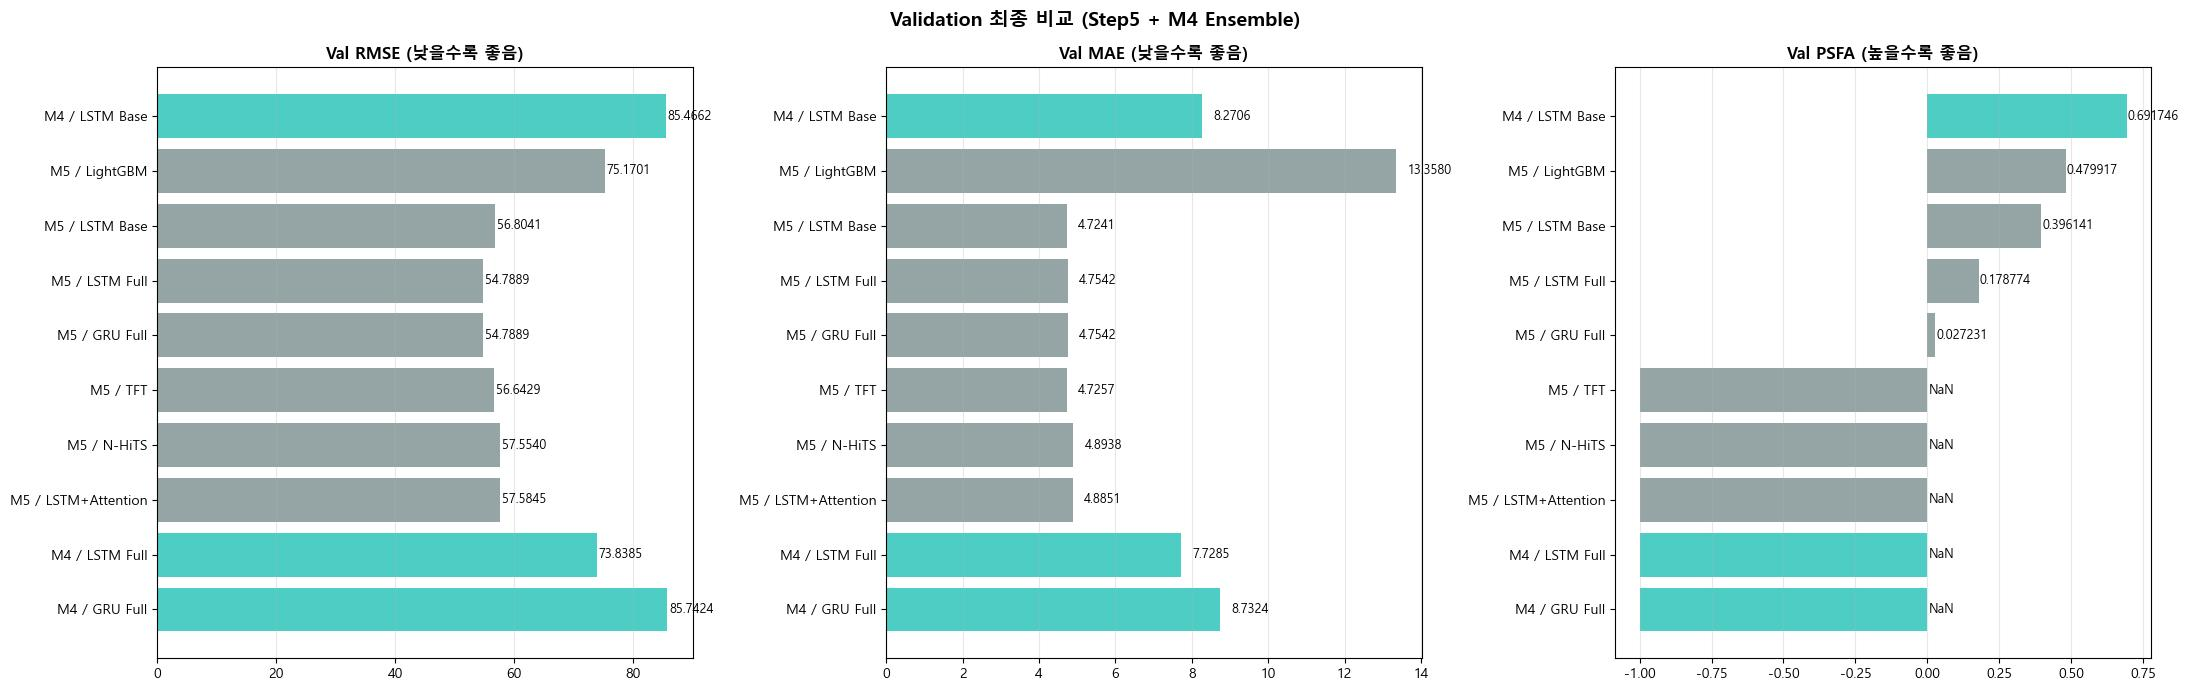


색상 안내: 청록=M4, 주황=Ensemble, 빨강=현재 정렬 기준 상위, 회색=기타


In [55]:
# ── 7-1B. M4 앙상블 Validation 캐시 로딩 ─────────────────────────

import pickle

def load_m4_ensemble_val_cache(save_dir=None, tag='m4_ensemble_val_psfa_v1', inject_globals=True):
    if save_dir is None:
        save_dir = os.path.join(OUTPUT_DIR_M4, 'cache')

    pkl_path = os.path.join(save_dir, f'{tag}.pkl')
    if not os.path.exists(pkl_path):
        raise FileNotFoundError(f'캐시 파일 없음: {pkl_path}')

    with open(pkl_path, 'rb') as f:
        payload = pickle.load(f)

    result = payload['result']

    if inject_globals:
        globals()['M4_ENSEMBLE_VAL_RESULT'] = result
        globals()['M4_ENSEMBLE_VAL_METRICS'] = {
            'RMSE': result['rmse'],
            'MAE': result['mae'],
            'PSFA': result['psfa'],
        }

    print('✅ M4 앙상블 Validation 캐시 로딩 완료')
    print(f'  saved_at : {payload["saved_at"]}')
    print(f'  tag      : {payload["tag"]}')
    print(f'  RMSE     : {result["rmse"]:.4f}')
    print(f'  MAE      : {result["mae"]:.4f}')
    print(f'  PSFA     : {result["psfa"]:.6f}')
    print(f'  Eval PIDs: {len(result["val_pids"]):,}')
    print(f'  weights  : LGB={result["weights"]["lgb"]:.6f}, DL={result["weights"]["dl"]:.6f}')

    print('\n[대분류별 PSFA]')
    for k, v in sorted(result['psfa_by_cat'].items(), key=lambda x: x[0]):
        print(f' - {k}: {v:.6f}')

    return payload

# 실행
M4_ENSEMBLE_CACHE = load_m4_ensemble_val_cache(tag='m4_ensemble_val_psfa_v1', inject_globals=True)


# ── Validation 최종 비교 그래프 ─────────────────────────────────

if 'FINAL_VAL_COMPARE_TABLE' not in globals():
    load_step5_cache(verbose=False)
    
plot_df = FINAL_VAL_COMPARE_TABLE.copy()

# NaN PSFA는 맨 아래로 보내기 위해 임시 처리
plot_df['PSFA_plot'] = plot_df['PSFA'].fillna(-1)

# 보기 좋게 정렬: PSFA 높은 순, 같으면 RMSE 낮은 순
plot_df = plot_df.sort_values(['PSFA_plot', 'RMSE'], ascending=[False, True]).reset_index(drop=True)

names = plot_df['model'].tolist()
rmses = plot_df['RMSE'].tolist()
maes  = plot_df['MAE'].tolist()
psfas = plot_df['PSFA'].tolist()

# 색상 규칙
colors = []
for i, name in enumerate(names):
    if 'Ensemble' in name:
        colors.append('#f39c12')   # 주황: Ensemble
    elif 'M4' in name:
        colors.append('#4ECDC4')   # 청록: M4
    elif i == 0:
        colors.append('#FF6B6B')   # 빨강: 현재 정렬 기준 1위
    else:
        colors.append('#95a5a6')   # 회색: 나머지

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Validation 최종 비교 (Step5 + M4 Ensemble)', fontsize=14, fontweight='bold')

# 1) RMSE
bars = axes[0].barh(names[::-1], rmses[::-1], color=colors[::-1])
axes[0].set_title('Val RMSE (낮을수록 좋음)', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
for bar, val in zip(bars, rmses[::-1]):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# 2) MAE
bars = axes[1].barh(names[::-1], maes[::-1], color=colors[::-1])
axes[1].set_title('Val MAE (낮을수록 좋음)', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
for bar, val in zip(bars, maes[::-1]):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# 3) PSFA
psfa_values_for_plot = [(-1 if pd.isna(v) else v) for v in psfas]
bars = axes[2].barh(names[::-1], psfa_values_for_plot[::-1], color=colors[::-1])
axes[2].set_title('Val PSFA (높을수록 좋음)', fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

for bar, val in zip(bars, psfas[::-1]):
    label = 'NaN' if pd.isna(val) else f'{val:.6f}'
    x_pos = 0 if pd.isna(val) else bar.get_width()
    axes[2].text(x_pos + 0.003, bar.get_y() + bar.get_height()/2,
                 label, va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\n색상 안내: 청록=M4, 주황=Ensemble, 빨강=현재 정렬 기준 상위, 회색=기타')

### 7-2. 최종 예측 + 후처리

In [56]:
# ── 7-2. 최종 예측 + 후처리 ──────────────────────────────────

import json
import numpy as np

print('=' * 60)
print('🎯 7-2. 앙상블 예측 + 후처리')
print('=' * 60)

# ── 저장된 예측 로드 ───────────────────────────────────────
print('📂 예측 파일 로드 중...')

pred_lgb_final = np.load(os.path.join(OUTPUT_DIR_M4, 'pred_lgb_final.npy'))
pred_dl_final = np.load(os.path.join(OUTPUT_DIR_M4, 'pred_dl_final.npy'))

with open(os.path.join(OUTPUT_DIR_M4, 'ensemble_weights.json'), 'r') as f:
    weights = json.load(f)
    w_lgb = weights['w_lgb']
    w_dl = weights['w_dl']

print(f'✅ 로드 완료')
print(f'   LightGBM: {pred_lgb_final.shape} (평균: {pred_lgb_final.mean():.2f})')
print(f'   딥러닝: {pred_dl_final.shape} (평균: {pred_dl_final.mean():.2f})')
print(f'   가중치: LGB {w_lgb:.3f} / DL {w_dl:.3f}')

# ── pids 로드 ─────────────────────────────────────────────
pids_path = os.path.join(OUTPUT_DIR_M4, 'pred_dl_pids.npy')

if os.path.exists(pids_path):
    print('\n📂 pids 로드')
    pred_dl_pids = np.load(pids_path, allow_pickle=True).tolist()
    print(f'   pids: {len(pred_dl_pids):,}개')
else:
    print('\n📦 Dataset 생성 (pids 추출용)...')
    pred_ds_dl = SalesDataset(
        df_scaled_full, SEQ_LEN, PRED_LEN, NUM_COLS_FULL, CAT_COLS, 
        mode='pred'
    )
    pred_dl_pids = pred_ds_dl.pids if hasattr(pred_ds_dl, 'pids') else []
    np.save(pids_path, pred_dl_pids)
    print(f'   샘플 수: {len(pred_ds_dl):,}개')
    print(f'   pids 수: {len(pred_dl_pids):,}개')

# ── 앙상블 ───────────────────────────────────────────────────
print('\n🔗 앙상블 중...')

final_pred = w_lgb * pred_lgb_final.copy()

if len(pred_dl_pids) > 0:
    matched_count = 0
    for idx, pid in enumerate(pred_dl_pids):
        if idx >= pred_dl_final.shape[0]: 
            break
        row_idx = train_clean.index[train_clean['ID'] == pid]
        if len(row_idx) > 0:
            final_pred[row_idx[0]] += w_dl * pred_dl_final[idx]
            matched_count += 1
    print(f'✅ 딥러닝 반영: {matched_count:,}/{len(pred_dl_pids):,}개 제품 매칭')
else:
    min_n = min(final_pred.shape[0], pred_dl_final.shape[0])
    final_pred[:min_n] += w_dl * pred_dl_final[:min_n]
    print(f'✅ 딥러닝 반영 (인덱스 매칭: {min_n:,}개)')

print(f'앙상블 후 평균: {final_pred.mean():.2f}')

# ── 후처리 ───────────────────────────────────────────────────
print('\n🛠️ 후처리 중...')

# (1) 음수 제거
final_pred = np.maximum(final_pred, 0)

# (2) 상한선 (예측값 자체 기준)
pred_max_per_product = final_pred.max(axis=1, keepdims=True)
cap = np.maximum(pred_max_per_product * 3, 50)
final_pred = np.minimum(final_pred, cap)
print(f'  상한선 적용 완료')

# (3) 정수 변환
final_pred = np.round(final_pred).astype(int)

# (4) 전체 0인 제품 처리
zero_products = (final_pred.sum(axis=1) == 0)
print(f'  전체 0인 제품: {sum(zero_products):,}개')

# (5) 극소 예측 제품 처리 (합계 < 5)
low_pred = (final_pred.sum(axis=1) < 5) & ~zero_products
final_pred[low_pred] = np.minimum(final_pred[low_pred], 1)
print(f'  극소 예측 제품: {sum(low_pred):,}개')

print(f'\n✅ 후처리 완료')
print(f'   평균: {final_pred.mean():.2f}')
print(f'   최댓값: {final_pred.max()}')
print(f'   0인 제품: {sum(zero_products):,}개 ({sum(zero_products)/len(final_pred):.1%})')

# ── 최종 결과 저장 ─────────────────────────────────────────
final_pred_path = os.path.join(OUTPUT_DIR_M4, 'final_pred.npy')
np.save(final_pred_path, final_pred)
print(f'\n💾 최종 예측 저장: {final_pred_path}')

# ── 7-2 완료 알림 ─────────────────────────────────────────

🎯 7-2. 앙상블 예측 + 후처리
📂 예측 파일 로드 중...
✅ 로드 완료
   LightGBM: (15890, 21) (평균: 15.19)
   딥러닝: (15890, 21) (평균: 15.50)
   가중치: LGB 0.339 / DL 0.661

📂 pids 로드
   pids: 15,890개

🔗 앙상블 중...
✅ 딥러닝 반영: 15,890/15,890개 제품 매칭
앙상블 후 평균: 15.39

🛠️ 후처리 중...
  상한선 적용 완료
  전체 0인 제품: 6,521개
  극소 예측 제품: 276개

✅ 후처리 완료
   평균: 15.37
   최댓값: 7561
   0인 제품: 6,521개 (41.0%)

💾 최종 예측 저장: c:\Users\min2m\github\Sales\Team\output\v6_method4\final_pred.npy


### 7-3. 제출 파일 생성

In [57]:
# ── 7-3. 제출 파일 생성 ────────────────────────────────────────────────────

PRED_DATES_LIST = [c for c in submission.columns if c != 'ID']

sub = submission.copy()
for i, col in enumerate(PRED_DATES_LIST):
    sub[col] = final_pred[:, i]

# ── 저장 ─────────────────────────────────────────────────────────────────
sub_path = os.path.join(OUTPUT_DIR_M4, 'submission_ensemble.csv')
sub.to_csv(sub_path, index=False)

print('=' * 60)
print('✅ 제출 파일 생성 완료')
print('=' * 60)
print(f'  파일: {sub_path}')
print(f'  Shape: {sub.shape}')
print(f'  일평균 총량: {final_pred.sum() / 21:,.0f}')
print()

# ── 일별 총량 확인 ───────────────────────────────────────────────────────
dow_names_en = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
print(f'{"날짜":<12} | {"요일":<4} | {"총 예측량":>12}')
print('-' * 35)
for i, col in enumerate(PRED_DATES_LIST):
    d = pd.Timestamp(col)
    total = sub[col].sum()
    print(f'{col:<12} | {dow_names_en[d.dayofweek]:<4} | {total:>12,}')

print()
sub.head()

✅ 제출 파일 생성 완료
  파일: c:\Users\min2m\github\Sales\Team\output\v6_method4\submission_ensemble.csv
  Shape: (15890, 22)
  일평균 총량: 244,182

날짜           | 요일   |        총 예측량
-----------------------------------
2023-04-05   | Wed  |      241,932
2023-04-06   | Thu  |      279,003
2023-04-07   | Fri  |      299,262
2023-04-08   | Sat  |      263,887
2023-04-09   | Sun  |      228,892
2023-04-10   | Mon  |      202,039
2023-04-11   | Tue  |      210,175
2023-04-12   | Wed  |      245,847
2023-04-13   | Thu  |      288,199
2023-04-14   | Fri  |      285,693
2023-04-15   | Sat  |      263,479
2023-04-16   | Sun  |      227,152
2023-04-17   | Mon  |      196,322
2023-04-18   | Tue  |      200,512
2023-04-19   | Wed  |      241,929
2023-04-20   | Thu  |      284,870
2023-04-21   | Fri  |      290,224
2023-04-22   | Sat  |      258,654
2023-04-23   | Sun  |      213,758
2023-04-24   | Mon  |      197,744
2023-04-25   | Tue  |      208,255



,ID,2023-04-05,2023-04-06,2023-04-07,2023-04-08,2023-04-09,2023-04-10,2023-04-11,2023-04-12,2023-04-13,...,2023-04-16,2023-04-17,2023-04-18,2023-04-19,2023-04-20,2023-04-21,2023-04-22,2023-04-23,2023-04-24,2023-04-25
0,0,3,3,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,1,2,2
1,1,1,1,1,1,0,0,0,1,1,...,1,1,1,1,1,1,1,1,1,1
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,3,3,4,4,3,2,3,4,4,...,3,2,2,3,4,4,4,3,2,2


## STEP 8 — DACON 제출 결과

* DACON Public/Private 점수는 홈페이지 결과를 수동으로 입력한 값  
* 로컬 검증 지표와 실제 제출 점수를 함께 비교하기 위한 참고용 섹션  

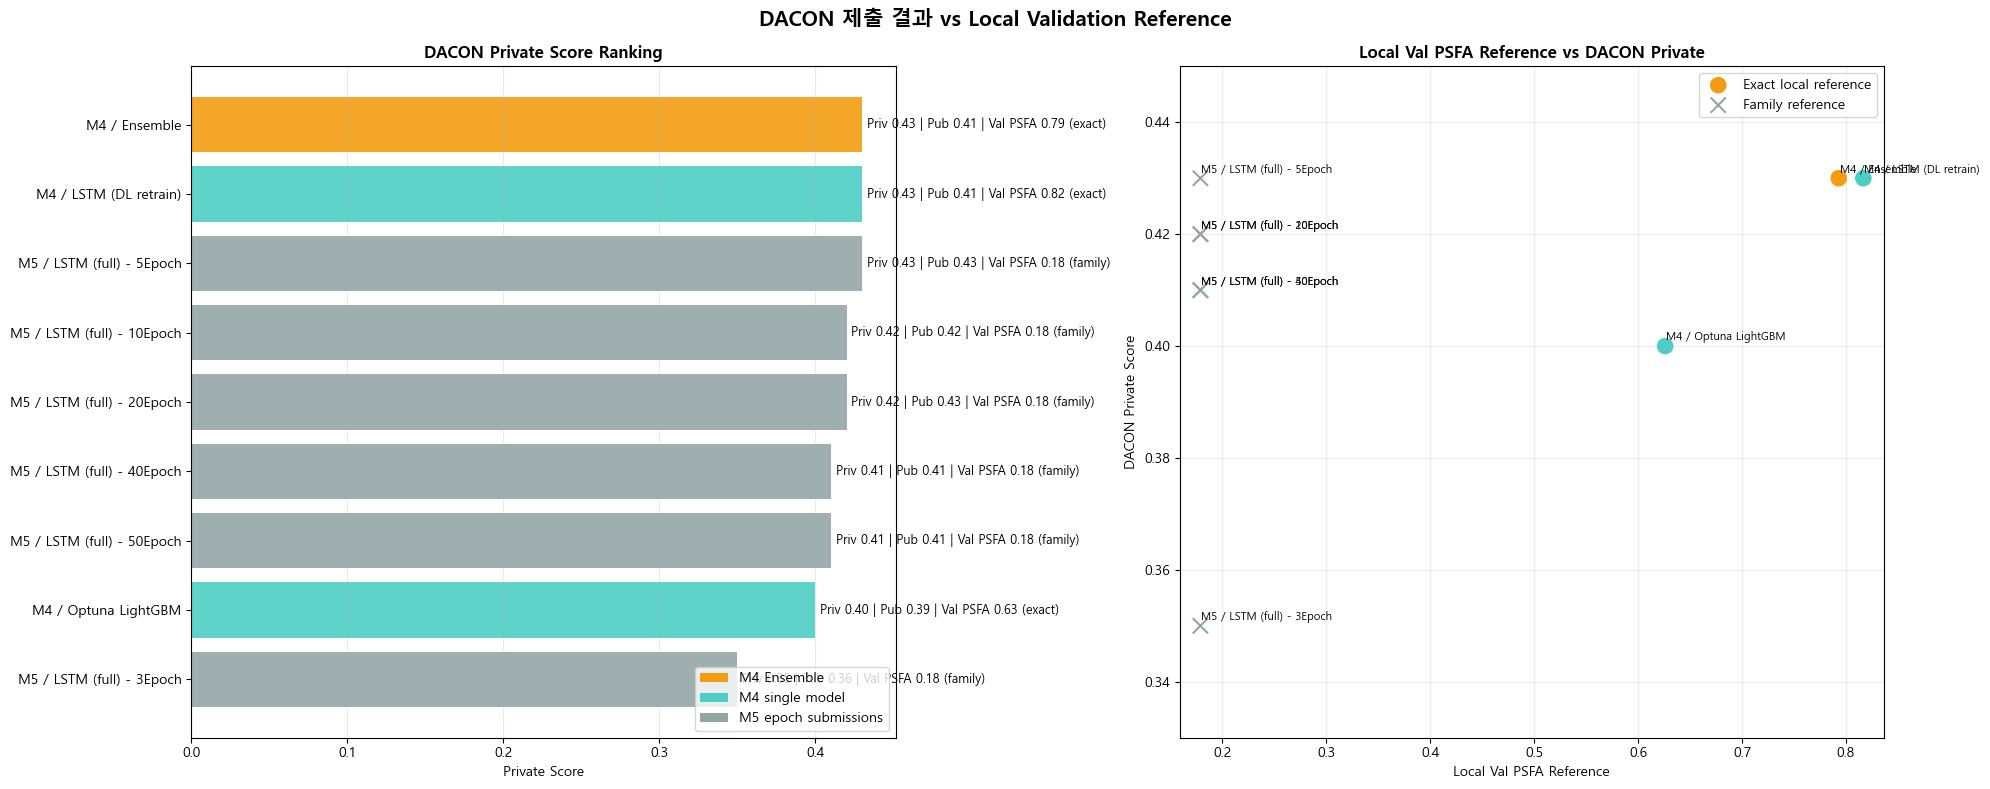

✅ DACON_VAL_COMPARE_BETTER_DF 생성 완료
※ exact = 동일 로컬 검증값, family = 같은 모델군 대표 로컬값(M5 / LSTM Full)
※ epoch 제출들의 Val PSFA는 epoch별 exact 값이 아니라 reference용 family 값


In [58]:
# ── 8-1. DACON vs Local Val PSFA 비교 그래프 ───────────────────────────

# 실제 점수 채우기
DACON_SCORE_TABLE = pd.DataFrame([
    {'model': 'M4 / Ensemble',              'public': 0.41, 'private': 0.43},
    {'model': 'M4 / LSTM (DL retrain)',     'public': 0.41, 'private': 0.43},
    {'model': 'M5 / LSTM (full) - 5Epoch', 'public': 0.43, 'private': 0.43},
    {'model': 'M5 / LSTM (full) - 10Epoch','public': 0.42, 'private': 0.42},
    {'model': 'M5 / LSTM (full) - 20Epoch','public': 0.43, 'private': 0.42},
    {'model': 'M5 / LSTM (full) - 40Epoch','public': 0.41, 'private': 0.41},
    {'model': 'M5 / LSTM (full) - 50Epoch','public': 0.41, 'private': 0.41},
    {'model': 'M4 / Optuna LightGBM',      'public': 0.39, 'private': 0.40},
    {'model': 'M5 / LSTM (full) - 3Epoch', 'public': 0.36, 'private': 0.35},
])


# 0) 필수 객체 확인
if 'FINAL_VAL_COMPARE_TABLE' not in globals():
    load_step5_cache(verbose=False)
    
required_vars = ['FINAL_VAL_COMPARE_TABLE', 'M4_ENSEMBLE_VAL_RESULT', 'DACON_SCORE_TABLE', 'train_clean']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(f'먼저 실행이 필요한 객체 없음: {missing}')

# 1) helper
def calc_psfa_matrix_local(y_true, y_pred, major_cats):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    major_cats = np.asarray(major_cats)

    y_pred = np.clip(y_pred, 0, None)
    cat_scores = {}

    for cat in pd.Series(major_cats).dropna().unique():
        mask = (major_cats == cat)
        yt = y_true[mask]
        yp = y_pred[mask]

        day_scores = []
        for j in range(yt.shape[1]):
            y_day = yt[:, j]
            p_day = yp[:, j]

            denom = np.maximum(y_day, p_day)
            rel_err = np.divide(
                np.abs(y_day - p_day),
                denom,
                out=np.zeros_like(y_day, dtype=float),
                where=denom > 0
            )

            day_sum = y_day.sum()
            if day_sum > 0:
                weights = y_day / day_sum
                day_err = np.sum(rel_err * weights)
            else:
                day_err = rel_err.mean() if len(rel_err) > 0 else 0.0

            day_scores.append(1.0 - day_err)

        cat_scores[cat] = float(np.mean(day_scores)) if len(day_scores) > 0 else np.nan

    total_psfa = float(np.nanmean(list(cat_scores.values()))) if len(cat_scores) > 0 else np.nan
    return total_psfa, cat_scores

def calc_basic_metrics(y_true, y_pred, major_cats):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    psfa, _ = calc_psfa_matrix_local(y_true, y_pred, major_cats)
    return {'RMSE': rmse, 'MAE': mae, 'PSFA': psfa}

# 2) local lookup: step5 결과 기반
local_lookup = {}
for _, row in FINAL_VAL_COMPARE_TABLE.iterrows():
    local_lookup[row['model']] = {
        'RMSE': row['RMSE'],
        'MAE': row['MAE'],
        'PSFA': row['PSFA'],
        'ref_type': 'cached_local'
    }

# 3) M4 exact local metrics 복원
major_map = (
    train_clean[['ID', '대분류']]
    .drop_duplicates('ID')
    .set_index('ID')['대분류']
)
major_eval_m4 = major_map.reindex(M4_ENSEMBLE_VAL_RESULT['val_pids']).values

actual_m4 = np.asarray(M4_ENSEMBLE_VAL_RESULT['actual_val'], dtype=float)
pred_ens_m4 = np.asarray(M4_ENSEMBLE_VAL_RESULT['pred_ensemble_val'], dtype=float)
pred_dl_m4  = np.asarray(M4_ENSEMBLE_VAL_RESULT['pred_dl_val'], dtype=float)
pred_lgb_m4 = np.asarray(M4_ENSEMBLE_VAL_RESULT['pred_lgb_val'], dtype=float)

local_lookup['M4 / Ensemble'] = {
    **calc_basic_metrics(actual_m4, pred_ens_m4, major_eval_m4),
    'ref_type': 'exact'
}
local_lookup['M4 / LSTM (DL retrain)'] = {
    **calc_basic_metrics(actual_m4, pred_dl_m4, major_eval_m4),
    'ref_type': 'exact'
}
local_lookup['M4 / Optuna LightGBM'] = {
    **calc_basic_metrics(actual_m4, pred_lgb_m4, major_eval_m4),
    'ref_type': 'exact'
}

# 4) DACON 점수표 사용
plot_df = DACON_SCORE_TABLE.copy()

# 5) 제출명 -> local reference 매핑
submission_to_local_ref = {
    'M4 / Ensemble':                ('M4 / Ensemble', 'exact'),
    'M4 / LSTM (DL retrain)':       ('M4 / LSTM (DL retrain)', 'exact'),
    'M4 / Optuna LightGBM':         ('M4 / Optuna LightGBM', 'exact'),

    'M5 / LSTM (full) - 3Epoch':    ('M5 / LSTM Full', 'family_ref'),
    'M5 / LSTM (full) - 5Epoch':    ('M5 / LSTM Full', 'family_ref'),
    'M5 / LSTM (full) - 10Epoch':   ('M5 / LSTM Full', 'family_ref'),
    'M5 / LSTM (full) - 20Epoch':   ('M5 / LSTM Full', 'family_ref'),
    'M5 / LSTM (full) - 40Epoch':   ('M5 / LSTM Full', 'family_ref'),
    'M5 / LSTM (full) - 50Epoch':   ('M5 / LSTM Full', 'family_ref'),
}

plot_df['local_ref_model'] = plot_df['model'].map(lambda x: submission_to_local_ref.get(x, (None, None))[0])
plot_df['local_ref_type']  = plot_df['model'].map(lambda x: submission_to_local_ref.get(x, (None, None))[1])

plot_df['Val_RMSE_ref'] = plot_df['local_ref_model'].map(lambda x: local_lookup.get(x, {}).get('RMSE', np.nan))
plot_df['Val_MAE_ref']  = plot_df['local_ref_model'].map(lambda x: local_lookup.get(x, {}).get('MAE', np.nan))
plot_df['Val_PSFA_ref'] = plot_df['local_ref_model'].map(lambda x: local_lookup.get(x, {}).get('PSFA', np.nan))

# 6) 정렬: private 높은 순
plot_df = plot_df.sort_values('private', ascending=False).reset_index(drop=True)
plot_df['Private Rank'] = np.arange(1, len(plot_df) + 1)

# 7) 그룹 색상
def pick_color(name):
    if name == 'M4 / Ensemble':
        return '#f39c12'   # 주황
    elif 'M4 /' in name:
        return '#4ECDC4'   # 청록
    else:
        return '#95a5a6'   # 회색

plot_df['color'] = plot_df['model'].apply(pick_color)

DACON_VAL_COMPARE_BETTER_DF = plot_df.copy()

# 8) 그래프
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ── [왼쪽] Private 중심 가로 막대 ─────────────────────────
ax = axes[0]

y = np.arange(len(plot_df))
bars = ax.barh(
    y,
    plot_df['private'],
    color=plot_df['color'],
    alpha=0.9
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df['model'])
ax.invert_yaxis()
ax.set_title('DACON Private Score Ranking', fontweight='bold')
ax.set_xlabel('Private Score')
ax.grid(axis='x', alpha=0.25)

# 막대 끝 라벨: Private / Public / Val PSFA ref
for i, (bar, _, row) in enumerate(zip(bars, y, plot_df.itertuples(index=False))):
    private_txt = f'{row.private:.2f}'
    public_txt  = f'{row.public:.2f}'
    psfa_txt    = f'{row.Val_PSFA_ref:.2f}' if pd.notna(row.Val_PSFA_ref) else 'NaN'
    ref_txt     = 'exact' if row.local_ref_type == 'exact' else 'family'
    label = f'Priv {private_txt} | Pub {public_txt} | Val PSFA {psfa_txt} ({ref_txt})'

    ax.text(
        bar.get_width() + 0.003,
        bar.get_y() + bar.get_height()/2,
        label,
        va='center',
        fontsize=9
    )

# 범례 흉내
from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor='#f39c12', label='M4 Ensemble'),
    Patch(facecolor='#4ECDC4', label='M4 single model'),
    Patch(facecolor='#95a5a6', label='M5 epoch submissions'),
]
ax.legend(handles=legend_items, loc='lower right')

# ── [오른쪽] Local Val PSFA ref vs Private scatter ─────────────────
ax = axes[1]

exact_df  = plot_df[(plot_df['local_ref_type'] == 'exact') & plot_df['Val_PSFA_ref'].notna()].copy()
family_df = plot_df[(plot_df['local_ref_type'] == 'family_ref') & plot_df['Val_PSFA_ref'].notna()].copy()

if len(exact_df) > 0:
    ax.scatter(
        exact_df['Val_PSFA_ref'],
        exact_df['private'],
        s=120,
        c=exact_df['color'].tolist(),
        label='Exact local reference'
    )

if len(family_df) > 0:
    ax.scatter(
        family_df['Val_PSFA_ref'],
        family_df['private'],
        s=120,
        marker='x',
        c=family_df['color'].tolist(),
        label='Family reference'
    )

for _, row in plot_df[plot_df['Val_PSFA_ref'].notna()].iterrows():
    ax.text(
        row['Val_PSFA_ref'] + 0.001,
        row['private'] + 0.001,
        row['model'],
        fontsize=8
    )

ax.set_title('Local Val PSFA Reference vs DACON Private', fontweight='bold')
ax.set_xlabel('Local Val PSFA Reference')
ax.set_ylabel('DACON Private Score')
ax.grid(alpha=0.25)
ax.legend()

# 축 범위 조금 여유
if plot_df['Val_PSFA_ref'].notna().any():
    ax.set_xlim(
        max(0.0, plot_df['Val_PSFA_ref'].min() - 0.02),
        min(1.0, plot_df['Val_PSFA_ref'].max() + 0.02)
    )
ax.set_ylim(
    max(0.0, plot_df['private'].min() - 0.02),
    min(1.0, plot_df['private'].max() + 0.02)
)

plt.suptitle('DACON 제출 결과 vs Local Validation Reference', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('✅ DACON_VAL_COMPARE_BETTER_DF 생성 완료')
print('※ exact = 동일 로컬 검증값, family = 같은 모델군 대표 로컬값(M5 / LSTM Full)')
print('※ epoch 제출들의 Val PSFA는 epoch별 exact 값이 아니라 reference용 family 값')

In [59]:
# ── 8-2. DACON vs Local Val PSFA 비교표 ─────────────────────────────────

if 'DACON_VAL_COMPARE_BETTER_DF' not in globals():
    raise ValueError('DACON_VAL_COMPARE_BETTER_DF가 없음. 먼저 8-1 그래프 셀을 실행해야 함.')

DACON_VAL_COMPARE_TABLE = DACON_VAL_COMPARE_BETTER_DF.copy()

display_df = DACON_VAL_COMPARE_TABLE[
    [
        'Private Rank',
        'model',
        'local_ref_model',
        'local_ref_type',
        'Val_RMSE_ref',
        'Val_MAE_ref',
        'Val_PSFA_ref',
        'public',
        'private',
    ]
].copy()

# 출력용 반올림
for c in ['Val_RMSE_ref', 'Val_MAE_ref', 'Val_PSFA_ref', 'public', 'private']:
    display_df[c] = display_df[c].round(2)

print('=' * 132)
print('🏁 DACON 제출 결과 vs Local Validation Reference 비교표')
print('=' * 132)
print(f'{"Rank":>4} | {"Model":<28} | {"Local Ref":<24} | {"Type":<10} | {"Val PSFA":>8} | {"Public":>8} | {"Private":>8}')
print('-' * 132)

for _, row in display_df.iterrows():
    rank = int(row['Private Rank'])
    model = row['model']
    local_ref = row['local_ref_model'] if pd.notna(row['local_ref_model']) else '-'
    ref_type = row['local_ref_type'] if pd.notna(row['local_ref_type']) else '-'
    val_psfa = row['Val_PSFA_ref']
    public = row['public']
    private = row['private']

    print(
        f'{rank:>4} | '
        f'{model:<28} | '
        f'{local_ref:<24} | '
        f'{ref_type:<10} | '
        f'{val_psfa:>8.2f} | '
        f'{public:>8.2f} | '
        f'{private:>8.2f}'
    )

print('\n✅ DACON_VAL_COMPARE_TABLE 생성 완료')
display(display_df)

🏁 DACON 제출 결과 vs Local Validation Reference 비교표
Rank | Model                        | Local Ref                | Type       | Val PSFA |   Public |  Private
------------------------------------------------------------------------------------------------------------------------------------
   1 | M4 / Ensemble                | M4 / Ensemble            | exact      |     0.79 |     0.41 |     0.43
   2 | M4 / LSTM (DL retrain)       | M4 / LSTM (DL retrain)   | exact      |     0.82 |     0.41 |     0.43
   3 | M5 / LSTM (full) - 5Epoch    | M5 / LSTM Full           | family_ref |     0.18 |     0.43 |     0.43
   4 | M5 / LSTM (full) - 10Epoch   | M5 / LSTM Full           | family_ref |     0.18 |     0.42 |     0.42
   5 | M5 / LSTM (full) - 20Epoch   | M5 / LSTM Full           | family_ref |     0.18 |     0.43 |     0.42
   6 | M5 / LSTM (full) - 40Epoch   | M5 / LSTM Full           | family_ref |     0.18 |     0.41 |     0.41
   7 | M5 / LSTM (full) - 50Epoch   | M5 / LSTM Full    

,Private Rank,model,local_ref_model,local_ref_type,Val_RMSE_ref,Val_MAE_ref,Val_PSFA_ref,public,private
0,1,M4 / Ensemble,M4 / Ensemble,exact,80.42,7.06,0.79,0.41,0.43
1,2,M4 / LSTM (DL retrain),M4 / LSTM (DL retrain),exact,62.84,5.58,0.82,0.41,0.43
2,3,M5 / LSTM (full) - 5Epoch,M5 / LSTM Full,family_ref,54.79,4.75,0.18,0.43,0.43
3,4,M5 / LSTM (full) - 10Epoch,M5 / LSTM Full,family_ref,54.79,4.75,0.18,0.42,0.42
4,5,M5 / LSTM (full) - 20Epoch,M5 / LSTM Full,family_ref,54.79,4.75,0.18,0.43,0.42
5,6,M5 / LSTM (full) - 40Epoch,M5 / LSTM Full,family_ref,54.79,4.75,0.18,0.41,0.41
6,7,M5 / LSTM (full) - 50Epoch,M5 / LSTM Full,family_ref,54.79,4.75,0.18,0.41,0.41
7,8,M4 / Optuna LightGBM,M4 / Optuna LightGBM,exact,143.15,13.65,0.63,0.39,0.40
8,9,M5 / LSTM (full) - 3Epoch,M5 / LSTM Full,family_ref,54.79,4.75,0.18,0.36,0.35


---
## 🏆 최종 결론 — 프로젝트 인사이트

### 📊 전체 실험 요약

```
문제 정의
  ↓
EDA: 급락 구간 발견 (2023-02-20 이후 정상 대비 ~16% 수준)
  ↓
1차 가설 (Method 5): "급변 구간을 플래그로 직접 학습시키자"
  → Val RMSE: 54.8 (좋아 보임)
  → DACON Private PSFA: 5ep=0.4282 / 20ep=0.4191 / 50ep=0.4063 (에폭 늘수록 폭락!)
  ↓
⚠️ 발견: 에폭이 늘수록 PSFA가 오히려 폭락!
  → PSFA는 전체 트렌드 일반화를 중요시함
  → Method 5 플래그가 딥러닝을 노이즈 과적합으로 유도한 것
  ↓
🔄 피벗 (Method 4): 급락 구간을 이동평균 30일로 복원 → 깨끗한 트렌드 학습
  → DL 단독 Private PSFA: 0.4313
  ↓
🧩 앙상블: Method 4 LSTM + Optuna LightGBM
  → LightGBM이 DL의 빈틈(구조적 패턴)을 보완
  → 최종 Private PSFA: 0.4336 🏆 1위
```

### 🥇 최종 순위표 (DACON Private 기준)

| 순위 | 모델 구성 | Public | **Private** |
|------|----------|--------|-------------|
| 🥇 1위 | **Method 4 + DL + LightGBM 앙상블** | 0.4114 | **0.4336** |
| 🥈 2위 | Method 4 + LSTM DL 재학습 | 0.4094 | 0.4313 |
| 🥉 3위 | Method 5 + LSTM (5 Epoch) | 0.4335 | 0.4282 |
| 4위 | Method 5 + LSTM (10 Epoch) | 0.4249 | 0.4225 |
| 5위 | Method 5 + LSTM (20 Epoch) | 0.4250 | 0.4191 |
| 6위 | Method 5 + LSTM (40 Epoch) | 0.4138 | 0.4082 |
| 7위 | Method 5 + LSTM (50 Epoch) | 0.4099 | 0.4063 |
| 8위 | Method 4 + Optuna LightGBM | 0.3940 | 0.4019 |
| 9위 | Method 5 + LSTM (3 Epoch) | 0.3650 | 0.3548 |

> 📌 **주목할 포인트:** Method 5 실험들에서 에폭이 늘수록 Private 점수가 단조 감소하는 패턴이 명확함

### 💡 핵심 인사이트

| 인사이트 | 내용 |
|---------|------|
| **지표 이해** | Val RMSE와 PSFA는 다른 것을 평가함. 제출 지표를 먼저 완전히 이해해야 함 |
| **비즈니스 vs 지표** | 비즈니스 논리(급변 포착)와 평가지표(전체 트렌드)가 충돌할 수 있음 |
| **앙상블의 가치** | DL 단독 0.4313 → 앙상블 0.4336: 서로 다른 관점의 모델이 약점을 보완 |
| **실패의 가치** | Method 5 실패가 없었다면 PSFA의 본질을 깨닫지 못했을 것 |


In [69]:
train.head()

,ID,제품,대분류,중분류,소분류,브랜드,2022-01-01,2022-01-02,2022-01-03,2022-01-04,...,2023-03-28,2023-03-29,2023-03-30,2023-03-31,2023-04-01,2023-04-02,2023-04-03,2023-04-04,first_sale_date,last_sale_date
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,0,0,0,0,...,0,0,0,0,0,0,0,0,2022-02-09,2023-02-10
1,1,B002-00002-00001,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,1,3,2,0,0,2,0,2022-01-28,2023-04-03
2,2,B002-00002-00002,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,0,0,0,0,0,2022-02-23,2023-01-12
3,3,B002-00002-00003,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,0,0,0,0,0,2022-01-29,2022-12-03
4,4,B002-00003-00001,B002-C001-0001,B002-C002-0001,B002-C003-0003,B002-00003,0,0,0,0,...,0,0,0,0,0,0,0,0,2022-01-25,2023-02-21
